# 🌡️ LST 2024 Prediction — Random Forest & SVR
**Target:** LST 2024  
**Metode:** Random Forest Regression · Support Vector Regression  

| # | Model | Fitur |
|---|-------|-------|

| M1 | Lag LST saja | lst_2009..2021 |
| M2 | **Cluster** + Lag LST | kmeans_cluster + lst_2009..2021 |
| M3 | Lag LST + Lag NDVI + Lag NDBI | lst + ndvi + ndbi 2009..2021 |
| M4 | **Cluster** + Lag LST + Lag NDVI + Lag NDBI | kmeans_cluster + lst + ndvi + ndbi 2009..2021 |

---

## 📦 Sel 1 — Install Library

In [90]:
%pip install geopandas scikit-learn shap seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


## 📂 Sel 2 — Path Data Lokal

In [91]:
# ── SESUAIKAN PATH INI JIKA STRUKTUR FOLDER BERBEDA ────────────────────────
# Semua path relatif terhadap folder notebook ini
# (C:\Users\Solideo G. Bangun\uhi-dashboard\data)
BASE_DIR = ''

# File 1: GeoJSON NDVI & NDBI per grid per tahun (long format, kolom: grid_id, year, NDVI, NDBI, sensor)
PATH_NDVI_NDBI = BASE_DIR + 'FINAL_NDVI_NDBI_Grid1km_Jakarta_ALL_YEARS.geojson'

# File 2: GeoJSON hasil clustering (output dari notebook clustering sebelumnya)
PATH_CLUSTER   = BASE_DIR + 'cluster_spatial_k4.geojson'

# File 3: GeoJSON LST per grid per periode (long format, kolom: grid_id, period, mean)
PATH_LST       = BASE_DIR + 'LSTPuncakKemarau.geojson'

# Direktori output
OUTPUT_DIR = BASE_DIR + 'output/regression/'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output akan disimpan ke: {OUTPUT_DIR}')

Output akan disimpan ke: output/regression/


## ⚙️ Sel 3 — Import & Konfigurasi

In [92]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import math
import re
from IPython.display import display

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  KONFIGURASI — SESUAIKAN JIKA PERLU
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LAG_YEARS    = [2009, 2012, 2015, 2018, 2021]   # tahun lag (fitur)
TARGET_YEAR  = 2024                              # tahun prediksi

NDVI_PREFIX  = 'ndvi'    # prefix kolom NDVI di GeoJSON
NDBI_PREFIX  = 'ndbi'     # prefix kolom NDBI di GeoJSON (cek screenshot: ndb2009)
LST_PREFIX   = 'lst'     # prefix kolom LST di CSV

CLUSTER_RAW  = 'k-means_cluster'   # nama kolom cluster di GeoJSON (ada tanda -)
CLUSTER_COL  = 'kmeans_cluster'    # nama setelah rename (aman untuk pandas)

TEST_SIZE    = 0.2
CV_FOLDS     = 5
SEED         = 42

# Hyperparameter RF
RF_PARAMS = dict(n_estimators=300, max_features='sqrt',
                 random_state=SEED, n_jobs=-1)

# Hyperparameter SVR
SVR_PARAMS = dict(kernel='rbf', C=10, gamma='scale', epsilon=0.1)

print('✅ Konfigurasi selesai')
print(f'   Lag years  : {LAG_YEARS}')
print(f'   Target     : LST {TARGET_YEAR}')
print(f'   Test size  : {TEST_SIZE*100:.0f}%   CV folds : {CV_FOLDS}')

✅ Konfigurasi selesai
   Lag years  : [2009, 2012, 2015, 2018, 2021]
   Target     : LST 2024
   Test size  : 20%   CV folds : 5


## 📥 Sel 4 — Load & Merge Data

In [93]:
# ── (A) Load NDVI / NDBI GeoJSON (long format: grid_id, year, NDVI, NDBI, sensor) ──
print('Membaca NDVI/NDBI GeoJSON ...')
gdf_ndvi_long = gpd.read_file(PATH_NDVI_NDBI)
print(f'  Fitur : {len(gdf_ndvi_long):,}   Kolom : {list(gdf_ndvi_long.columns)}')

# ── (B) Load Cluster GeoJSON ──────────────────────────────────────────────
print('Membaca cluster GeoJSON ...')
gdf_clust = gpd.read_file(PATH_CLUSTER)
print(f'  Fitur : {len(gdf_clust):,}   Kolom : {list(gdf_clust.columns)}')

# ── (C) Load LST GeoJSON (long format: grid_id, period, mean) ─────────────
print('Membaca LST GeoJSON ...')
gdf_lst_long = gpd.read_file(PATH_LST)
print(f'  Fitur : {len(gdf_lst_long):,}   Kolom : {list(gdf_lst_long.columns)}')

Membaca NDVI/NDBI GeoJSON ...
  Fitur : 3,864   Kolom : ['id', 'NDBI', 'NDVI', 'count', 'grid_id', 'sensor', 'year', 'geometry']
Membaca cluster GeoJSON ...
  Fitur : 639   Kolom : ['grid_id', 'k-means_cluster', 'dtw_k-means_cluster', 'k-shape_cluster', 'geometry']
Membaca LST GeoJSON ...
  Fitur : 3,864   Kolom : ['id', 'end_month', 'first', 'grid_id', 'mean', 'period', 'start_month', 'geometry']


In [94]:
# ── Standarisasi kolom grid_id ────────────────────────────────────────────
for obj in [gdf_ndvi_long, gdf_clust, gdf_lst_long]:
    obj['grid_id'] = obj['grid_id'].astype(str).str.strip()

# ── Lookup geometry per grid (gdf_ndvi_long long-format, 1 grid = beberapa baris/tahun) ──
gdf_geom = gdf_ndvi_long.drop_duplicates('grid_id')[['grid_id', 'geometry']].reset_index(drop=True)

# ── Definisi kolom per sumber ─────────────────────────────────────────────
# LST  : lag tahun sebelum target (prefix pakai underscore → lst_2009)
lst_cols = [f'{LST_PREFIX}_{y}' for y in LAG_YEARS]

# NDVI/NDBI : lag + tahun target semuanya tersedia di GeoJSON (tanpa underscore → ndvi2009)
ndvi_ndbi_years = LAG_YEARS + [TARGET_YEAR]                      # [2009,…,2021,2024]
ndvi_cols       = [f'{NDVI_PREFIX}{y}' for y in ndvi_ndbi_years] # ndvi2009 … ndvi2024
ndbi_cols       = [f'{NDBI_PREFIX}{y}' for y in ndvi_ndbi_years] # ndbi2009 … ndbi2024

# ── Pivot NDVI/NDBI dari long format (1 baris = 1 grid x 1 tahun) ke wide ──
gdf_ndvi_long['year'] = pd.to_numeric(gdf_ndvi_long['year'], errors='coerce').astype('Int64')

df_ndvi_wide = gdf_ndvi_long.pivot_table(index='grid_id', columns='year', values='NDVI').add_prefix(NDVI_PREFIX)
df_ndbi_wide = gdf_ndvi_long.pivot_table(index='grid_id', columns='year', values='NDBI').add_prefix(NDBI_PREFIX)
df_ndvi_sel  = df_ndvi_wide.join(df_ndbi_wide).reset_index()[['grid_id'] + ndvi_cols + ndbi_cols]

# ── Peta tahun → sensor citra asli (dipakai untuk harmonisasi di Sel 4b) ──
SENSOR_BY_YEAR = (
    gdf_ndvi_long.drop_duplicates('year').set_index('year')['sensor'].to_dict()
)

# ── Cluster ─────────────────────────────────────────────────────────────
df_clust_sel = gdf_clust[['grid_id', CLUSTER_RAW]].copy()
df_clust_sel.rename(columns={CLUSTER_RAW: CLUSTER_COL}, inplace=True)

# ── Pivot LST dari long format (grid_id, period, mean) ke wide ────────────
df_lst_wide = gdf_lst_long.pivot_table(index='grid_id', columns='period', values='mean')
df_lst_wide.columns = [f'{LST_PREFIX}_{int(y)}' for y in df_lst_wide.columns]
df_lst_sel  = df_lst_wide.reset_index()[['grid_id'] + lst_cols + [f'lst_{TARGET_YEAR}']]

# ── Merge tiga sumber ─────────────────────────────────────────────────────
df = (
    df_ndvi_sel
    .merge(df_clust_sel, on='grid_id', how='inner')
    .merge(df_lst_sel,   on='grid_id', how='inner')
)

# ── Konversi numerik ──────────────────────────────────────────────────────
num_cols = ndvi_cols + ndbi_cols + lst_cols + [f'lst_{TARGET_YEAR}', CLUSTER_COL]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna().reset_index(drop=True)

print(f'\n✅ Merge selesai: {len(df):,} grid dengan data lengkap')
print(f'   LST lag years    : {LAG_YEARS}')
print(f'   NDVI/NDBI years  : {ndvi_ndbi_years}')
print(f'   Sensor per tahun : {SENSOR_BY_YEAR}')
print(f'\n   Cluster distribution:')
print(df[CLUSTER_COL].value_counts().sort_index().to_string())
display(df.head())


✅ Merge selesai: 637 grid dengan data lengkap
   LST lag years    : [2009, 2012, 2015, 2018, 2021]
   NDVI/NDBI years  : [2009, 2012, 2015, 2018, 2021, 2024]
   Sensor per tahun : {2009: 'landsat7', 2012: 'landsat7', 2015: 'landsat8', 2018: 'landsat8', 2021: 'sentinel2', 2024: 'sentinel2'}

   Cluster distribution:
kmeans_cluster
1    123
2    147
3    206
4    161


,grid_id,ndvi2009,ndvi2012,ndvi2015,ndvi2018,ndvi2021,ndvi2024,ndbi2009,ndbi2012,ndbi2015,ndbi2018,ndbi2021,ndbi2024,kmeans_cluster,lst_2009,lst_2012,lst_2015,lst_2018,lst_2021,lst_2024
0,92955000708,0.427466,0.413545,0.439253,0.425077,0.339310,0.334413,-0.086939,-0.063838,-0.057869,-0.047273,0.034920,0.034557,4,36.668588,36.146513,38.228577,37.834997,36.914275,34.535053
1,92955000709,0.489836,0.452535,0.525907,0.523213,0.517290,0.510623,-0.131754,-0.101448,-0.098758,-0.120081,-0.092870,-0.101195,3,35.868047,35.298629,37.254754,37.319911,35.722285,33.313516
2,92965000698,0.475295,0.486932,0.490862,0.493731,0.436680,0.414030,-0.107083,-0.086688,-0.078047,-0.086787,-0.021600,-0.023261,4,36.079414,34.914972,37.529866,36.908929,35.779453,33.461384
3,92965000699,0.449262,0.431127,0.449282,0.445935,0.372573,0.342709,-0.089178,-0.093743,-0.058004,-0.050885,0.016047,0.023520,4,36.030412,34.949330,37.627289,36.884331,35.703353,33.510459
4,92965000707,0.355051,0.348590,0.363717,0.357271,0.249967,0.233341,-0.034757,-0.010418,-0.006759,0.006289,0.106124,0.121180,4,37.692706,37.068831,38.647737,38.749485,38.086196,35.517092


## 🛰️ Sel 4b — Harmonisasi Lintas-Sensor NDVI & NDBI (Cross-Sensor Continuity Correction)

Metadata `sensor` pada `FINAL_NDVI_NDBI_Grid1km_Jakarta_ALL_YEARS.geojson` menunjukkan bahwa NDVI/NDBI
tahun 2009–2024 direkam oleh **tiga sistem sensor berbeda**, bukan satu sensor yang konsisten:

| Tahun | Sensor (dari data) |
|---|---|
| 2009, 2012 | Landsat 7 ETM+ |
| 2015, 2018 | Landsat 8 OLI |
| 2021, 2024 | Sentinel-2 MSI |

Perbedaan respons spektral antar sensor menimbulkan bias sistematis pada NDVI/NDBI walau merekam objek
yang sama, sehingga nilainya perlu diharmonisasi sebelum dipakai sebagai fitur lag pada model regresi.
Sel ini menerapkan **dua tahap koreksi** berbasis literatur:

**Tahap 1 — Landsat 7 ETM+ → Landsat 8 OLI:**
menggunakan koefisien regresi OLS resmi dari Roy, D.P., Kovalskyy, V., Zhang, H.K., Vermote, E.F.,
Yan, L., Kumar, S.S., & Egorov, A. (2016). *Characterization of Landsat-7 to Landsat-8 reflective
wavelength and normalized difference vegetation index continuity.* Remote Sensing of Environment,
185, 57–70. https://doi.org/10.1016/j.rse.2015.12.024 — koefisien NDVI mengikuti nilai resmi jurnal;
koefisien NDBI diadaptasi dengan bentuk transformasi yang sama karena jurnal tsb. tidak
mempublikasikan koefisien NDBI secara eksplisit (didokumentasikan sebagai adaptasi, bukan nilai resmi).

**Tahap 2 — Landsat 8 OLI ↔ Sentinel-2 MSI:**
karena tidak tersedia koefisien regresi band-level resmi yang berlaku umum untuk pasangan sensor ini
pada indeks turunan (NDVI/NDBI), dilakukan interkalibrasi statistik (penyesuaian mean & standar deviasi,
"z-score rescaling") terhadap distribusi sensor referensi, mengikuti metodologi interkalibrasi indeks
vegetasi lintas-sensor dari Steven, M.D., Malthus, T.J., Baret, F., Xu, H., & Chen, M.J. (2003).
*Intercalibration of vegetation indices from different sensor systems.* Remote Sensing of Environment,
88(4), 412–422. https://doi.org/10.1016/j.rse.2003.08.010

Sensor referensi yang dipakai adalah **Landsat 8 OLI** (tahun 2015 & 2018, ditambah 2009 & 2012 yang
telah dikoreksi ke skala OLI pada Tahap 1), karena berada di tengah rentang waktu data dan terhubung
langsung ke ETM+ lewat koefisien resmi Roy et al. (2016).

LST **tidak** dikoreksi pada tahap ini karena merupakan variabel target/lag yang ditangani terpisah
oleh model, sesuai cakupan koreksi yang diminta.

In [95]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  HARMONISASI LINTAS-SENSOR NDVI/NDBI
#  Tahap 1 (Landsat7 ETM+ -> Landsat8 OLI): Roy et al. (2016) RSE 185:57-70,
#           doi:10.1016/j.rse.2015.12.024
#  Tahap 2 (Landsat8 OLI <-> Sentinel-2 MSI): interkalibrasi statistik mengikuti
#           Steven et al. (2003) RSE 88(4):412-422, doi:10.1016/j.rse.2003.08.010
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Tahap 1 -- koefisien OLS resmi Roy et al. (2016): index_OLI = a + b * index_ETM+
# NDBI diadaptasi dengan bentuk transformasi yang sama (lihat catatan Sel 4b).
ROY2016_COEF = {
    'ndvi': dict(a=0.0029, b=0.9765),
    'ndbi': dict(a=0.0029, b=0.9765),
}

def apply_etm_to_oli(series, index_name):
    """Tahap 1: koreksi Landsat 7 ETM+ -> Landsat 8 OLI (Roy et al., 2016)."""
    coef = ROY2016_COEF[index_name]
    return coef['a'] + coef['b'] * series

def zscore_rescale(series, ref_mean, ref_std):
    """Tahap 2: interkalibrasi statistik ke distribusi sensor referensi (Steven et al., 2003)."""
    src_mean, src_std = series.mean(), series.std()
    if not src_std or pd.isna(src_std):
        return series
    return ref_mean + (series - src_mean) * (ref_std / src_std)

n_corrected = 0
for index_name, prefix in [('ndvi', NDVI_PREFIX), ('ndbi', NDBI_PREFIX)]:
    cols_by_year = {y: f'{prefix}{y}' for y in ndvi_ndbi_years}

    # Tahap 1: tahun landsat7 -> setara skala OLI
    for y, col in cols_by_year.items():
        if SENSOR_BY_YEAR.get(y) == 'landsat7':
            df[col] = apply_etm_to_oli(df[col], index_name)
            n_corrected += 1
            print(f'  ✅ {col} ({y}, landsat7) -> dikoreksi ke skala OLI [Roy et al., 2016]')

    # Tahap 2: tahun sentinel2 -> diinterkalibrasi ke distribusi referensi OLI
    oli_years  = [y for y in ndvi_ndbi_years if SENSOR_BY_YEAR.get(y) in ('landsat7', 'landsat8')]
    ref_values = pd.concat([df[cols_by_year[y]] for y in oli_years])
    ref_mean, ref_std = ref_values.mean(), ref_values.std()

    for y, col in cols_by_year.items():
        if SENSOR_BY_YEAR.get(y) == 'sentinel2':
            df[col] = zscore_rescale(df[col], ref_mean, ref_std)
            n_corrected += 1
            print(f'  ✅ {col} ({y}, sentinel2) -> diinterkalibrasi statistik ke skala OLI [Steven et al., 2003]')

print(f'\n✅ Harmonisasi lintas-sensor selesai: {n_corrected} kolom dikoreksi')
print('   LST tidak dikoreksi (bukan indeks spektral turunan, ditangani terpisah oleh model).')

  ✅ ndvi2009 (2009, landsat7) -> dikoreksi ke skala OLI [Roy et al., 2016]
  ✅ ndvi2012 (2012, landsat7) -> dikoreksi ke skala OLI [Roy et al., 2016]
  ✅ ndvi2021 (2021, sentinel2) -> diinterkalibrasi statistik ke skala OLI [Steven et al., 2003]
  ✅ ndvi2024 (2024, sentinel2) -> diinterkalibrasi statistik ke skala OLI [Steven et al., 2003]
  ✅ ndbi2009 (2009, landsat7) -> dikoreksi ke skala OLI [Roy et al., 2016]
  ✅ ndbi2012 (2012, landsat7) -> dikoreksi ke skala OLI [Roy et al., 2016]
  ✅ ndbi2021 (2021, sentinel2) -> diinterkalibrasi statistik ke skala OLI [Steven et al., 2003]
  ✅ ndbi2024 (2024, sentinel2) -> diinterkalibrasi statistik ke skala OLI [Steven et al., 2003]

✅ Harmonisasi lintas-sensor selesai: 8 kolom dikoreksi
   LST tidak dikoreksi (bukan indeks spektral turunan, ditangani terpisah oleh model).


## 🔍 Sel 5 — Eksplorasi Data (EDA)

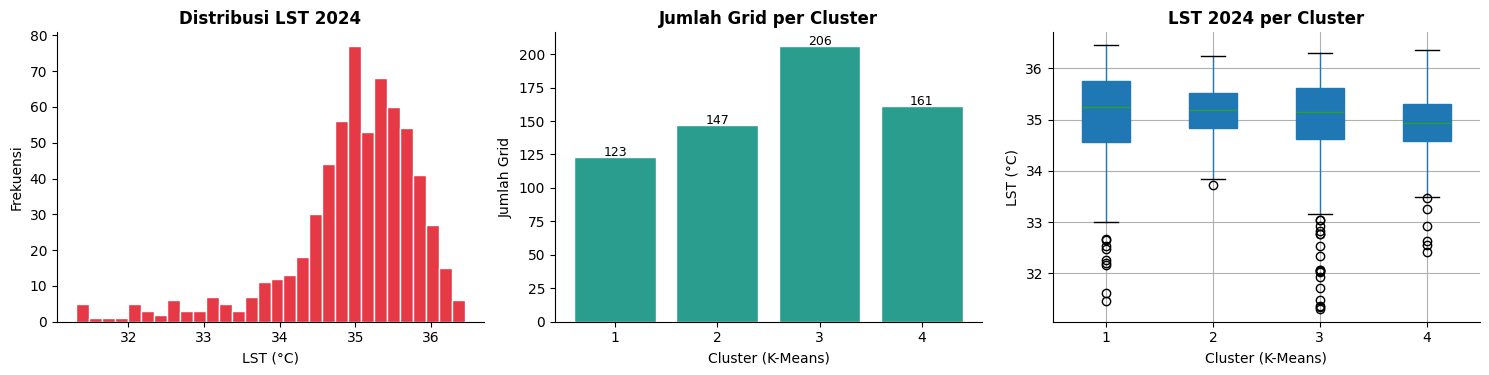


Statistik Deskriptif (target + lag LST):


,lst_2024,lst_2009,lst_2012,lst_2015,lst_2018,lst_2021
count,637.000,637.000,637.000,637.000,637.000,637.000
mean,34.963,37.309,36.950,38.070,38.365,37.162
std,0.883,1.420,1.205,1.196,1.154,1.084
min,31.311,32.359,32.108,32.781,33.390,32.657
25%,34.652,36.683,36.596,37.750,38.041,36.767
50%,35.089,37.481,37.234,38.316,38.605,37.311
75%,35.547,38.131,37.714,38.794,39.118,37.871
max,36.444,40.508,38.829,40.121,40.257,39.235


In [96]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi target
axes[0].hist(df[f'lst_{TARGET_YEAR}'], bins=30, color='#E63946', edgecolor='white')
axes[0].set_title(f'Distribusi LST {TARGET_YEAR}', fontweight='bold')
axes[0].set_xlabel('LST (°C)')
axes[0].set_ylabel('Frekuensi')

# Distribusi cluster
vc = df[CLUSTER_COL].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color='#2A9D8F', edgecolor='white')
axes[1].set_title('Jumlah Grid per Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster (K-Means)')
axes[1].set_ylabel('Jumlah Grid')
for i, v in enumerate(vc.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=9)

# Boxplot LST 2024 per cluster
df.boxplot(column=f'lst_{TARGET_YEAR}', by=CLUSTER_COL, ax=axes[2],
           patch_artist=True)
axes[2].set_title(f'LST {TARGET_YEAR} per Cluster', fontweight='bold')
axes[2].set_xlabel('Cluster (K-Means)')
axes[2].set_ylabel('LST (°C)')
plt.suptitle('')

sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStatistik Deskriptif (target + lag LST):')
display(df[[f'lst_{TARGET_YEAR}'] + lst_cols].describe().round(3))

## 🔧 Sel 6 — Definisi Fitur & Fungsi Helper

In [97]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  DEFINISI FITUR UNTUK 4 KONFIGURASI MODEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TARGET_COL = f'lst_{TARGET_YEAR}'

MODEL_CONFIGS = {
    'M1_LagLST': {
        'label'           : 'M1: Lag LST saja',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]}',
        'features'        : lst_cols,
        'split_by_cluster': False,
    },
    'M2_LagLST_byCluster': {
        'label'           : 'M2: Lag LST (per Cluster)',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]}, model dilatih per cluster',
        'features'        : lst_cols,
        'split_by_cluster': True,
    },
    'M3_LagAll': {
        'label'           : 'M3: Lag LST + NDVI + NDBI',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]} + ndvi/ndbi {ndvi_ndbi_years[0]}–{ndvi_ndbi_years[-1]}',
        'features'        : lst_cols + ndvi_cols + ndbi_cols,
        'split_by_cluster': False,
    },
    'M4_LagAll_byCluster': {
        'label'           : 'M4: Lag LST + NDVI + NDBI (per Cluster)',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]} + ndvi/ndbi {ndvi_ndbi_years[0]}–{ndvi_ndbi_years[-1]}, per cluster',
        'features'        : lst_cols + ndvi_cols + ndbi_cols,
        'split_by_cluster': True,
    },
}

print('✅ Konfigurasi model:')
print(f'   lst_cols  ({len(lst_cols)}): {lst_cols}')
print(f'   ndvi_cols ({len(ndvi_cols)}): {ndvi_cols}')
print(f'   ndbi_cols ({len(ndbi_cols)}): {ndbi_cols}')
print()
for key, cfg in MODEL_CONFIGS.items():
    split_info = f'split per {CLUSTER_COL}' if cfg['split_by_cluster'] else 'semua data'
    print(f'   {cfg["label"]}')
    print(f'      Fitur ({len(cfg["features"])}): {cfg["desc"]}')
    print(f'      Data : {split_info}')

✅ Konfigurasi model:
   lst_cols  (5): ['lst_2009', 'lst_2012', 'lst_2015', 'lst_2018', 'lst_2021']
   ndvi_cols (6): ['ndvi2009', 'ndvi2012', 'ndvi2015', 'ndvi2018', 'ndvi2021', 'ndvi2024']
   ndbi_cols (6): ['ndbi2009', 'ndbi2012', 'ndbi2015', 'ndbi2018', 'ndbi2021', 'ndbi2024']

   M1: Lag LST saja
      Fitur (5): lst 2009–2021
      Data : semua data
   M2: Lag LST (per Cluster)
      Fitur (5): lst 2009–2021, model dilatih per cluster
      Data : split per kmeans_cluster
   M3: Lag LST + NDVI + NDBI
      Fitur (17): lst 2009–2021 + ndvi/ndbi 2009–2024
      Data : semua data
   M4: Lag LST + NDVI + NDBI (per Cluster)
      Fitur (17): lst 2009–2021 + ndvi/ndbi 2009–2024, per cluster
      Data : split per kmeans_cluster


In [98]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  FUNGSI HELPER
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def adj_r2(r2, n, p):
    """Adjusted R²."""
    if n - p - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (skip nol)."""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def get_metrics(y_true, y_pred, n_feat, prefix=''):
    n    = len(y_true)
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    ar2  = adj_r2(r2, n, n_feat)
    mp   = mape(y_true, y_pred)
    return {
        f'{prefix}R2'     : round(r2,   4),
        f'{prefix}Adj_R2' : round(ar2,  4),
        f'{prefix}RMSE'   : round(rmse, 4),
        f'{prefix}MAE'    : round(mae,  4),
        f'{prefix}MAPE'   : round(mp,   4),
    }

def build_rf():
    return RandomForestRegressor(**RF_PARAMS)

def build_svr():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svr',    SVR(**SVR_PARAMS))
    ])

def run_single_model(model, X_tr, X_te, y_tr, y_te, feats):
    """Latih satu model, kembalikan dict hasil + artefak."""
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    kf        = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2')

    n_feat = len(feats)
    result = {}
    result.update(get_metrics(y_tr, y_pred_tr, n_feat, 'Train_'))
    result.update(get_metrics(y_te, y_pred_te, n_feat, 'Test_'))
    result['CV_R2_Mean']  = round(cv_scores.mean(), 4)
    result['CV_R2_Std']   = round(cv_scores.std(),  4)
    result['y_pred_test'] = y_pred_te
    result['y_pred_train']= y_pred_tr
    result['model_obj']   = model
    result['features']    = feats
    result['X_test']      = X_te
    result['y_test']      = y_te
    result['X_train']     = X_tr
    result['y_train']     = y_tr
    return result

# ── Konstanta & util bersama untuk analisis SHAP (Sel 12-14) ─────────────
# Dipusatkan di sini agar tidak didefinisikan ulang di tiap sel SHAP.
CLUSTER_PALETTE = ['#3949ab', '#00897b', '#e53935', '#8e24aa',
                    '#f57c00', '#0277bd', '#558b2f', '#6d4c41']

COLOR_VAR = {'LST': '#e53935', 'NDVI': '#43a047',
             'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}

def extract_year(feat_name: str):
    """Ekstrak tahun dari nama fitur, misal 'lst_2021' -> 2021."""
    m = re.search(r'(19|20)\d{2}', feat_name)
    return int(m.group()) if m else None

def get_var_type(feat_name: str) -> str:
    """Klasifikasi jenis variabel: LST, NDVI, NDBI, atau LAINNYA."""
    fn = feat_name.upper().replace('_', '').replace('-', '')
    for vtype in ['NDBI', 'NDVI', 'LST']:
        if fn.startswith(vtype):
            return vtype
    return 'LAINNYA'

print('✅ Fungsi helper siap.')

✅ Fungsi helper siap.


## 🚀 Sel 7 — Training Semua Model (RF + SVR × 4 Konfigurasi)

In [99]:
idx_all = np.arange(len(df))
idx_train_global, idx_test_global = train_test_split(
    idx_all, test_size=TEST_SIZE, random_state=SEED
)

all_results  = {}   # key: (config_key, algorithm)
summary_rows = []

clusters = sorted(df[CLUSTER_COL].unique())

for cfg_key, cfg in MODEL_CONFIGS.items():
    feats          = cfg['features']
    split_by_clust = cfg['split_by_cluster']

    # ── Siapkan data sesuai mode ──────────────────────────────────────────
    if not split_by_clust:
        # ── Mode normal: satu model untuk semua grid ──────────────────────
        X = df[feats].values
        y = df[TARGET_COL].values

        X_train = X[idx_train_global]
        X_test  = X[idx_test_global]
        y_train = y[idx_train_global]
        y_test  = y[idx_test_global]

        for algo_name, model in [('RF', build_rf()), ('SVR', build_svr())]:
            print(f'Training {cfg["label"]} — {algo_name} ...', end=' ')
            res = run_single_model(model, X_train, X_test, y_train, y_test, feats)
            all_results[(cfg_key, algo_name)] = res

            print(
                f'✓  Test R²={res["Test_R2"]:.4f}  '
                f'Adj R²={res["Test_Adj_R2"]:.4f}  '
                f'RMSE={res["Test_RMSE"]:.4f}  '
                f'MAPE={res["Test_MAPE"]:.2f}%'
            )
            summary_rows.append({
                'Config'       : cfg['label'],
                'Algorithm'    : algo_name,
                'N_Features'   : len(feats),
                'Split'        : 'Semua Grid',
                'Train_R2'     : res['Train_R2'],
                'Train_Adj_R2' : res['Train_Adj_R2'],
                'Test_R2'      : res['Test_R2'],
                'Test_Adj_R2'  : res['Test_Adj_R2'],
                'Test_RMSE'    : res['Test_RMSE'],
                'Test_MAE'     : res['Test_MAE'],
                'Test_MAPE'    : res['Test_MAPE'],
                'CV_R2_Mean'   : res['CV_R2_Mean'],
                'CV_R2_Std'    : res['CV_R2_Std'],
            })

    else:
        # ── Mode split per cluster: satu model per cluster ─────────────────
        # Prediksi dikumpulkan kembali ke array berukuran len(df)
        # sehingga evaluasi gabungan tetap bisa dihitung.

        y_pred_test_combined  = np.full(len(df), np.nan)
        y_pred_train_combined = np.full(len(df), np.nan)
        cluster_models        = {}   # {cluster_id: {'RF': model, 'SVR': model}}
        cluster_X_test        = {}   # {cluster_id: X_test}
        cluster_y_test        = {}
        cluster_X_train       = {}
        cluster_y_train       = {}

        for algo_name, _ in [('RF', None), ('SVR', None)]:
            print(f'\n--- {cfg["label"]} — {algo_name} (per cluster) ---')
            y_pred_test_combined  = np.full(len(df), np.nan)
            y_pred_train_combined = np.full(len(df), np.nan)

            per_cluster_rows = []

            for cl in clusters:
                idx_cl = df.index[df[CLUSTER_COL] == cl].tolist()

                # Pakai split GLOBAL yang sama untuk setiap konfigurasi,
                # supaya keempat model (M1–M4) dievaluasi pada grid uji yang
                # identik dan prediksinya bisa disandingkan langsung. Yang
                # berbeda hanya: di sini satu model dilatih terpisah per cluster.
                set_train_global = set(np.asarray(idx_train_global).tolist())
                set_test_global  = set(np.asarray(idx_test_global).tolist())
                idx_cl_train = [i for i in idx_cl if i in set_train_global]
                idx_cl_test  = [i for i in idx_cl if i in set_test_global]
                if len(idx_cl_train) == 0 or len(idx_cl_test) == 0:
                    continue

                X_cl = df.loc[idx_cl, feats].values
                y_cl = df.loc[idx_cl, TARGET_COL].values

                X_cl_train = df.loc[idx_cl_train, feats].values
                X_cl_test  = df.loc[idx_cl_test,  feats].values
                y_cl_train = df.loc[idx_cl_train, TARGET_COL].values
                y_cl_test  = df.loc[idx_cl_test,  TARGET_COL].values

                model = build_rf() if algo_name == 'RF' else build_svr()
                model.fit(X_cl_train, y_cl_train)

                y_pred_cl_test  = model.predict(X_cl_test)
                y_pred_cl_train = model.predict(X_cl_train)

                # Isi array gabungan
                y_pred_test_combined[idx_cl_test]   = y_pred_cl_test
                y_pred_train_combined[idx_cl_train]  = y_pred_cl_train

                # Simpan model per cluster
                if cl not in cluster_models:
                    cluster_models[cl] = {}
                cluster_models[cl][algo_name]  = model
                cluster_X_test[cl]  = X_cl_test
                cluster_y_test[cl]  = y_cl_test
                cluster_X_train[cl] = X_cl_train
                cluster_y_train[cl] = y_cl_train

                # Metrik per cluster
                r2_cl   = r2_score(y_cl_test, y_pred_cl_test)
                rmse_cl = np.sqrt(mean_squared_error(y_cl_test, y_pred_cl_test))
                print(f'   Cluster {cl:2.0f}  n={len(idx_cl):4d} '
                      f'(train={len(idx_cl_train)}, test={len(idx_cl_test)})  '
                      f'R²={r2_cl:.4f}  RMSE={rmse_cl:.4f}')

            # ── Evaluasi gabungan (hanya indeks yang punya prediksi) ──────
            valid_mask       = ~np.isnan(y_pred_test_combined)
            y_all            = df[TARGET_COL].values
            y_true_combined  = y_all[valid_mask]
            y_pred_combined  = y_pred_test_combined[valid_mask]

            # indeks test gabungan (union semua cluster_test)
            idx_test_union   = np.where(valid_mask)[0]

            valid_train_mask    = ~np.isnan(y_pred_train_combined)
            y_true_train_comb   = y_all[valid_train_mask]
            y_pred_train_comb   = y_pred_train_combined[valid_train_mask]

            n_feat = len(feats)
            m_test  = get_metrics(y_true_combined,   y_pred_combined,   n_feat, 'Test_')
            m_train = get_metrics(y_true_train_comb, y_pred_train_comb, n_feat, 'Train_')

            # CV gabungan (gabungkan semua data cluster, latih ulang 1 model global
            # sebagai proxy CV — karena split per cluster tidak bisa fold-CV biasa)
            X_all_cl = df[feats].values
            y_all_cl = df[TARGET_COL].values
            model_cv = build_rf() if algo_name == 'RF' else build_svr()
            kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
            cv_scores = cross_val_score(model_cv, X_all_cl, y_all_cl,
                                        cv=kf, scoring='r2')

            print(f'   ➤ Gabungan  Test R²={m_test["Test_R2"]:.4f}  '
                  f'Adj R²={m_test["Test_Adj_R2"]:.4f}  '
                  f'RMSE={m_test["Test_RMSE"]:.4f}  '
                  f'MAPE={m_test["Test_MAPE"]:.2f}%')

            # Simpan ke all_results (pakai cluster 0 sebagai proxy model_obj untuk SHAP/FI)
            # Model per cluster tersedia di cluster_models
            representative_cl = clusters[0]
            all_results[(cfg_key, algo_name)] = {
                **m_train,
                **m_test,
                'CV_R2_Mean'       : round(cv_scores.mean(), 4),
                'CV_R2_Std'        : round(cv_scores.std(),  4),
                'y_pred_test'      : y_pred_combined,
                'y_pred_train'     : y_pred_train_comb,
                'y_test'           : y_true_combined,
                'y_train'          : y_true_train_comb,
                'X_test'           : df.loc[idx_test_union, feats].values,
                'X_train'          : df.loc[~valid_mask == False, feats].values,
                'model_obj'        : cluster_models[representative_cl][algo_name],
                'cluster_models'   : cluster_models,
                'cluster_X_test'   : cluster_X_test,
                'cluster_y_test'   : cluster_y_test,
                'cluster_X_train'  : cluster_X_train,
                'cluster_y_train'  : cluster_y_train,
                'features'         : feats,
                'split_by_cluster' : True,
                'idx_test_union'   : idx_test_union,
            }

            summary_rows.append({
                'Config'       : cfg['label'],
                'Algorithm'    : algo_name,
                'N_Features'   : len(feats),
                'Split'        : 'Per Cluster',
                'Train_R2'     : m_train['Train_R2'],
                'Train_Adj_R2' : m_train['Train_Adj_R2'],
                'Test_R2'      : m_test['Test_R2'],
                'Test_Adj_R2'  : m_test['Test_Adj_R2'],
                'Test_RMSE'    : m_test['Test_RMSE'],
                'Test_MAE'     : m_test['Test_MAE'],
                'Test_MAPE'    : m_test['Test_MAPE'],
                'CV_R2_Mean'   : round(cv_scores.mean(), 4),
                'CV_R2_Std'    : round(cv_scores.std(),  4),
            })

df_summary = pd.DataFrame(summary_rows)
print('\n✅ Semua model selesai dilatih.')

Training M1: Lag LST saja — RF ... ✓  Test R²=0.9125  Adj R²=0.9089  RMSE=0.2448  MAPE=0.56%
Training M1: Lag LST saja — SVR ... ✓  Test R²=0.9215  Adj R²=0.9183  RMSE=0.2319  MAPE=0.52%

--- M2: Lag LST (per Cluster) — RF (per cluster) ---
   Cluster  1  n= 123 (train=95, test=28)  R²=0.9011  RMSE=0.3287
   Cluster  2  n= 147 (train=123, test=24)  R²=0.6997  RMSE=0.2367
   Cluster  3  n= 206 (train=168, test=38)  R²=0.9623  RMSE=0.1948
   Cluster  4  n= 161 (train=123, test=38)  R²=0.8460  RMSE=0.2316
   ➤ Gabungan  Test R²=0.9105  Adj R²=0.9068  RMSE=0.2477  MAPE=0.55%

--- M2: Lag LST (per Cluster) — SVR (per cluster) ---
   Cluster  1  n= 123 (train=95, test=28)  R²=0.9443  RMSE=0.2466
   Cluster  2  n= 147 (train=123, test=24)  R²=0.6660  RMSE=0.2496
   Cluster  3  n= 206 (train=168, test=38)  R²=0.9681  RMSE=0.1794
   Cluster  4  n= 161 (train=123, test=38)  R²=0.8962  RMSE=0.1901
   ➤ Gabungan  Test R²=0.9339  Adj R²=0.9312  RMSE=0.2128  MAPE=0.47%
Training M3: Lag LST + NDVI + 

## 📋 Sel 8 — Tabel Hasil Evaluasi

In [100]:
print(f'\n{"="*75}')
print(f'  HASIL EVALUASI — Prediksi LST {TARGET_YEAR}')
print(f'{"="*75}')

styled = (
    df_summary.style
    .highlight_max(
        subset=['Train_R2','Train_Adj_R2','Test_R2','Test_Adj_R2','CV_R2_Mean'],
        color='#d4edda'
    )
    .highlight_min(
        subset=['Test_RMSE','Test_MAE','Test_MAPE','CV_R2_Std'],
        color='#d4edda'
    )
    .highlight_max(
        subset=['Test_RMSE','Test_MAE','Test_MAPE'],
        color='#f8d7da'
    )
    .format({
        'Train_R2'     : '{:.4f}',
        'Train_Adj_R2' : '{:.4f}',
        'Test_R2'      : '{:.4f}',
        'Test_Adj_R2'  : '{:.4f}',
        'Test_RMSE'    : '{:.4f}',
        'Test_MAE'     : '{:.4f}',
        'Test_MAPE'    : '{:.2f}%',
        'CV_R2_Mean'   : '{:.4f}',
        'CV_R2_Std'    : '{:.4f}',
    })
)
display(styled)

df_summary.to_csv(OUTPUT_DIR + 'summary_evaluation.csv', index=False)
print(f'\n💾 Disimpan: {OUTPUT_DIR}summary_evaluation.csv')

# Tabel per-cluster khusus model byCluster
print('\n📊 Detail metrik per cluster (model split_by_cluster):')
for cfg_key, cfg in MODEL_CONFIGS.items():
    if not cfg['split_by_cluster']:
        continue
    print(f'\n  ── {cfg["label"]} ──')
    for algo_name in ['RF', 'SVR']:
        res = all_results[(cfg_key, algo_name)]
        cl_models = res['cluster_models']
        print(f'  {algo_name}:')
        rows_cl = []
        for cl in clusters:
            X_te = res['cluster_X_test'][cl]
            y_te = res['cluster_y_test'][cl]
            X_tr = res['cluster_X_train'][cl]   # ← diperlukan untuk Adj R² & CV
            y_tr = res['cluster_y_train'][cl]   # ← diperlukan untuk Adj R² & CV
            m    = cl_models[cl][algo_name]
            yp   = m.predict(X_te)

            # Metrik dasar
            r2_   = r2_score(y_te, yp)
            rmse_ = np.sqrt(mean_squared_error(y_te, yp))
            mae_  = mean_absolute_error(y_te, yp)

            # MAPE (hindari div/0)
            mask      = y_te != 0
            mape_     = np.mean(np.abs((y_te[mask] - yp[mask]) / y_te[mask])) * 100 if mask.any() else np.nan

            # Adjusted R²  →  1 - (1-R²)*(n-1)/(n-p-1)
            n_te  = len(y_te)
            p_    = X_te.shape[1]
            adj_r2_ = 1 - (1 - r2_) * (n_te - 1) / (n_te - p_ - 1) if (n_te - p_ - 1) > 0 else np.nan

            # CV R² (cross-validate pada data TRAIN cluster tersebut)
            cv_scores_ = cross_val_score(m, X_tr, y_tr, cv=5, scoring='r2')
            cv_r2_mean_ = cv_scores_.mean()
            cv_r2_std_  = cv_scores_.std()

            rows_cl.append({
                'Cluster'    : int(cl),
                'n_test'     : n_te,
                'R²'         : round(r2_,    4),
                'Adj_R²'     : round(adj_r2_,4) if not np.isnan(adj_r2_) else np.nan,
                'RMSE'       : round(rmse_,  4),
                'MAE'        : round(mae_,   4),
                'MAPE (%)'   : round(mape_,  2) if not np.isnan(mape_) else np.nan,
                'CV_R²_Mean' : round(cv_r2_mean_, 4),
                'CV_R²_Std'  : round(cv_r2_std_,  4),
            })

        df_cl = pd.DataFrame(rows_cl)

        # Styling per-cluster
        styled_cl = (
            df_cl.style
            .highlight_max(subset=['R²', 'Adj_R²', 'CV_R²_Mean'], color='#d4edda')
            .highlight_min(subset=['RMSE', 'MAE', 'MAPE (%)', 'CV_R²_Std'], color='#d4edda')
            .highlight_max(subset=['RMSE', 'MAE', 'MAPE (%)'], color='#f8d7da')
            .format({
                'R²'        : '{:.4f}',
                'Adj_R²'    : '{:.4f}',
                'RMSE'      : '{:.4f}',
                'MAE'       : '{:.4f}',
                'MAPE (%)' : '{:.2f}%',
                'CV_R²_Mean': '{:.4f}',
                'CV_R²_Std' : '{:.4f}',
            })
        )
        display(styled_cl)

        # Simpan CSV per algo per config
        df_cl.to_csv(
            OUTPUT_DIR + f'cluster_eval_{cfg_key}_{algo_name}.csv',
            index=False
        )
        print(f'  💾 Disimpan: {OUTPUT_DIR}cluster_eval_{cfg_key}_{algo_name}.csv')

# Model terbaik per algoritma
print('\n🏆 Model terbaik per algoritma (Test R²):')
best = df_summary.loc[df_summary.groupby('Algorithm')['Test_R2'].idxmax()]
display(best[['Config','Algorithm','Split','Test_R2','Test_Adj_R2',
              'Test_RMSE','Test_MAE','Test_MAPE']])


  HASIL EVALUASI — Prediksi LST 2024


,Config,Algorithm,N_Features,Split,Train_R2,Train_Adj_R2,Test_R2,Test_Adj_R2,Test_RMSE,Test_MAE,Test_MAPE,CV_R2_Mean,CV_R2_Std
0,M1: Lag LST saja,RF,5,Semua Grid,0.9920,0.9919,0.9125,0.9089,0.2448,0.1938,0.56%,0.9387,0.0166
1,M1: Lag LST saja,SVR,5,Semua Grid,0.9628,0.9625,0.9215,0.9183,0.2319,0.1805,0.52%,0.9479,0.0154
2,M2: Lag LST (per Cluster),RF,5,Per Cluster,0.9924,0.9923,0.9105,0.9068,0.2477,0.1921,0.55%,0.9330,0.0163
3,M2: Lag LST (per Cluster),SVR,5,Per Cluster,0.9782,0.9780,0.9339,0.9312,0.2128,0.1644,0.47%,0.9388,0.0150
4,M3: Lag LST + NDVI + NDBI,RF,17,Semua Grid,0.9928,0.9925,0.9302,0.9194,0.2187,0.1761,0.50%,0.9444,0.0099
5,M3: Lag LST + NDVI + NDBI,SVR,17,Semua Grid,0.9853,0.9848,0.9437,0.9350,0.1964,0.1441,0.41%,0.9397,0.0155
6,M4: Lag LST + NDVI + NDBI (per Cluster),RF,17,Per Cluster,0.9932,0.9930,0.9371,0.9274,0.2076,0.1622,0.46%,0.9400,0.0069
7,M4: Lag LST + NDVI + NDBI (per Cluster),SVR,17,Per Cluster,0.9910,0.9907,0.9278,0.9166,0.2224,0.1604,0.46%,0.9317,0.0198



💾 Disimpan: output/regression/summary_evaluation.csv

📊 Detail metrik per cluster (model split_by_cluster):

  ── M2: Lag LST (per Cluster) ──
  RF:


,Cluster,n_test,R²,Adj_R²,RMSE,MAE,MAPE (%),CV_R²_Mean,CV_R²_Std
0,1,28,0.9011,0.8786,0.3287,0.2683,0.78%,0.8341,0.1120
1,2,24,0.6997,0.6163,0.2367,0.1930,0.55%,0.7474,0.1279
2,3,38,0.9623,0.9565,0.1948,0.1638,0.47%,0.7974,0.0782
3,4,38,0.8460,0.8219,0.2316,0.1636,0.47%,0.8892,0.0325


  💾 Disimpan: output/regression/cluster_eval_M2_LagLST_byCluster_RF.csv
  SVR:


...

,Cluster,n_test,R²,Adj_R²,RMSE,MAE,MAPE (%),CV_R²_Mean,CV_R²_Std
0,1,28,0.9419,0.8431,0.2520,0.1949,0.56%,0.8687,0.0881
1,2,24,0.8106,0.2740,0.1880,0.1517,0.43%,0.7579,0.0875
2,3,38,0.9621,0.9299,0.1954,0.1514,0.43%,0.7243,0.2357
3,4,38,0.8912,0.7988,0.1946,0.1556,0.45%,0.8460,0.0613


  💾 Disimpan: output/regression/cluster_eval_M4_LagAll_byCluster_RF.csv
  SVR:


,Cluster,n_test,R²,Adj_R²,RMSE,MAE,MAPE (%),CV_R²_Mean,CV_R²_Std
0,1,28,0.9283,0.8063,0.2799,0.1688,0.50%,0.7750,0.1490
1,2,24,0.8314,0.3535,0.1774,0.1328,0.38%,0.7360,0.0863
2,3,38,0.9485,0.9046,0.2279,0.1818,0.52%,0.3725,0.7646
3,4,38,0.8937,0.8034,0.1924,0.1503,0.43%,0.7328,0.2453


  💾 Disimpan: output/regression/cluster_eval_M4_LagAll_byCluster_SVR.csv

🏆 Model terbaik per algoritma (Test R²):


,Config,Algorithm,Split,Test_R2,Test_Adj_R2,Test_RMSE,Test_MAE,Test_MAPE
6,M4: Lag LST + NDVI + NDBI (per Cluster),RF,Per Cluster,0.9371,0.9274,0.2076,0.1622,0.4647
5,M3: Lag LST + NDVI + NDBI,SVR,Semua Grid,0.9437,0.9350,0.1964,0.1441,0.4144


## 📊 Sel 9 — Plot Perbandingan Metrik

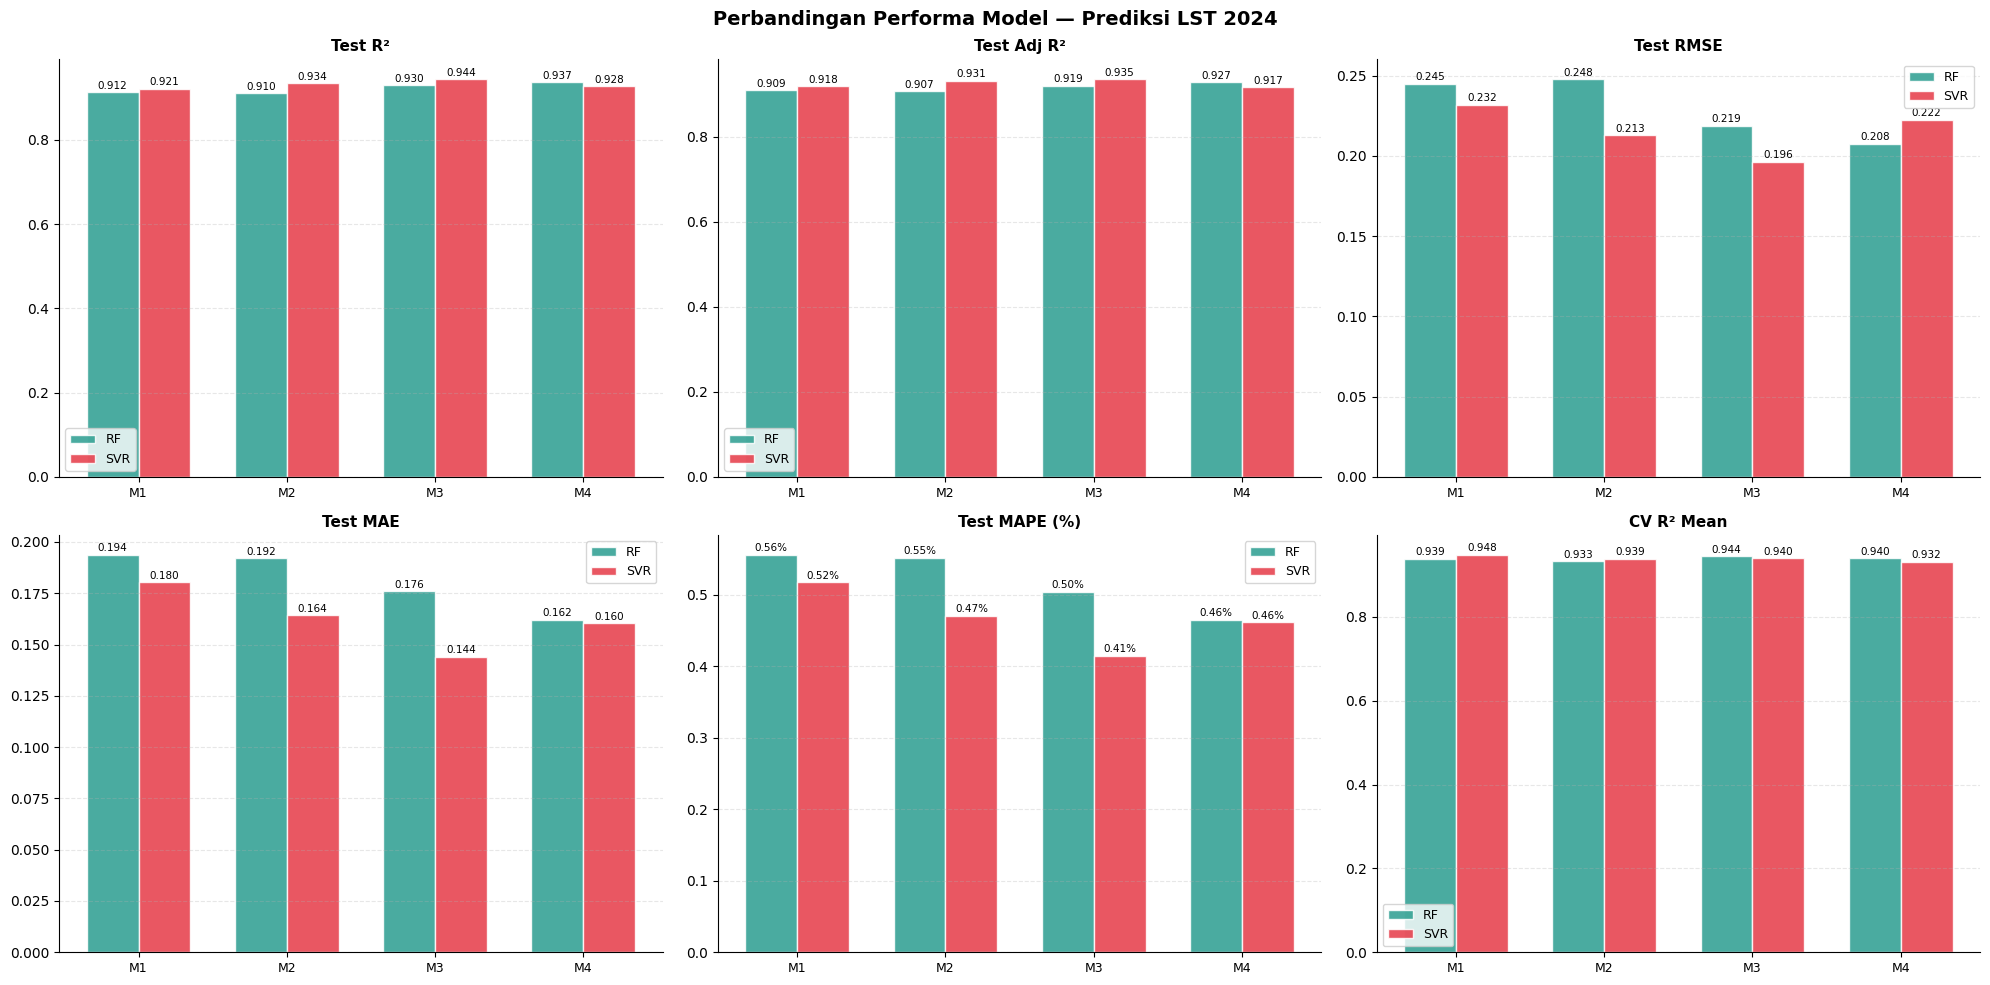

💾 Disimpan: output/regression/plot_metrics_comparison.png


In [101]:
metrics     = ['Test_R2', 'Test_Adj_R2', 'Test_RMSE', 'Test_MAE', 'Test_MAPE', 'CV_R2_Mean']
m_titles    = ['Test R²', 'Test Adj R²', 'Test RMSE', 'Test MAE', 'Test MAPE (%)', 'CV R² Mean']
algos       = ['RF', 'SVR']
configs     = [cfg['label'] for cfg in MODEL_CONFIGS.values()]
x           = np.arange(len(configs))
width       = 0.35
algo_colors = ['#2A9D8F', '#E63946']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle(f'Perbandingan Performa Model — Prediksi LST {TARGET_YEAR}',
             fontsize=14, fontweight='bold')

for ax, metric, title in zip(axes.flatten(), metrics, m_titles):
    for i, algo in enumerate(algos):
        vals = df_summary[df_summary['Algorithm'] == algo][metric].values
        bars = ax.bar(x + i * width - width/2, vals, width,
                      label=algo, color=algo_colors[i], alpha=0.85,
                      edgecolor='white')
        fmt = '%.2f%%' if metric == 'Test_MAPE' else '%.3f'
        ax.bar_label(bars, fmt=fmt, fontsize=7.5, padding=1)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([c.split(':')[0] for c in configs], fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'plot_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}plot_metrics_comparison.png')

## 🎯 Sel 10 — Plot Prediksi vs Aktual (Scatter)

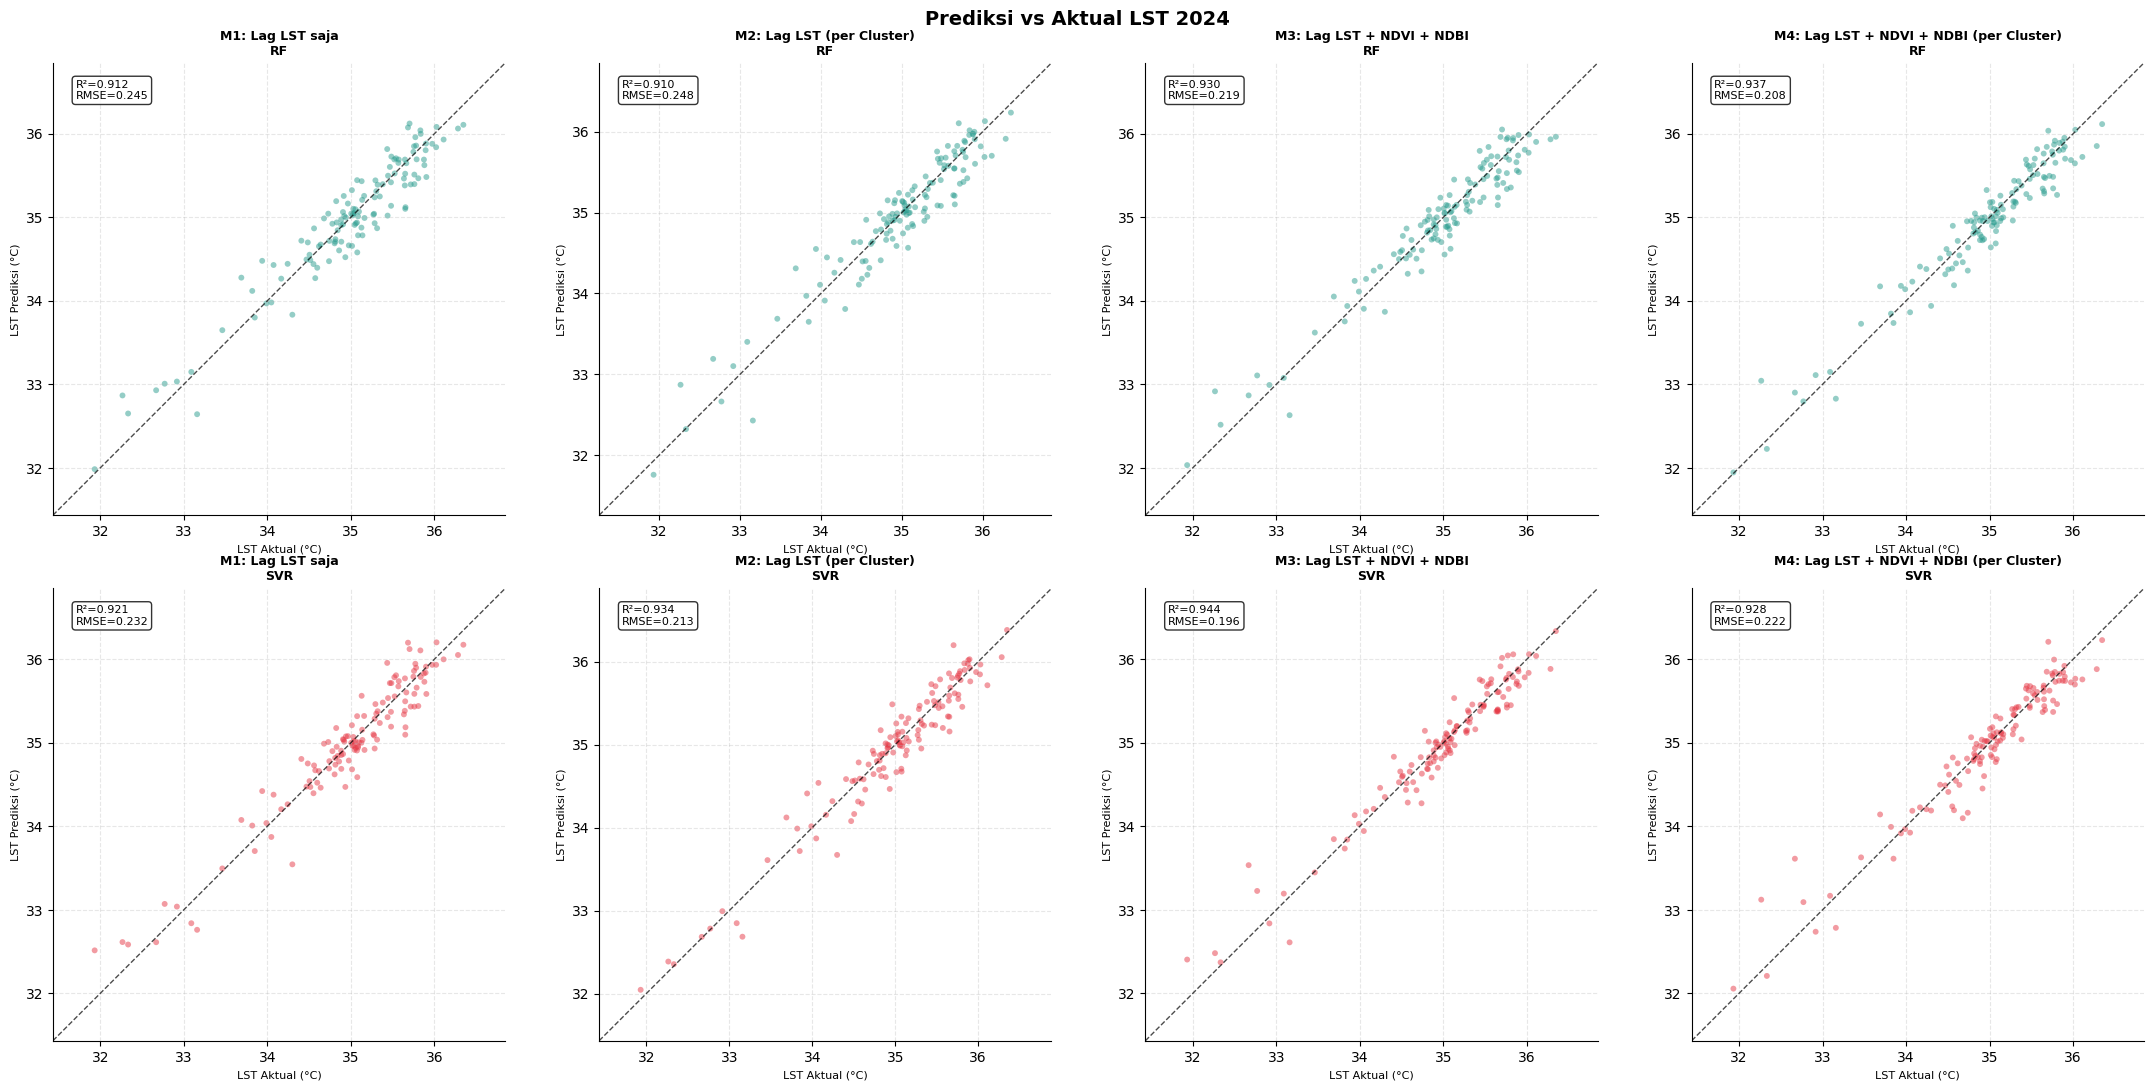

💾 Disimpan: output/regression/plot_scatter_pred_vs_actual.png


In [102]:
cfg_keys = list(MODEL_CONFIGS.keys())
n_cfg    = len(cfg_keys)
n_algo   = 2  # RF, SVR

fig, axes = plt.subplots(n_algo, n_cfg, figsize=(5.5 * n_cfg, 5.5 * n_algo))
fig.suptitle(f'Prediksi vs Aktual LST {TARGET_YEAR}',
             fontsize=14, fontweight='bold')

palette_scatter = ['#2A9D8F', '#E63946']

for row_i, algo in enumerate(['RF', 'SVR']):
    for col_i, cfg_key in enumerate(cfg_keys):
        ax   = axes[row_i][col_i]
        res  = all_results[(cfg_key, algo)]
        y_t  = res['y_test']
        y_p  = res['y_pred_test']
        r2   = res['Test_R2']
        rmse = res['Test_RMSE']

        ax.scatter(y_t, y_p, alpha=0.5, s=18,
                   color=palette_scatter[row_i], edgecolors='none')

        # Garis perfect prediction
        lims = [min(y_t.min(), y_p.min()) - 0.5,
                max(y_t.max(), y_p.max()) + 0.5]
        ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.7)

        ax.set_title(f'{MODEL_CONFIGS[cfg_key]["label"]}\n{algo}',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('LST Aktual (°C)', fontsize=8)
        ax.set_ylabel('LST Prediksi (°C)', fontsize=8)
        ax.text(0.05, 0.92, f'R²={r2:.3f}\nRMSE={rmse:.3f}',
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3, linestyle='--')
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'plot_scatter_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}plot_scatter_pred_vs_actual.png')

## 🌲 Sel 11 — Feature Importance (Random Forest)

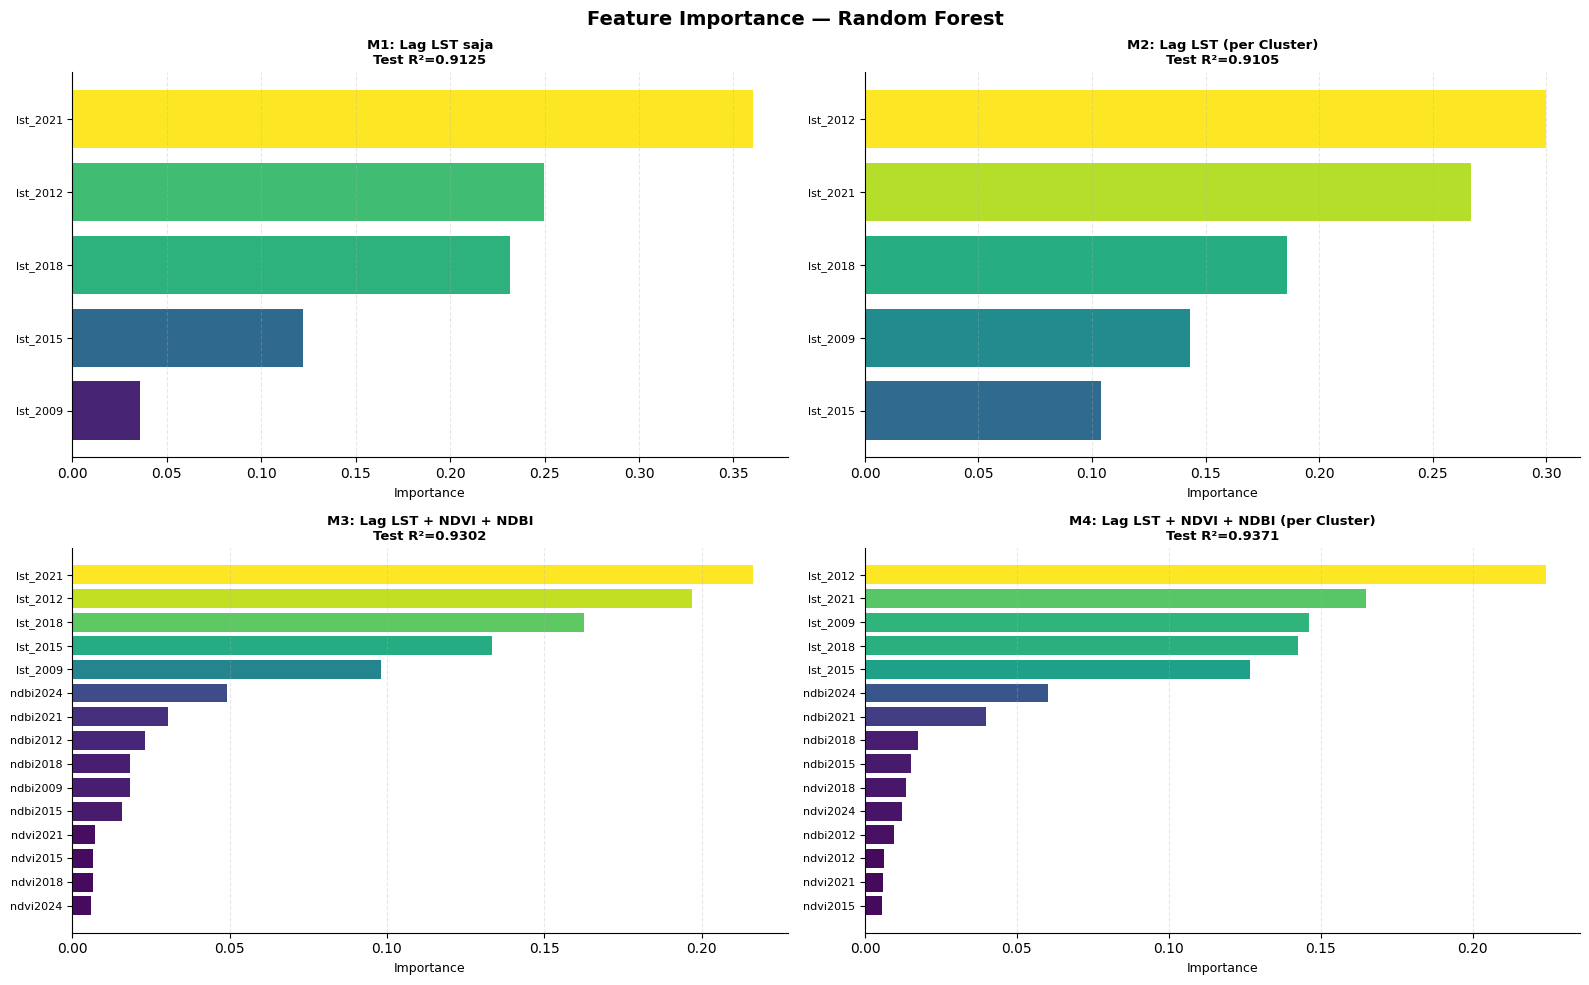

💾 Disimpan: output/regression/plot_feature_importance_rf.png


In [103]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Feature Importance — Random Forest',
             fontsize=14, fontweight='bold')

colors_fi = plt.cm.viridis

for ax, cfg_key in zip(axes.flatten(), cfg_keys):
    res      = all_results[(cfg_key, 'RF')]
    model_rf = res['model_obj']
    feats    = res['features']
    imps     = model_rf.feature_importances_

    # Sort descending
    sorted_idx = np.argsort(imps)[::-1]
    top_n      = min(15, len(feats))
    top_idx    = sorted_idx[:top_n]

    top_feats = [feats[i] for i in top_idx]
    top_imps  = imps[top_idx]

    bar_colors = [colors_fi(v / top_imps.max()) for v in top_imps]
    bars = ax.barh(range(top_n), top_imps[::-1], color=bar_colors[::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_feats[::-1], fontsize=8)
    ax.set_title(f'{MODEL_CONFIGS[cfg_key]["label"]}\n'
                 f'Test R²={res["Test_R2"]:.4f}',
                 fontsize=9.5, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'plot_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}plot_feature_importance_rf.png')

## 🔬 Sel 12 — Analisis SHAP

In [104]:
# ── Fungsi SHAP untuk RF ───────────────────────────────────────────────────
def compute_shap_rf(model, X, feat_names, n_bg=100):
    """Hitung SHAP values untuk Random Forest menggunakan TreeExplainer."""
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    return shap_values  # shape: (n_samples, n_features)


# ── Fungsi SHAP untuk SVR (KernelExplainer — lebih lambat) ───────────────
def compute_shap_svr(pipeline, X_bg, X_exp, feat_names, n_bg=50):
    """Hitung SHAP values untuk SVR Pipeline menggunakan KernelExplainer."""
    # Ambil data background (subsample untuk efisiensi)
    bg_idx  = np.random.choice(len(X_bg), min(n_bg, len(X_bg)), replace=False)
    X_bg_s  = X_bg[bg_idx]

    # Wrapper: scaler sudah ada di pipeline
    f = lambda x: pipeline.predict(x)
    explainer   = shap.KernelExplainer(f, X_bg_s)
    shap_values = explainer.shap_values(X_exp, nsamples=100)
    return shap_values

###  (A) SHAP Summary Plot — semua konfigurasi model × RF

🔬 Menghitung SHAP values (RF) ...


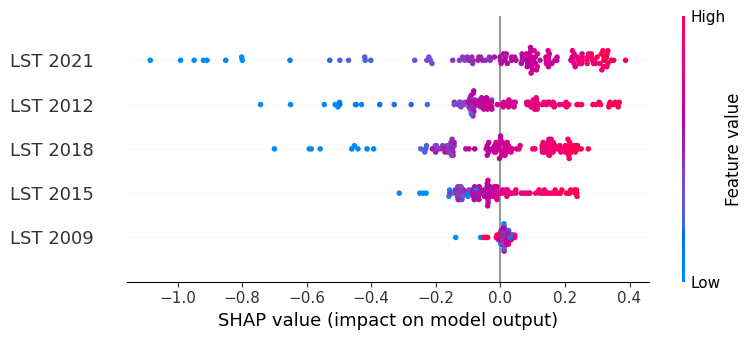

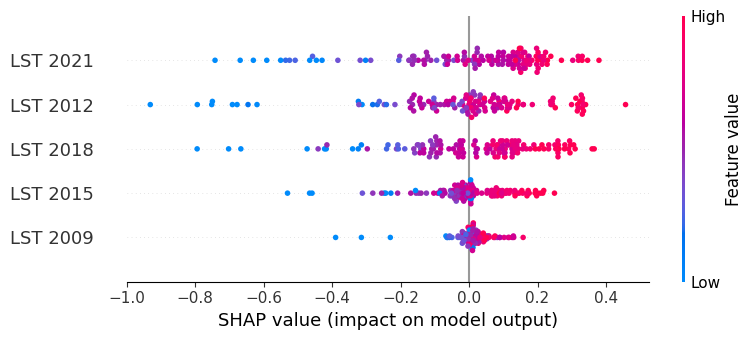

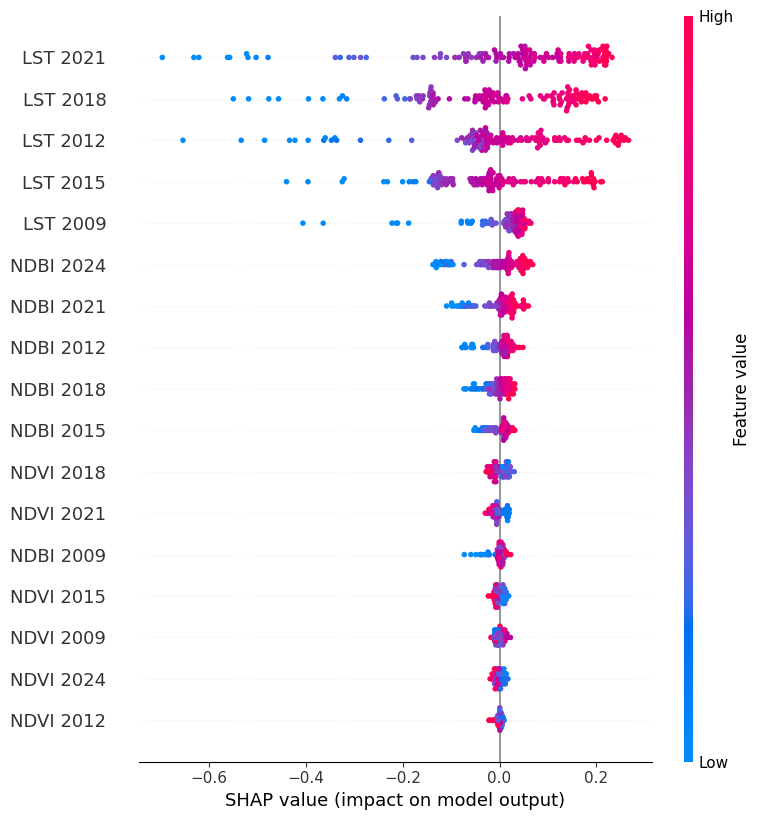

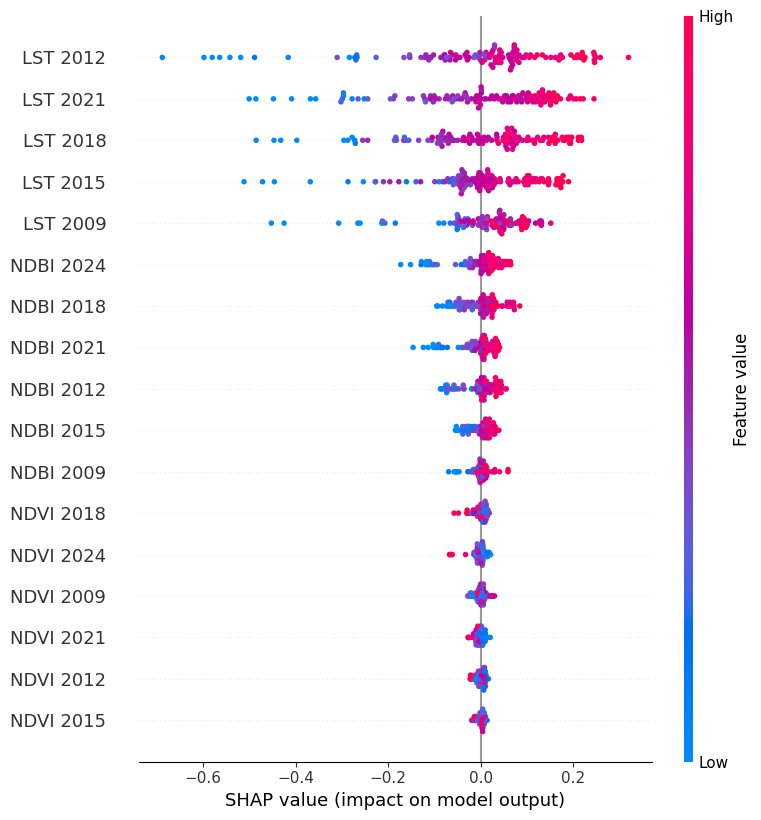

In [105]:
# =========================================================
# 🔧 HELPER (WAJIB DI ATAS — BIAR NGGAK ERROR)
# =========================================================
import re

def format_feature_label(feat: str) -> str:
    LABEL_MAP = {
        'NDBI': 'NDBI',
        'NDVI': 'NDVI',
        'LST': 'LST',
    }
    feat = feat.replace('-', ' ').replace('_', ' ')
    feat = re.sub(r'([A-Za-z])(\d)', r'\1 \2', feat)
    feat = re.sub(r'(\d)([A-Za-z])', r'\1 \2', feat)
    parts = feat.split()
    return ' '.join(LABEL_MAP.get(p.upper(), p.upper()) for p in parts)


# =========================================================
# 🔬 SHAP SUMMARY PLOT
# =========================================================
print('🔬 Menghitung SHAP values (RF) ...')

shap_store = {}

for cfg_key in cfg_keys:
    cfg   = MODEL_CONFIGS[cfg_key]
    res   = all_results[(cfg_key, 'RF')]
    feats = res['features']

    if not cfg['split_by_cluster']:
        model_rf = res['model_obj']
        X_exp    = res['X_test']
        sv       = compute_shap_rf(model_rf, X_exp, feats)
    else:
        sv_list, X_list = [], []
        for cl in clusters:
            m    = res['cluster_models'][cl]['RF']
            X_te = res['cluster_X_test'][cl]
            sv_c = compute_shap_rf(m, X_te, feats)
            sv_list.append(sv_c)
            X_list.append(X_te)
        sv = np.vstack(sv_list)
        X_exp = np.vstack(X_list)

    shap_store[(cfg_key, 'RF')] = {'sv': sv, 'X': X_exp, 'feats': feats}

    # ===== format label =====
    feats_fmt = [format_feature_label(f) for f in feats]

    # ===== sorting =====
    mean_abs   = np.abs(sv).mean(axis=0)
    sorted_idx = np.argsort(mean_abs)[::-1]

    sv_sorted    = sv[:, sorted_idx]
    X_sorted     = X_exp[:, sorted_idx]
    feats_sorted = [feats_fmt[i] for i in sorted_idx]

    # ===== plot =====
    plt.figure(figsize=(10, max(6, len(feats)*0.4)))

    shap.summary_plot(
        sv_sorted,
        X_sorted,
        feature_names=feats_sorted,
        show=False,
        max_display=len(feats),
    )

    plt.tight_layout()
    fname = OUTPUT_DIR + f'shap_summary_rf_{cfg_key}.png'
    plt.savefig(fname, dpi=150)
    plt.show()

###  (B) SHAP Bar Plot — Mean |SHAP| per fitur (RF)

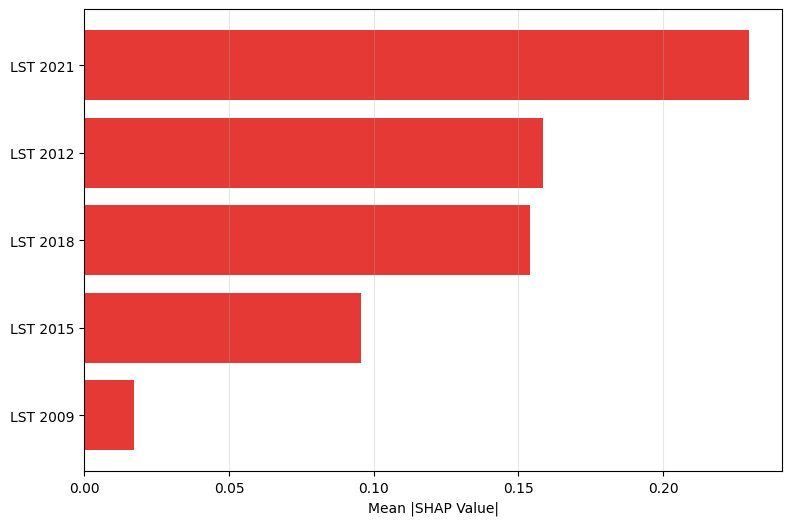

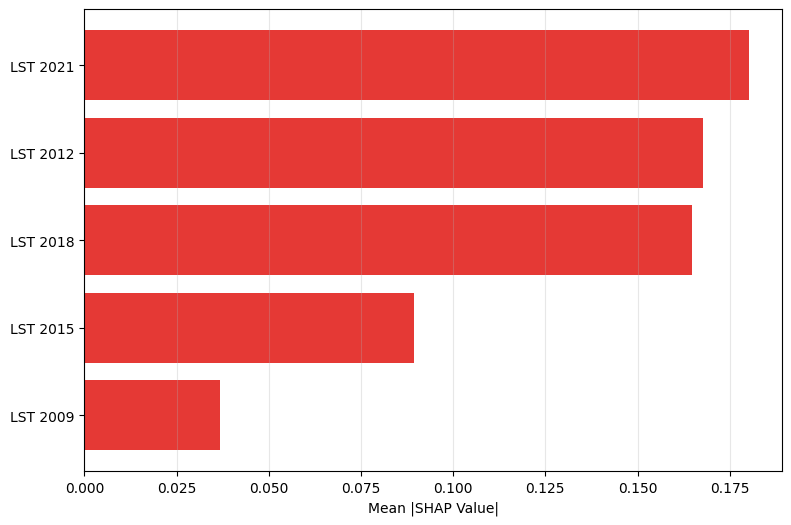

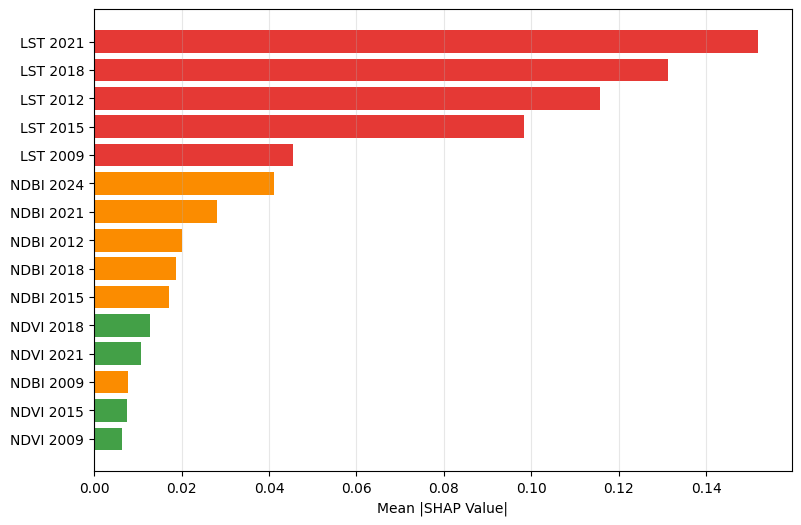

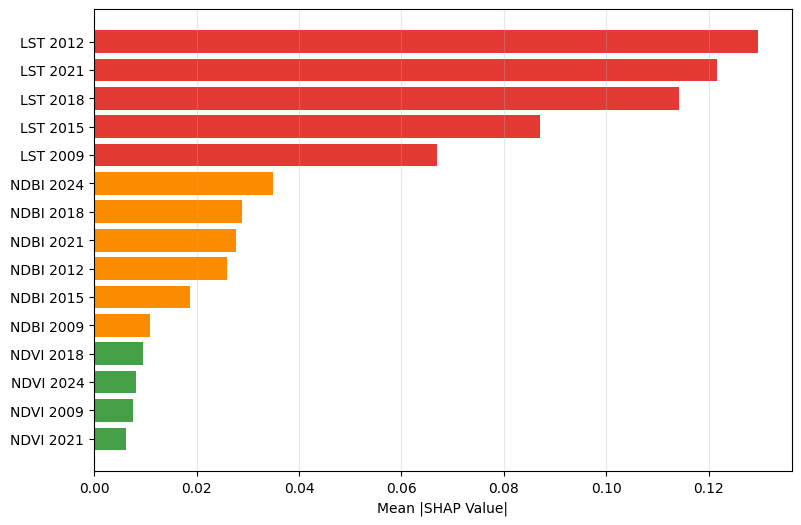

In [106]:
# =========================================================
# 🎨 WARNA FITUR
# =========================================================
FEATURE_COLOR_MAP = {
    'LST'  : '#e53935',
    'NDVI' : '#43a047',
    'NDBI' : '#fb8c00',
}
DEFAULT_COLOR = '#757575'

def get_feature_type(feat: str) -> str:
    feat_upper = feat.upper().replace('_', '').replace('-', '')
    for key in FEATURE_COLOR_MAP:
        if feat_upper.startswith(key):
            return key
    return None


# =========================================================
# 📊 SHAP BAR PLOT
# =========================================================
for cfg_key in cfg_keys:
    store = shap_store[(cfg_key, 'RF')]
    sv    = store['sv']
    feats = store['feats']

    mean_abs   = np.abs(sv).mean(axis=0)
    sorted_idx = np.argsort(mean_abs)[::-1]

    top_n = min(15, len(feats))
    top_idx = sorted_idx[:top_n]

    top_feats_raw = [feats[i] for i in top_idx]
    top_feats_fmt = [format_feature_label(feats[i]) for i in top_idx]
    top_vals      = mean_abs[top_idx]

    colors = [
        FEATURE_COLOR_MAP.get(get_feature_type(f), DEFAULT_COLOR)
        for f in top_feats_raw
    ]

    plt.figure(figsize=(9,6))
    plt.barh(range(top_n), top_vals[::-1], color=colors[::-1])
    plt.yticks(range(top_n), top_feats_fmt[::-1])
    plt.xlabel('Mean |SHAP Value|')
    plt.grid(axis='x', alpha=0.3)

    fname = OUTPUT_DIR + f'shap_bar_rf_{cfg_key}.png'
    plt.savefig(fname, dpi=150)
    plt.show()

###  (C) SHAP per Cluster — Model M2 & M4 (yang split_by_cluster)

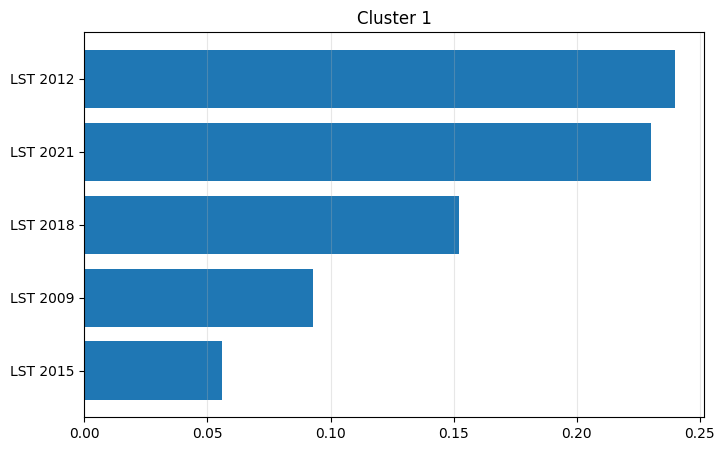

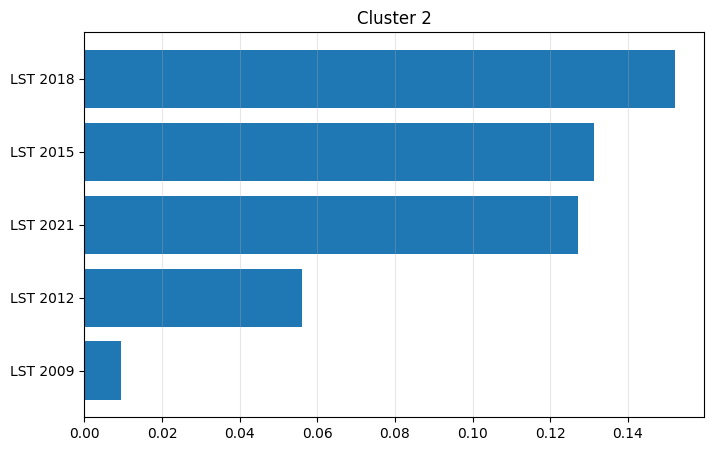

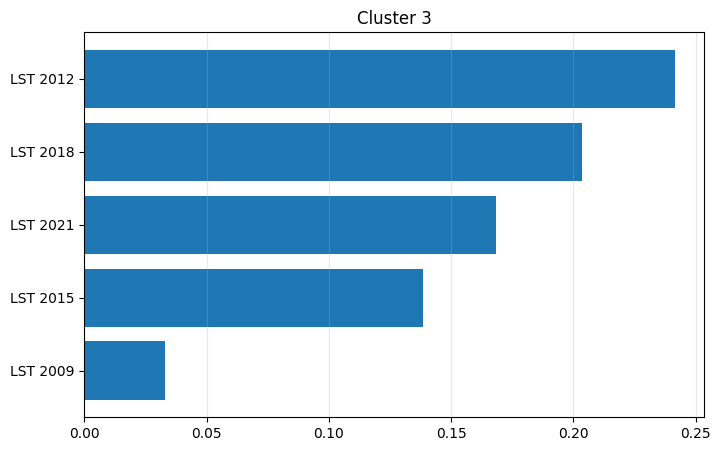

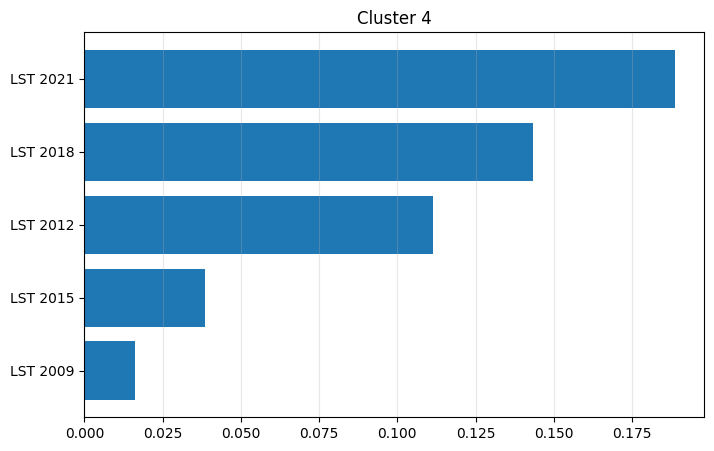

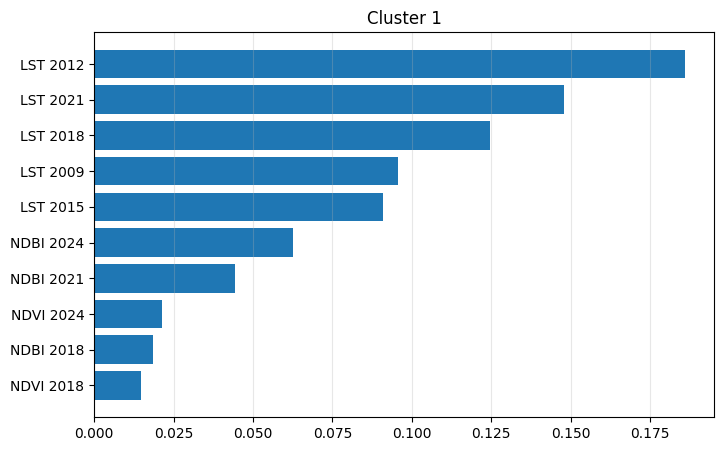

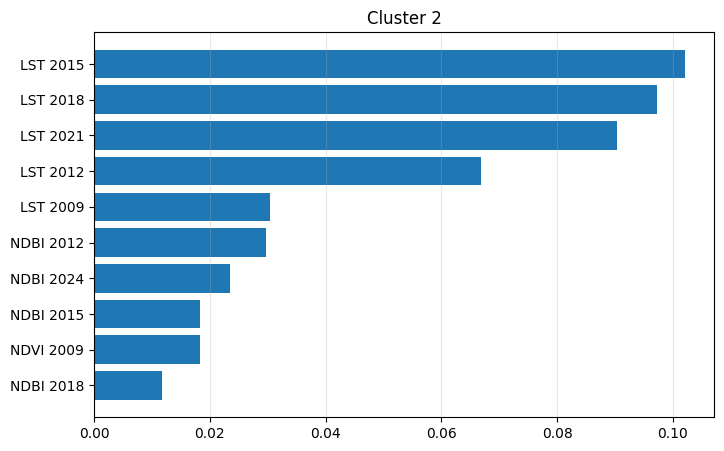

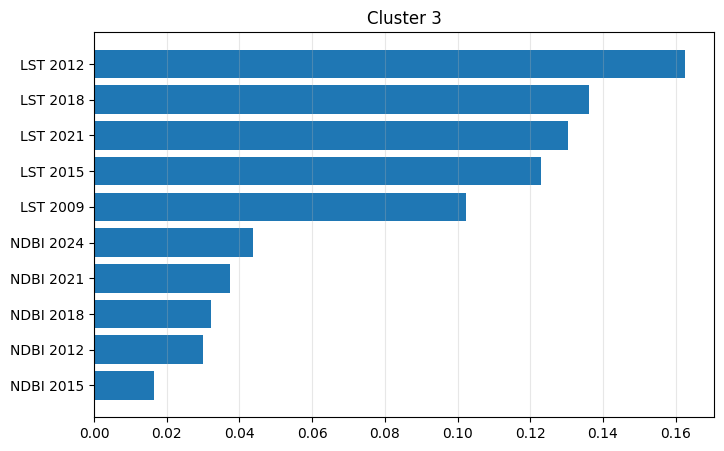

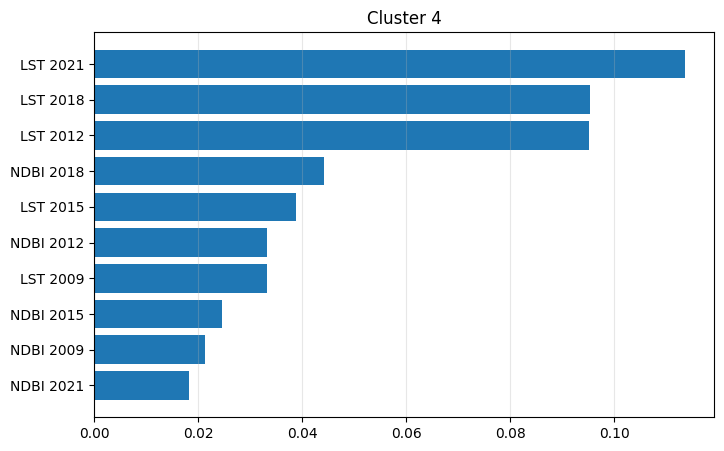

In [107]:
cluster_cfg_keys = [k for k,v in MODEL_CONFIGS.items() if v['split_by_cluster']]

for cfg_key in cluster_cfg_keys:
    res   = all_results[(cfg_key, 'RF')]
    feats = res['features']

    for cl in clusters:
        model = res['cluster_models'][cl]['RF']
        X_te  = res['cluster_X_test'][cl]

        sv = compute_shap_rf(model, X_te, feats)

        mean_abs   = np.abs(sv).mean(axis=0)
        sorted_idx = np.argsort(mean_abs)[::-1]

        top_n = min(10, len(feats))
        top_idx = sorted_idx[:top_n]

        feats_fmt = [format_feature_label(feats[i]) for i in top_idx]
        vals      = mean_abs[top_idx]

        plt.figure(figsize=(8,5))
        plt.barh(range(top_n), vals[::-1])
        plt.yticks(range(top_n), feats_fmt[::-1])
        plt.title(f'Cluster {cl}')
        plt.grid(axis='x', alpha=0.3)

        fname = OUTPUT_DIR + f'shap_cluster_{cfg_key}_{cl}.png'
        plt.savefig(fname, dpi=150)
        plt.show()

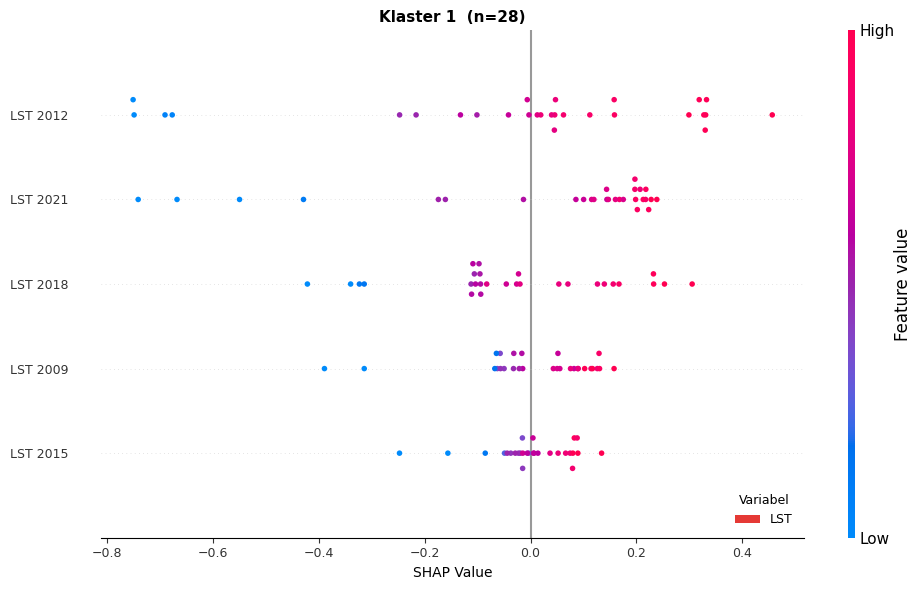

💾 Disimpan: output/regression/shap_beeswarm_M2_LagLST_byCluster_cluster1.png


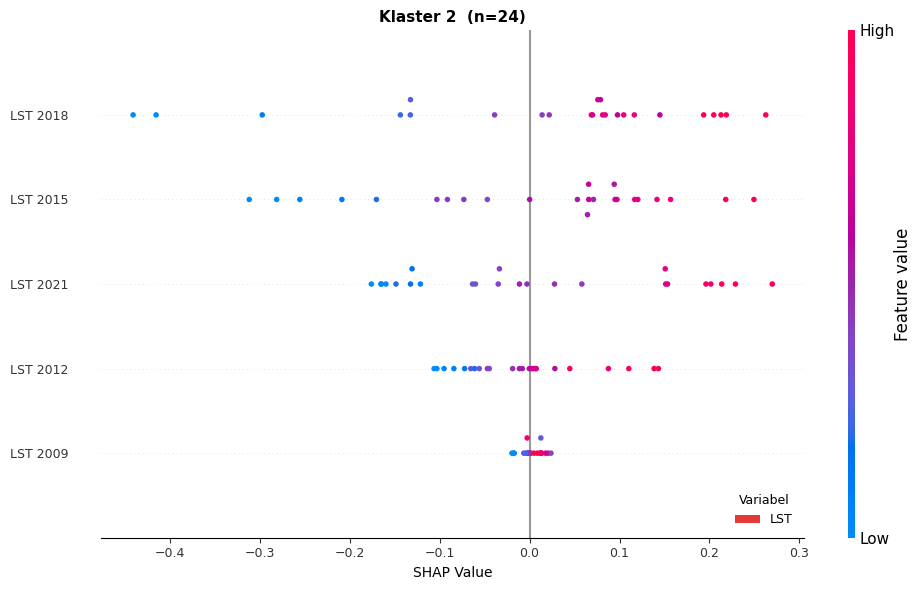

💾 Disimpan: output/regression/shap_beeswarm_M2_LagLST_byCluster_cluster2.png


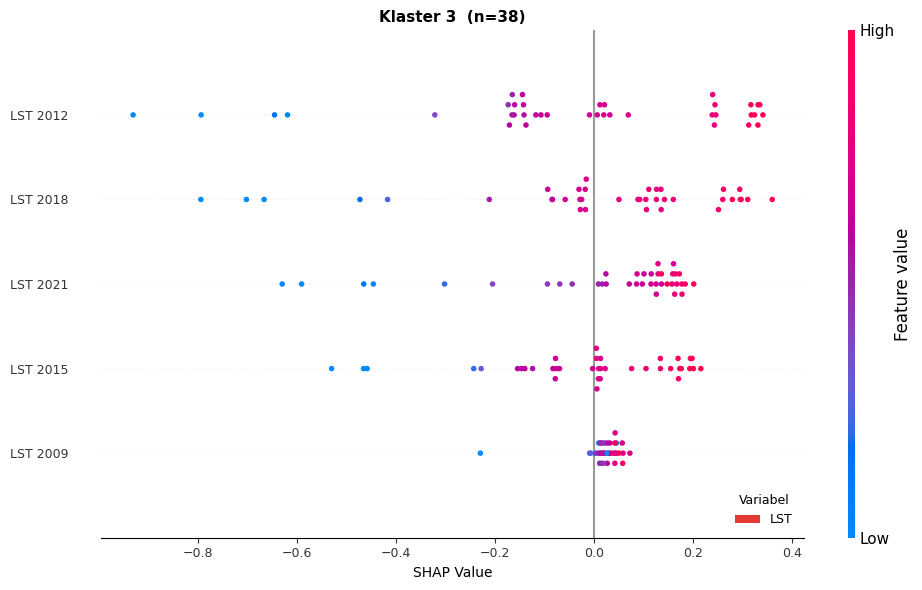

💾 Disimpan: output/regression/shap_beeswarm_M2_LagLST_byCluster_cluster3.png


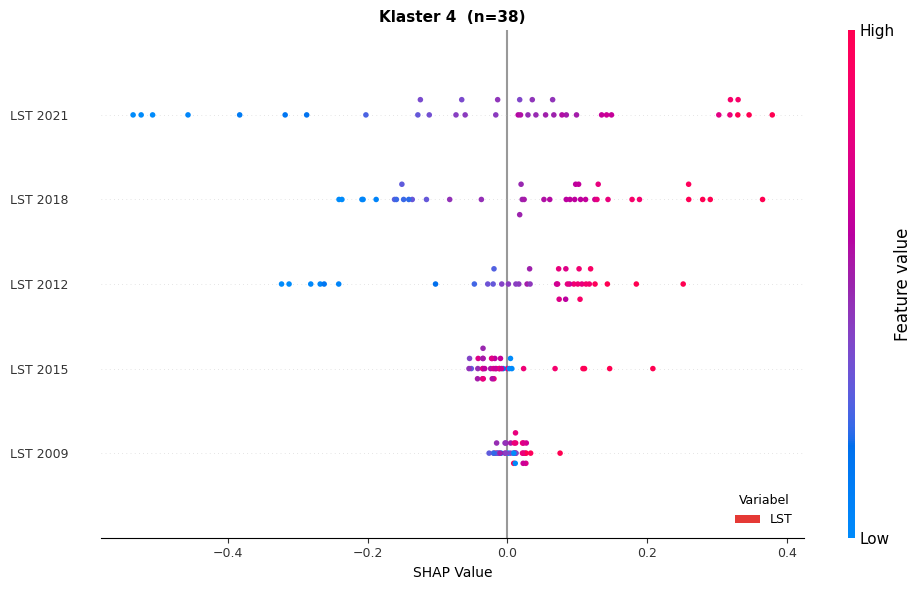

💾 Disimpan: output/regression/shap_beeswarm_M2_LagLST_byCluster_cluster4.png


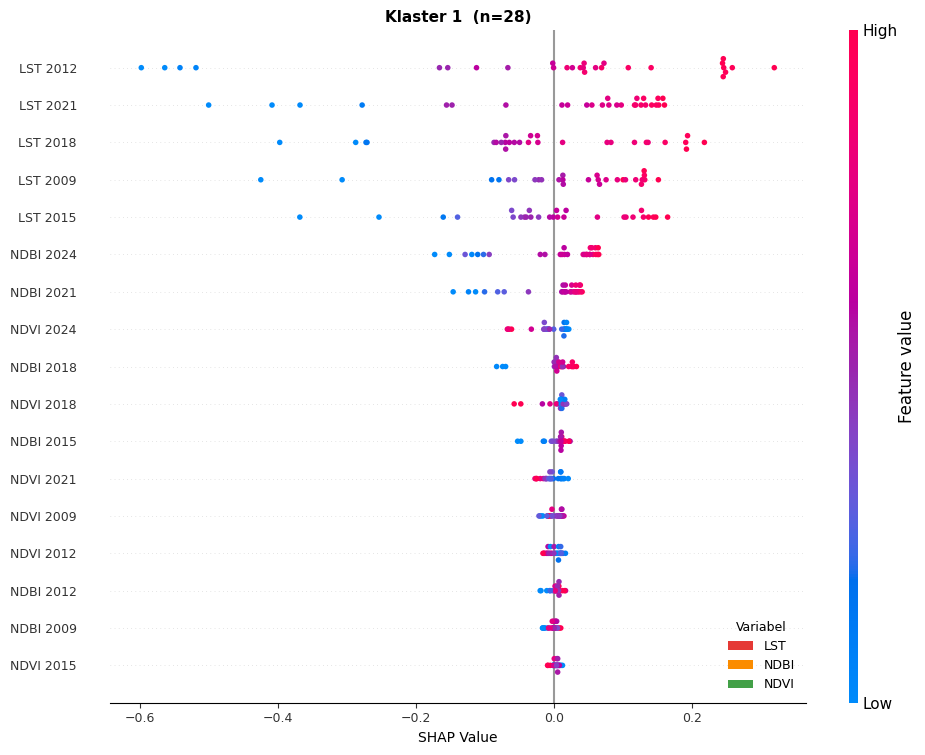

💾 Disimpan: output/regression/shap_beeswarm_M4_LagAll_byCluster_cluster1.png


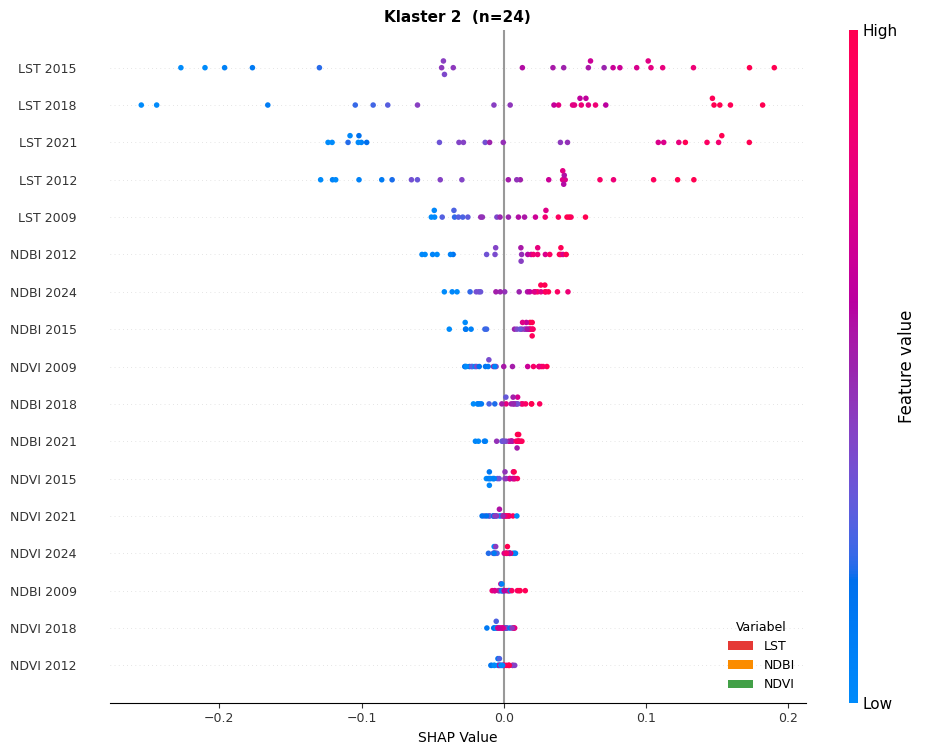

💾 Disimpan: output/regression/shap_beeswarm_M4_LagAll_byCluster_cluster2.png


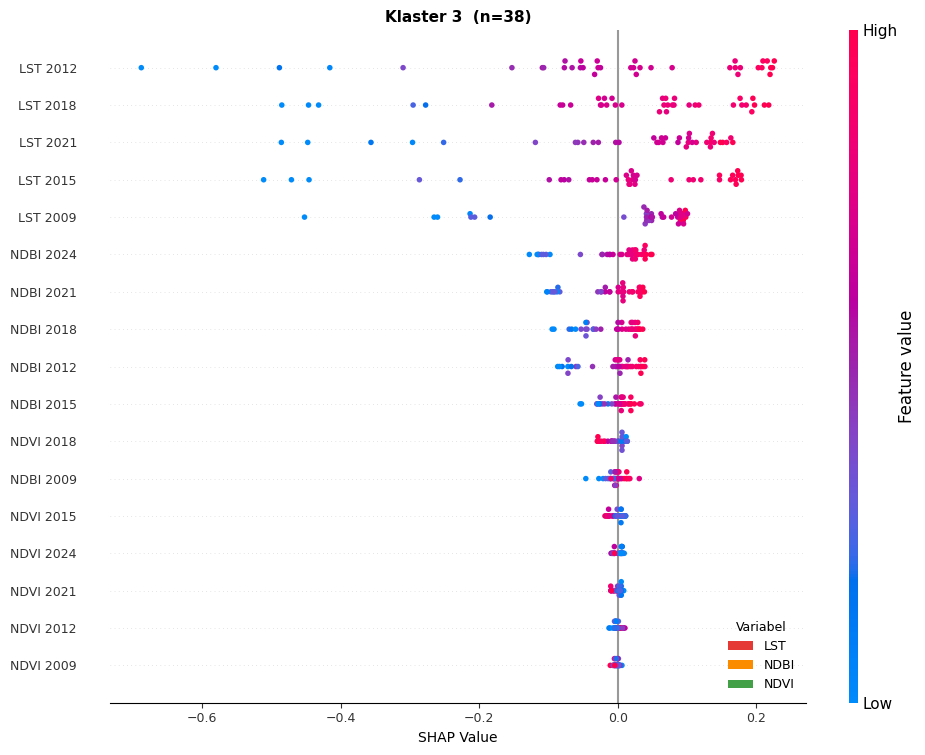

💾 Disimpan: output/regression/shap_beeswarm_M4_LagAll_byCluster_cluster3.png


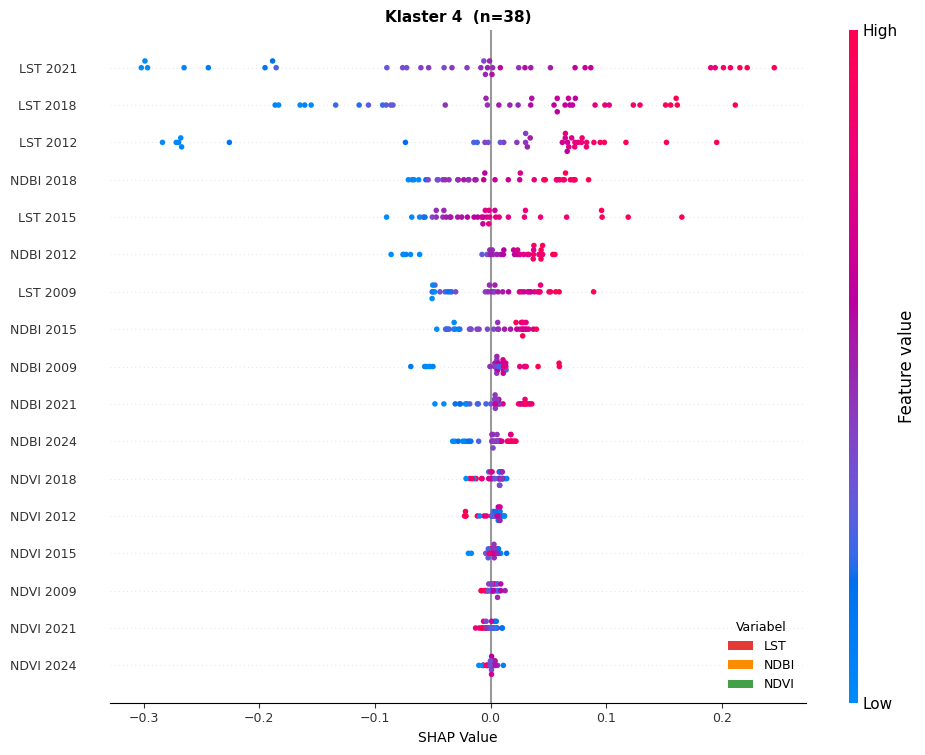

💾 Disimpan: output/regression/shap_beeswarm_M4_LagAll_byCluster_cluster4.png


In [108]:
import re
from matplotlib.patches import Patch

FEATURE_COLOR_MAP = {
    'LST'  : '#e53935',
    'NDVI' : '#43a047',
    'NDBI' : '#fb8c00',
}
DEFAULT_COLOR = '#757575'

def get_feature_type(feat: str) -> str:
    feat_upper = feat.upper().replace('_', '').replace('-', '')
    for key in FEATURE_COLOR_MAP:
        if feat_upper.startswith(key.replace(' ', '')):
            return key
    return None

def format_feature_label(feat: str) -> str:
    LABEL_MAP = {'NDBI': 'NDBI', 'NDVI': 'NDVI', 'LST': 'LST'}
    feat = feat.replace('-', ' ').replace('_', ' ')
    feat = re.sub(r'([A-Za-z])(\d)', r'\1 \2', feat)
    feat = re.sub(r'(\d)([A-Za-z])', r'\1 \2', feat)
    parts = feat.split()
    return ' '.join(LABEL_MAP.get(p.upper(), p.upper()) for p in parts)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cluster_cfg_keys = [k for k, v in MODEL_CONFIGS.items() if v['split_by_cluster']]

for cfg_key in cluster_cfg_keys:
    cfg       = MODEL_CONFIGS[cfg_key]
    res       = all_results[(cfg_key, 'RF')]
    feats     = res['features']
    cl_models = res['cluster_models']
    feats_fmt = [format_feature_label(f) for f in feats]

    for cl in clusters:
        m    = cl_models[cl]['RF']
        X_te = res['cluster_X_test'][cl]
        sv_c = compute_shap_rf(m, X_te, feats)
        n_te = len(res['cluster_y_test'][cl])

        # Urutkan semua fitur berdasarkan mean |SHAP|
        mean_abs   = np.abs(sv_c).mean(axis=0)
        sorted_idx = np.argsort(mean_abs)[::-1]
        top_n      = len(feats)                      # semua fitur

        sv_sorted    = sv_c[:, sorted_idx]
        X_sorted     = X_te[:, sorted_idx]
        feats_sorted = [feats_fmt[i] for i in sorted_idx]

        # Warna dot berdasarkan jenis variabel (override colormap SHAP)
        dot_colors = [
            FEATURE_COLOR_MAP.get(get_feature_type(feats[i]), DEFAULT_COLOR)
            for i in sorted_idx
        ]

        fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.45)))
        plt.sca(ax)

        shap.summary_plot(
            sv_sorted,
            X_sorted,
            feature_names=feats_sorted,
            show=False,
            plot_size=None,
            max_display=top_n,
            color_bar=True,
        )

        ax.set_title(f'Klaster {int(cl)}  (n={n_te})', fontsize=11, fontweight='bold')
        ax.set_xlabel('SHAP Value', fontsize=10)
        ax.tick_params(axis='y', labelsize=9)
        ax.tick_params(axis='x', labelsize=9)

        # Legend jenis variabel
        used_types = dict.fromkeys(
            get_feature_type(feats[i]) for i in sorted_idx
        )
        legend_handles = [
            Patch(facecolor=FEATURE_COLOR_MAP.get(t, DEFAULT_COLOR), label=t)
            for t in used_types if t is not None
        ]
        ax.legend(
            handles=legend_handles,
            title='Variabel',
            loc='lower right',
            fontsize=9,
            title_fontsize=9,
            frameon=False,
        )

        plt.tight_layout()
        fname = OUTPUT_DIR + f'shap_beeswarm_{cfg_key}_cluster{int(cl)}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'💾 Disimpan: {fname}')
        plt.close()

###  (D) SHAP Dependence Plot — Fitur terpenting (model terbaik RF)

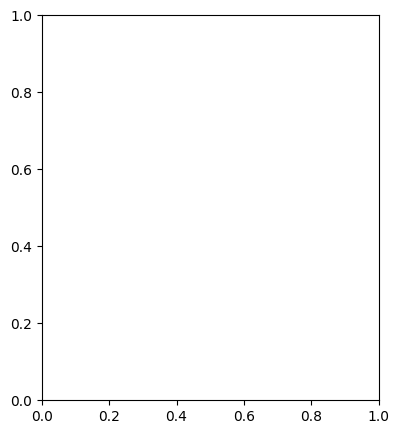

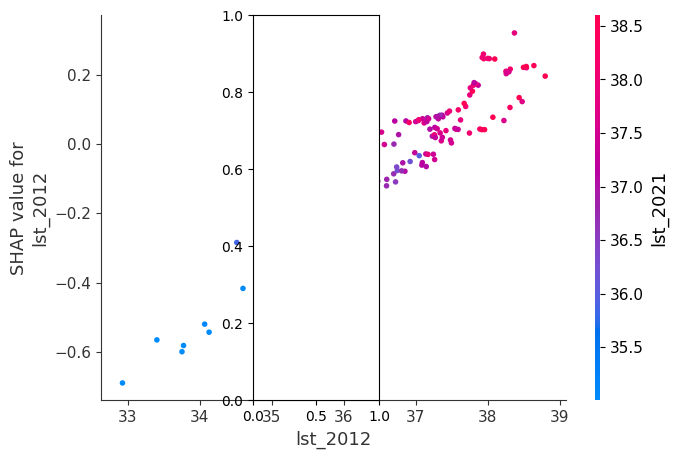

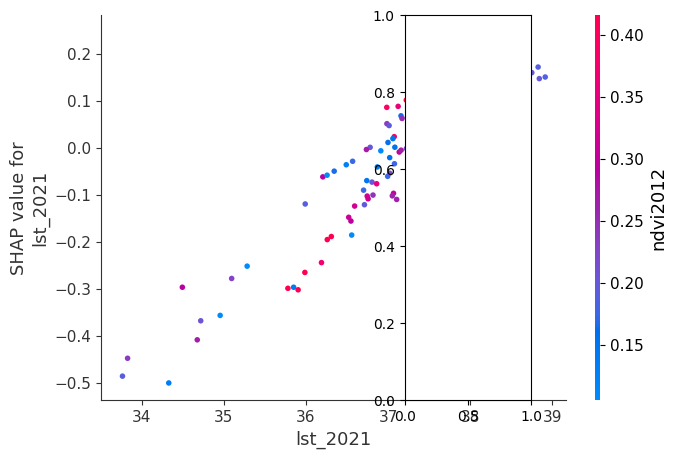

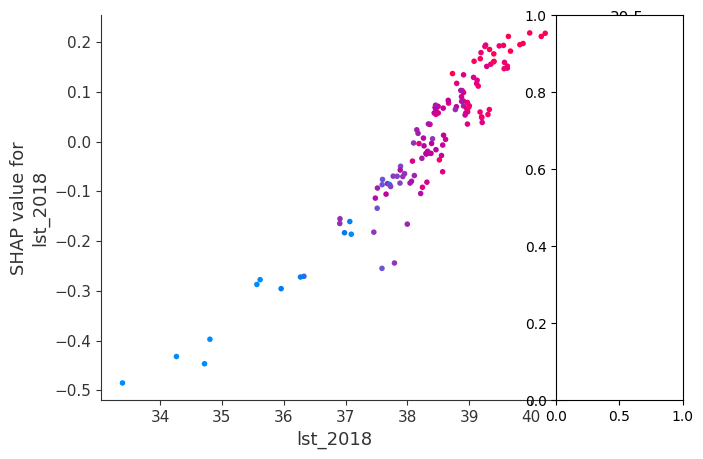

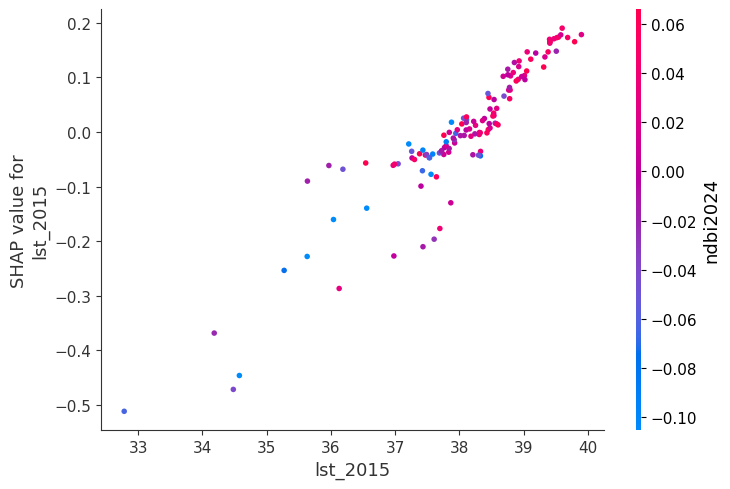

In [109]:
# model terbaik RF
df_rf = df_summary[df_summary['Algorithm']=='RF'].reset_index(drop=True)
best_cfg_key = cfg_keys[df_rf['Test_R2'].idxmax()]

store = shap_store[(best_cfg_key, 'RF')]
sv    = store['sv']
X     = store['X']
feats = store['feats']

top_idx = np.argsort(np.abs(sv).mean(axis=0))[::-1][:4]
top_feats = [feats[i] for i in top_idx]

plt.figure(figsize=(20,5))

for i, feat in enumerate(top_feats):
    plt.subplot(1,4,i+1)
    shap.dependence_plot(
        feats.index(feat),
        sv,
        X,
        feature_names=feats,
        show=False
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_dependence.png', dpi=150)
plt.show()

## 🗺️ Sel 13 — Residual Map per Grid (Model Terbaik)

Model terbaik RF  : M4: Lag LST + NDVI + NDBI (per Cluster)
Model terbaik SVR : M3: Lag LST + NDVI + NDBI


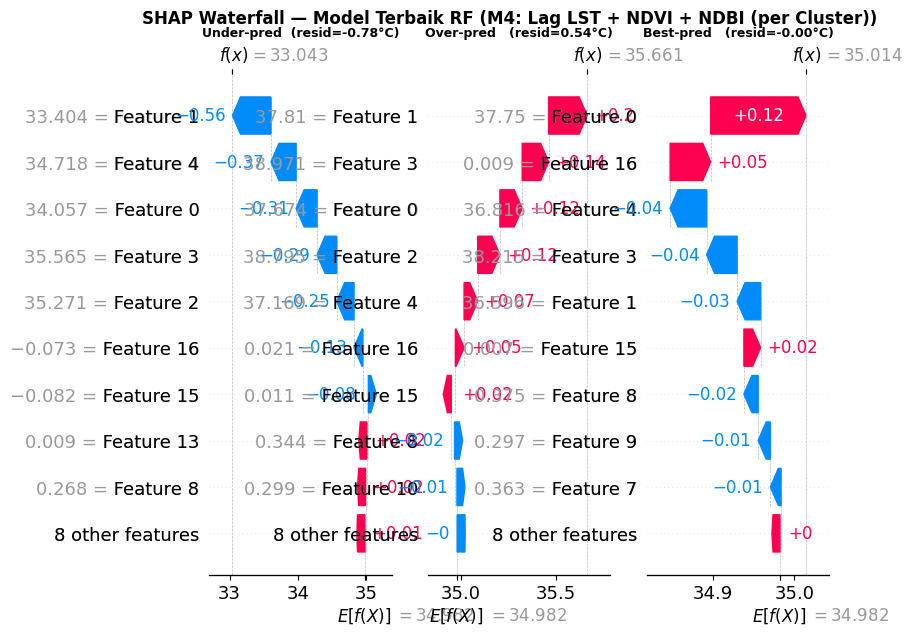

💾 Disimpan: output/regression/shap_waterfall_samples.png


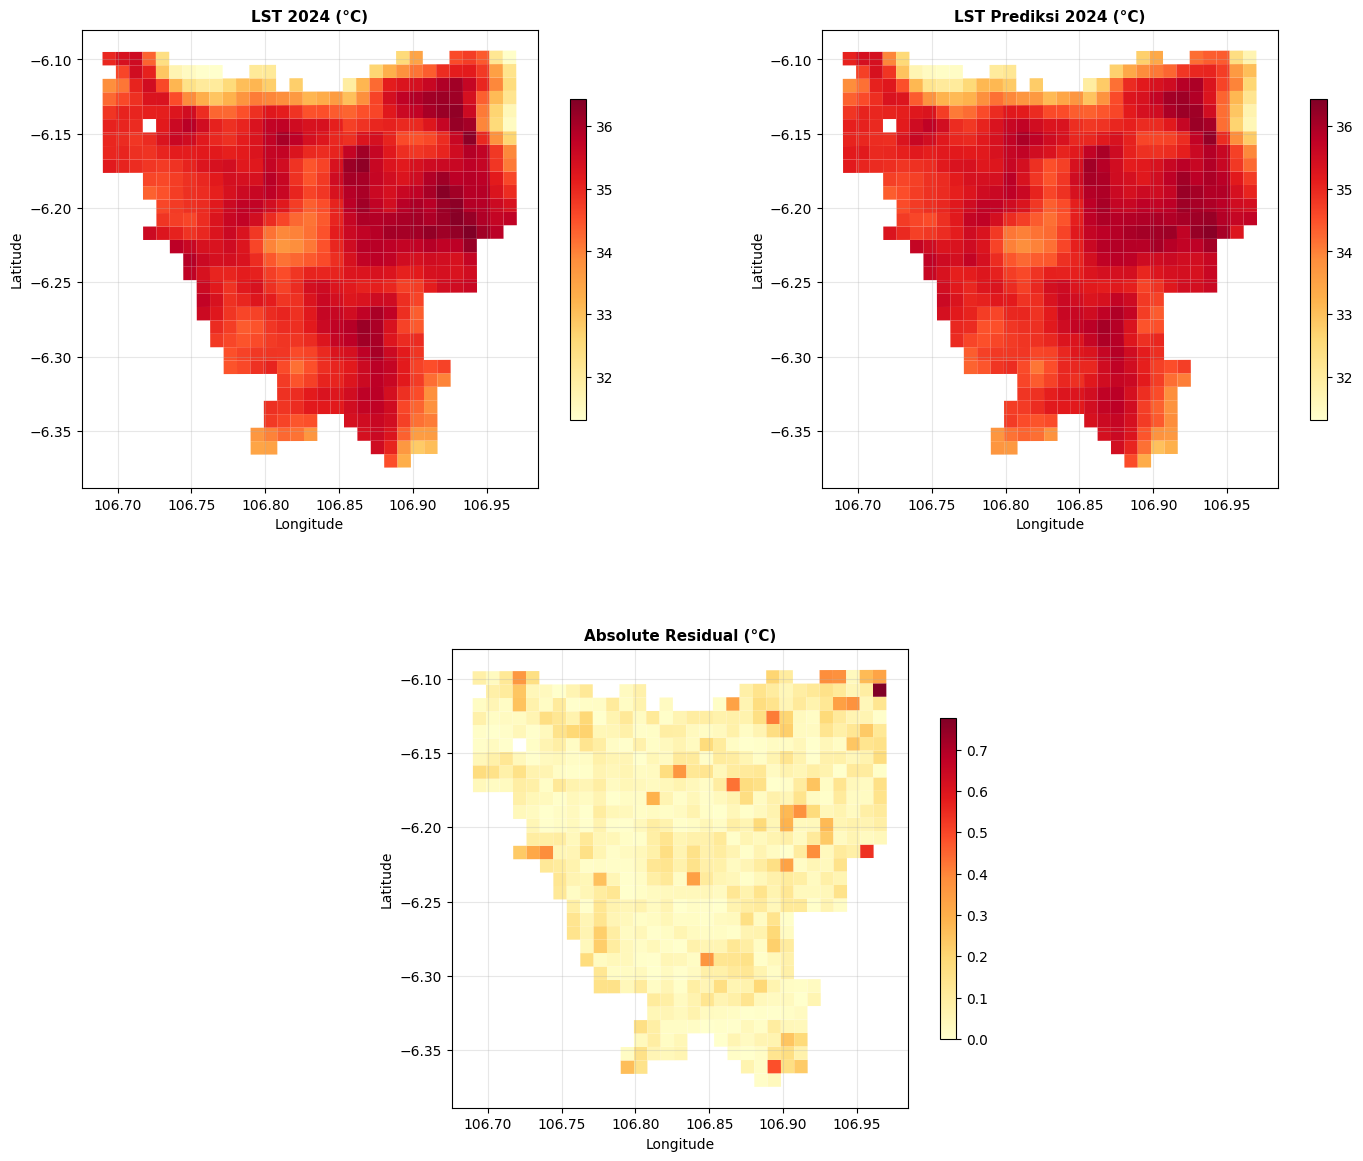

💾 Disimpan: output/regression/peta_prediksi_residual.png


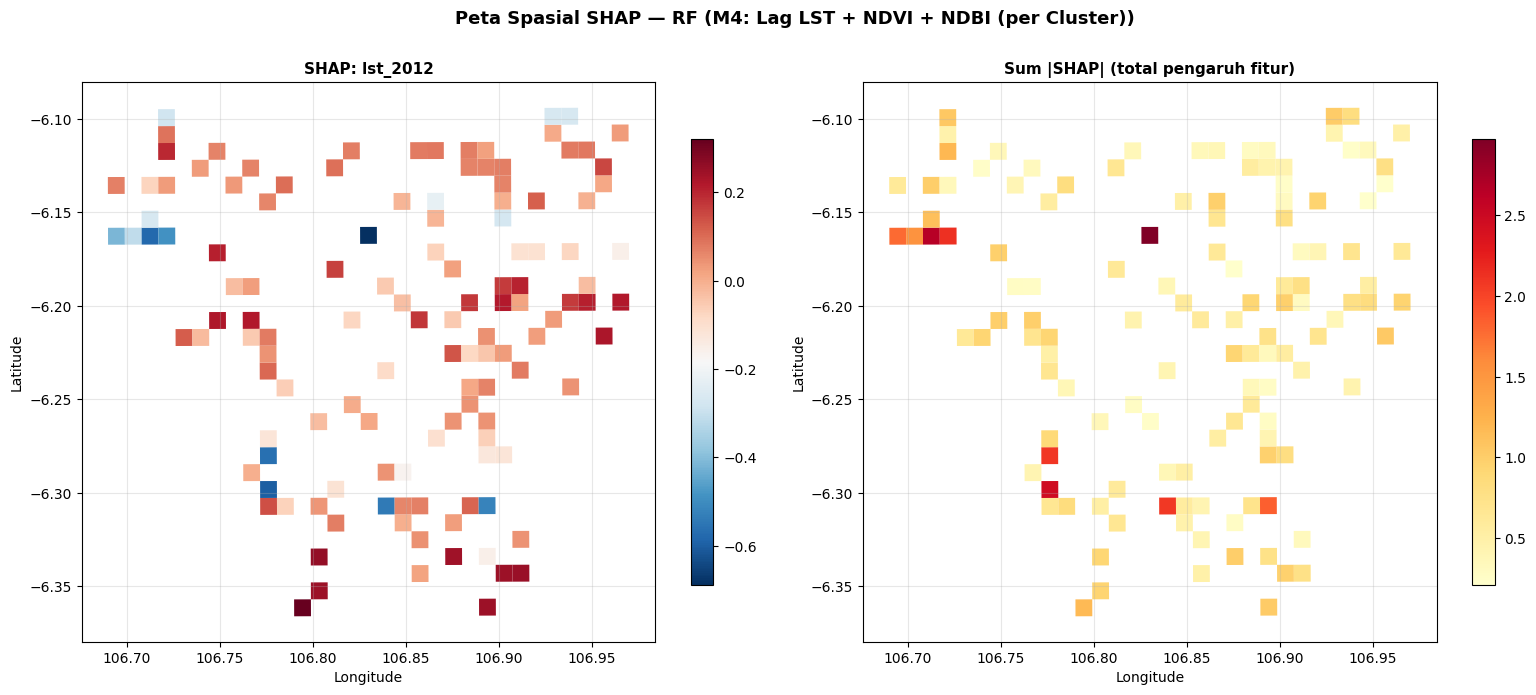

💾 Disimpan: output/regression/shap_spatial_map.png


In [110]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  TENTUKAN MODEL TERBAIK RF (dipakai Sel 12, 13, 14)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ✅ PERBAIKAN: reset_index dulu agar idxmax() → 0,1,2,3 sesuai posisi cfg_keys
df_rf  = df_summary[df_summary['Algorithm'] == 'RF'].reset_index(drop=True)
df_svr = df_summary[df_summary['Algorithm'] == 'SVR'].reset_index(drop=True)

best_cfg_key_rf = cfg_keys[df_rf['Test_R2'].idxmax()]   # pakai di SHAP
best_rf_key     = best_cfg_key_rf                        # pakai di peta
best_svr_key    = cfg_keys[df_svr['Test_R2'].idxmax()]

print(f'Model terbaik RF  : {MODEL_CONFIGS[best_rf_key]["label"]}')
print(f'Model terbaik SVR : {MODEL_CONFIGS[best_svr_key]["label"]}')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  (E) SHAP Waterfall — 3 sampel (under/over/well predicted)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

res_best  = all_results[(best_cfg_key_rf, 'RF')]
y_te_best = res_best['y_test']
y_pr_best = res_best['y_pred_test']
residuals = y_te_best - y_pr_best

idx_under = np.argmin(residuals)
idx_over  = np.argmax(residuals)
idx_good  = np.argmin(np.abs(residuals))

model_best   = res_best['model_obj']
X_te_best    = res_best['X_test']
explainer_wf = shap.TreeExplainer(model_best)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle(f'SHAP Waterfall — Model Terbaik RF ({MODEL_CONFIGS[best_cfg_key_rf]["label"]})',
             fontsize=12, fontweight='bold')

sample_labels = [
    (idx_under, f'Under-pred  (resid={residuals[idx_under]:.2f}°C)'),
    (idx_over,  f'Over-pred   (resid={residuals[idx_over]:.2f}°C)'),
    (idx_good,  f'Best-pred   (resid={residuals[idx_good]:.2f}°C)'),
]

for ax, (s_idx, s_label) in zip(axes, sample_labels):
    plt.sca(ax)
    sv_exp = explainer_wf(X_te_best[s_idx:s_idx+1])
    shap.waterfall_plot(sv_exp[0], max_display=10, show=False)
    ax.set_title(s_label, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_waterfall_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}shap_waterfall_samples.png')

"""## 🗺️ Sel 13 — Residual Map per Grid (Model Terbaik RF)"""

# best_rf_key & best_svr_key sudah ditetapkan di atas ✅

res_best_rf = all_results[(best_rf_key, 'RF')]
feats_best  = res_best_rf['features']
cfg_best    = MODEL_CONFIGS[best_rf_key]

y_all = df[TARGET_COL].values

if not cfg_best['split_by_cluster']:
    model_rf_best = res_best_rf['model_obj']
    X_all         = df[feats_best].values
    y_pred_all    = model_rf_best.predict(X_all)
else:
    y_pred_all = np.full(len(df), np.nan)
    for cl in clusters:
        m      = res_best_rf['cluster_models'][cl]['RF']
        idx_cl = df.index[df[CLUSTER_COL] == cl].tolist()
        X_cl   = df.loc[idx_cl, feats_best].values
        y_pred_all[idx_cl] = m.predict(X_cl)

residuals_all = y_all - y_pred_all

df_pred = df[['grid_id', TARGET_COL]].copy()
df_pred['predicted'] = y_pred_all
df_pred['residual']  = residuals_all
df_pred['abs_error'] = np.abs(residuals_all)

gdf_map = (
    gdf_geom
    .merge(df_pred, on='grid_id', how='inner')
)
gdf_map = gpd.GeoDataFrame(gdf_map, geometry='geometry')
fig = plt.figure(figsize=(18, 14))
cfg_lbl = MODEL_CONFIGS[best_rf_key]['label']
fig.suptitle('')

# ✅ Shared colorbar bounds untuk Aktual & Prediksi
lst_min = min(gdf_map[f'lst_{TARGET_YEAR}'].min(), gdf_map['predicted'].min())
lst_max = max(gdf_map[f'lst_{TARGET_YEAR}'].max(), gdf_map['predicted'].max())
err_min = 0                            # ✅ tambah err_min
err_max = gdf_map['abs_error'].max()

# ✅ Hapus add_subplot lama, pakai GridSpec saja
import matplotlib.gridspec as gridspec
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])     # tengah baris bawah

plot_specs = [
    (ax1, f'lst_{TARGET_YEAR}', 'LST 2024 (°C)',          'YlOrRd', lst_min, lst_max),
    (ax2, 'predicted',           'LST Prediksi 2024 (°C)', 'YlOrRd', lst_min, lst_max),
    (ax3, 'abs_error',           'Absolute Residual (°C)', 'YlOrRd', err_min, err_max),
]

# ✅ ax ikut di plot_specs, bukan zip(axes, ...)
for ax, col, title, cmap, vmin, vmax in plot_specs:
    gdf_map.plot(column=col, ax=ax, cmap=cmap,
                 vmin=vmin, vmax=vmax,
                 legend=True,
                 legend_kwds={'shrink': 0.7},
                 edgecolor='none', linewidth=0)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)

plt.savefig(OUTPUT_DIR + 'peta_prediksi_residual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}peta_prediksi_residual.png')

"""## 🗺️ Sel 14 — SHAP Spatial Map"""

store_best = shap_store[(best_rf_key, 'RF')]
sv_map     = store_best['sv']
feats_map  = store_best['feats']

top1_feat = feats_map[np.abs(sv_map).mean(axis=0).argmax()]
top1_idx  = feats_map.index(top1_feat)

if not cfg_best['split_by_cluster']:
    idx_te_map = idx_test_global
else:
    idx_te_map = res_best_rf['idx_test_union']

df_shap_spatial = df.iloc[idx_te_map][['grid_id']].copy().reset_index(drop=True)
df_shap_spatial[f'shap_{top1_feat}'] = sv_map[:, top1_idx]
df_shap_spatial['shap_sum']          = np.abs(sv_map).sum(axis=1)

gdf_shap = (
    gdf_geom
    .merge(df_shap_spatial, on='grid_id', how='inner')
)
gdf_shap = gpd.GeoDataFrame(gdf_shap, geometry='geometry')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Peta Spasial SHAP — RF ({MODEL_CONFIGS[best_rf_key]["label"]})',
             fontsize=13, fontweight='bold')

gdf_shap.plot(column=f'shap_{top1_feat}', ax=axes[0], cmap='RdBu_r',
              legend=True, legend_kwds={'shrink': 0.7}, edgecolor='none')
axes[0].set_title(f'SHAP: {top1_feat}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].grid(True, alpha=0.3)

gdf_shap.plot(column='shap_sum', ax=axes[1], cmap='YlOrRd',
              legend=True, legend_kwds={'shrink': 0.7}, edgecolor='none')
axes[1].set_title('Sum |SHAP| (total pengaruh fitur)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_spatial_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}shap_spatial_map.png')

In [111]:
from sklearn.inspection import permutation_importance
from scipy.stats import norm

res_perm = permutation_importance(
    model_rf, X_test, y_test,
    n_repeats=30,        # acak 30x → dapat distribusi
    random_state=SEED,
    scoring='r2'
)

# Hitung z-score dan p-value per fitur
means  = res_perm.importances_mean          # rata-rata penurunan R²
stds   = res_perm.importances_std           # std dari 30 pengacakan
z      = means / (stds + 1e-10)             # z-score
pvals  = 1 - norm.cdf(z)                   # one-tailed p-value

df_perm = pd.DataFrame({
    'feature'  : feats,
    'importance': means,
    'std'       : stds,
    'z_score'  : z,
    'p_value'  : pvals,
    'signif'   : ['✅' if p < 0.05 else '❌' for p in pvals]
}).sort_values('importance', ascending=False)

display(df_perm)

,feature,importance,std,z_score,p_value,signif
4,lst_2021,0.140886,0.017808,7.911287,1.221245e-15,✅
1,lst_2012,0.084959,0.013980,6.076963,6.123982e-10,✅
3,lst_2018,0.071164,0.012145,5.859541,2.320746e-09,✅
2,lst_2015,0.038554,0.007189,5.363062,4.091141e-08,✅
0,lst_2009,0.014321,0.003048,4.698845,1.308187e-06,✅
16,ndbi2024,0.007110,0.002085,3.409480,3.254342e-04,✅
15,ndbi2021,0.005626,0.001855,3.033156,1.210054e-03,✅
12,ndbi2012,0.004946,0.001154,4.284345,9.163908e-06,✅
13,ndbi2015,0.002613,0.000721,3.624573,1.447194e-04,✅
9,ndvi2021,0.002504,0.000918,2.729030,3.176047e-03,✅


In [112]:
from scipy.stats import spearmanr

for col in ndbi_cols + ndvi_cols:
    r, p = spearmanr(df[col], df[TARGET_COL])
    print(f'{col:15s}  r={r:+.4f}  p={p:.4f}  {"✅ signifikan" if p < 0.05 else "❌"}')

ndbi2009         r=+0.5826  p=0.0000  ✅ signifikan
ndbi2012         r=+0.6191  p=0.0000  ✅ signifikan
ndbi2015         r=+0.5861  p=0.0000  ✅ signifikan
ndbi2018         r=+0.6474  p=0.0000  ✅ signifikan
ndbi2021         r=+0.6728  p=0.0000  ✅ signifikan
ndbi2024         r=+0.6865  p=0.0000  ✅ signifikan
ndvi2009         r=-0.2123  p=0.0000  ✅ signifikan
ndvi2012         r=-0.2920  p=0.0000  ✅ signifikan
ndvi2015         r=-0.3227  p=0.0000  ✅ signifikan
ndvi2018         r=-0.3544  p=0.0000  ✅ signifikan
ndvi2021         r=-0.4474  p=0.0000  ✅ signifikan
ndvi2024         r=-0.4014  p=0.0000  ✅ signifikan


## 💾 Sel 14 — Export Semua Hasil

In [113]:
# ── CSV detail prediksi model terbaik RF (semua grid) ─────────────────────
df_pred.to_csv(OUTPUT_DIR + f'pred_best_rf_{best_rf_key}.csv', index=False)
print(f'💾 {OUTPUT_DIR}pred_best_rf_{best_rf_key}.csv')

# CSV prediksi semua konfigurasi untuk grid UJI.
# PENTING: tiap konfigurasi punya URUTAN dan ANGGOTA test set sendiri.
#   - M1, M3 (global)      : mengikuti idx_test_global
#   - M2, M4 (per cluster)  : union test tiap cluster (idx_test_union),
#                             urutannya menaik menurut posisi baris df
#                             sehingga BEDA dari idx_test_global.
# Kalau kolom prediksi ditempel per posisi baris, M2/M4 jadi tergeser dan
# tidak lagi sesuai grid_id-nya. Karena itu tiap kolom digabung lewat grid_id.
import geopandas as gpd

kolom_pred = []
for cfg_key in cfg_keys:
    for algo in ['RF', 'SVR']:
        res = all_results[(cfg_key, algo)]
        if MODEL_CONFIGS[cfg_key]['split_by_cluster']:
            idx_te = np.asarray(res['idx_test_union'])
        else:
            idx_te = np.asarray(idx_test_global)
        gid = df['grid_id'].astype(str).to_numpy()[idx_te]
        kolom_pred.append(
            pd.Series(np.asarray(res['y_pred_test']), index=gid,
                      name=f'pred_{cfg_key}_{algo}')
        )

df_export = pd.concat(kolom_pred, axis=1)          # sejajar berdasarkan grid_id
df_export.index.name = 'grid_id'
df_export = df_export.reset_index()

# LST aktual 2024
aktual = df[['grid_id', TARGET_COL]].copy()
aktual['grid_id'] = aktual['grid_id'].astype(str)
df_export = aktual.merge(df_export, on='grid_id', how='right')

# Label cluster
gdf_cluster = gpd.read_file(PATH_CLUSTER)[['grid_id', 'k-means_cluster']].copy()
gdf_cluster = gdf_cluster.rename(columns={'k-means_cluster': 'Cluster'})
gdf_cluster['grid_id'] = gdf_cluster['grid_id'].astype(str)
df_export = df_export.merge(gdf_cluster, on='grid_id', how='left')

# Rapikan urutan kolom
pred_cols = [f'pred_{k}_{a}' for k in cfg_keys for a in ['RF', 'SVR']]
df_export = df_export[['grid_id', TARGET_COL, *pred_cols, 'Cluster']]

# Verifikasi: R² yang dihitung ulang dari tiap kolom harus sama dengan df_summary
print('Verifikasi keselarasan kolom prediksi:')
for cfg_key in cfg_keys:
    for algo in ['RF', 'SVR']:
        col = f'pred_{cfg_key}_{algo}'
        sub = df_export[['grid_id', TARGET_COL, col]].dropna()
        r2c = r2_score(sub[TARGET_COL], sub[col])
        r2s = df_summary[(df_summary['Config'] == MODEL_CONFIGS[cfg_key]['label']) &
                         (df_summary['Algorithm'] == algo)]['Test_R2'].iloc[0]
        tanda = 'OK ' if abs(r2c - r2s) < 1e-3 else 'BEDA'
        print(f'  {tanda}  {cfg_key:22s} {algo:3s}  R2 file={r2c:.4f}  df_summary={r2s:.4f}')

n_missing = df_export['Cluster'].isna().sum()
if n_missing > 0:
    print(f'⚠️  Ada {n_missing} baris tanpa label cluster')

df_export.to_csv(OUTPUT_DIR + 'all_predictions_test_set.csv', index=False)
print(f'💾 {OUTPUT_DIR}all_predictions_test_set.csv')

# ── GeoJSON peta prediksi (bisa dibuka di QGIS) ───────────────────────────
gdf_map.to_file(OUTPUT_DIR + f'pred_spatial_{best_rf_key}.geojson', driver='GeoJSON')
print(f'💾 {OUTPUT_DIR}pred_spatial_{best_rf_key}.geojson')

print('\n✅ Semua output tersimpan di Google Drive!')
print()
print('📋 Ringkasan Akhir:')
display(df_summary[['Config','Algorithm','Test_R2','Test_RMSE','Test_MAE','CV_R2_Mean']]
        .sort_values('Test_R2', ascending=False).reset_index(drop=True))

💾 output/regression/pred_best_rf_M4_LagAll_byCluster.csv
Verifikasi keselarasan kolom prediksi:
  OK   M1_LagLST              RF   R2 file=0.9125  df_summary=0.9125
  OK   M1_LagLST              SVR  R2 file=0.9215  df_summary=0.9215
  OK   M2_LagLST_byCluster    RF   R2 file=0.9105  df_summary=0.9105
  OK   M2_LagLST_byCluster    SVR  R2 file=0.9339  df_summary=0.9339
  OK   M3_LagAll              RF   R2 file=0.9302  df_summary=0.9302
  OK   M3_LagAll              SVR  R2 file=0.9437  df_summary=0.9437
  OK   M4_LagAll_byCluster    RF   R2 file=0.9371  df_summary=0.9371
  OK   M4_LagAll_byCluster    SVR  R2 file=0.9278  df_summary=0.9278
💾 output/regression/all_predictions_test_set.csv
💾 output/regression/pred_spatial_M4_LagAll_byCluster.geojson

✅ Semua output tersimpan di Google Drive!

📋 Ringkasan Akhir:


,Config,Algorithm,Test_R2,Test_RMSE,Test_MAE,CV_R2_Mean
0,M3: Lag LST + NDVI + NDBI,SVR,0.9437,0.1964,0.1441,0.9397
1,M4: Lag LST + NDVI + NDBI (per Cluster),RF,0.9371,0.2076,0.1622,0.9400
2,M2: Lag LST (per Cluster),SVR,0.9339,0.2128,0.1644,0.9388
3,M3: Lag LST + NDVI + NDBI,RF,0.9302,0.2187,0.1761,0.9444
4,M4: Lag LST + NDVI + NDBI (per Cluster),SVR,0.9278,0.2224,0.1604,0.9317
5,M1: Lag LST saja,SVR,0.9215,0.2319,0.1805,0.9479
6,M1: Lag LST saja,RF,0.9125,0.2448,0.1938,0.9387
7,M2: Lag LST (per Cluster),RF,0.9105,0.2477,0.1921,0.9330


🕐 Memulai Analisis SHAP Time-Aware

📈 [1/4] Temporal SHAP Line Plot (per model)...
💾 Disimpan: output/regression/shap_temporal_line_M1_LagLST.png


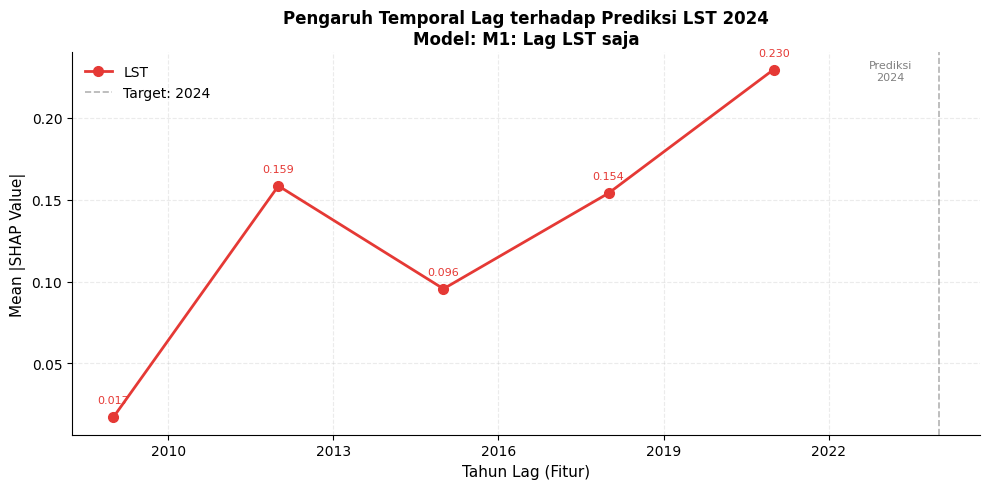

   [M1_LagLST] Lag paling berpengaruh: LST 2021 (mean |SHAP| = 0.2296)
💾 Disimpan: output/regression/shap_temporal_line_M2_LagLST_byCluster.png


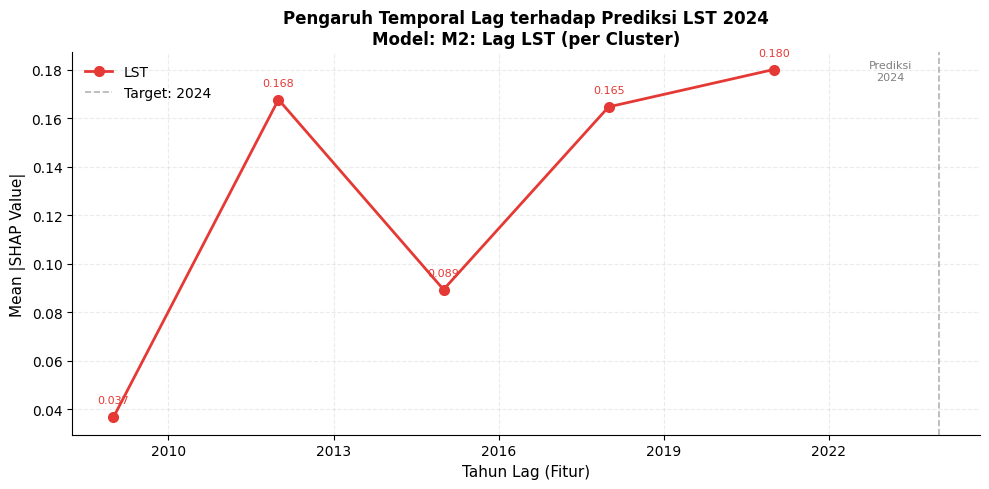

   [M2_LagLST_byCluster] Lag paling berpengaruh: LST 2021 (mean |SHAP| = 0.1801)
💾 Disimpan: output/regression/shap_temporal_line_M3_LagAll.png


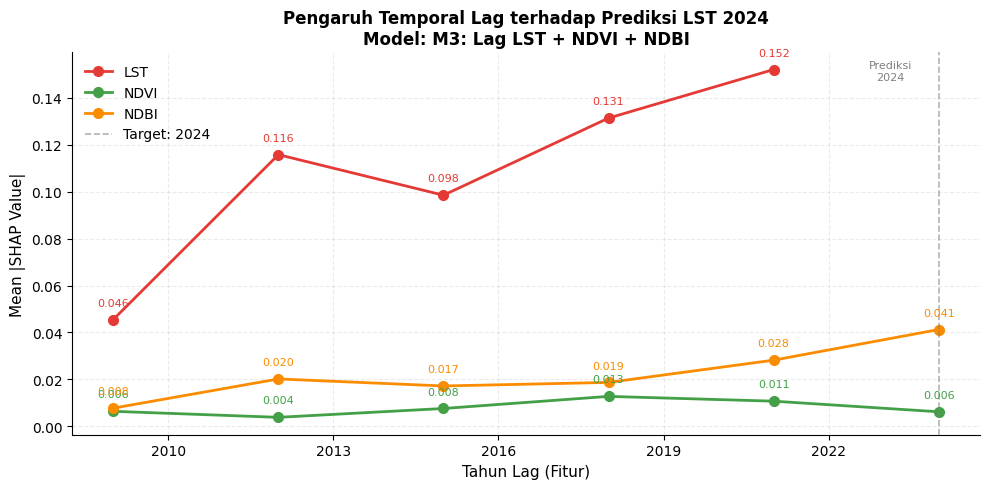

   [M3_LagAll] Lag paling berpengaruh: LST 2021 (mean |SHAP| = 0.1520)
💾 Disimpan: output/regression/shap_temporal_line_M4_LagAll_byCluster.png


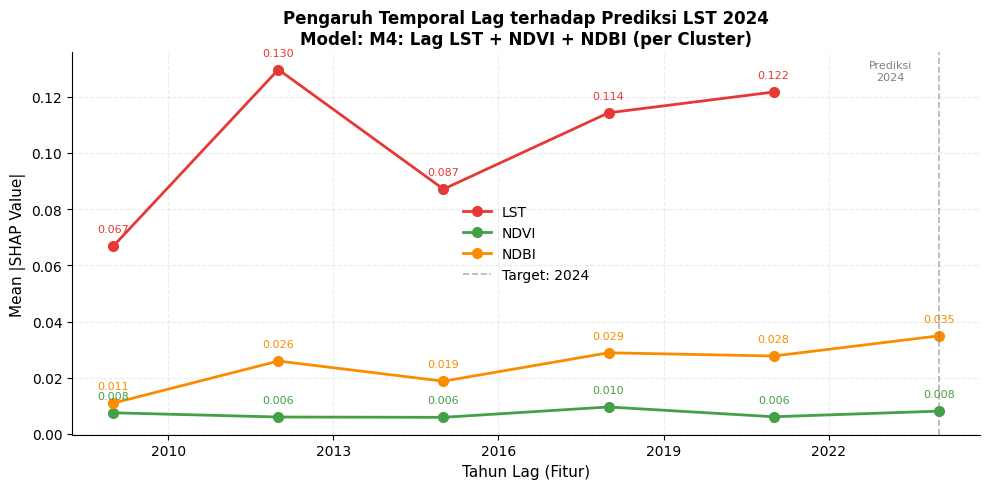

   [M4_LagAll_byCluster] Lag paling berpengaruh: LST 2012 (mean |SHAP| = 0.1297)

🗺️  [2/4] Lag Decay Heatmap (semua model × semua lag year)...
💾 Disimpan: output/regression/shap_lag_decay_heatmap_lst.png


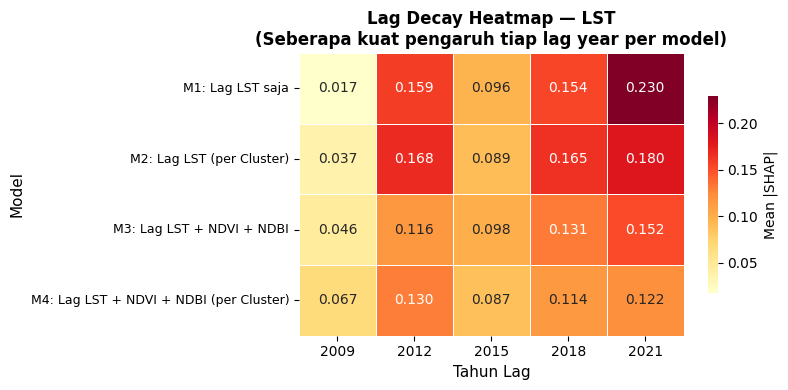

💾 Disimpan: output/regression/shap_lag_decay_heatmap_ndvi.png


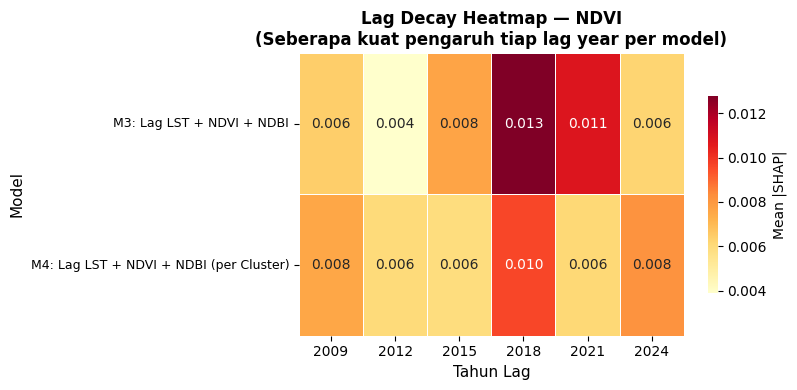


📊 [3/4] SHAP Time-Ordered Bar Plot (urutan waktu, bukan importance)...
💾 Disimpan: output/regression/shap_timeordered_bar_M1_LagLST.png


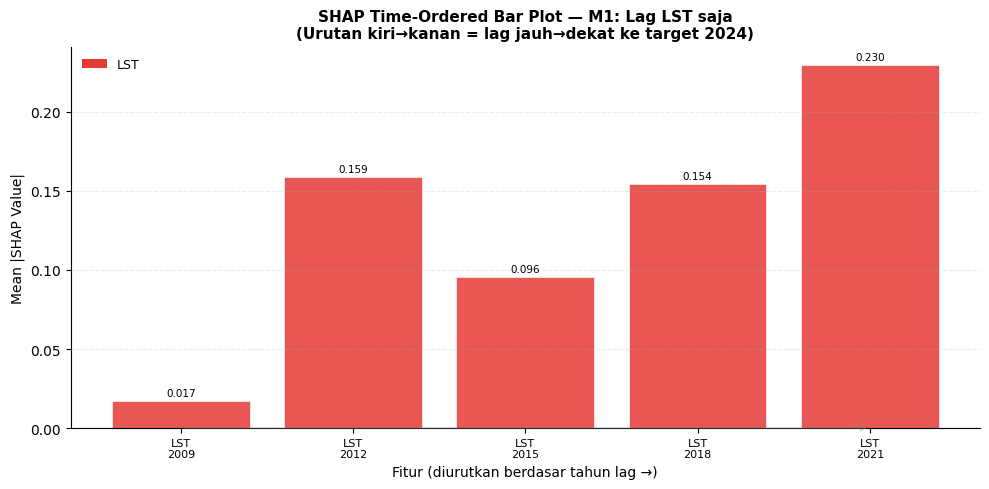

💾 Disimpan: output/regression/shap_timeordered_bar_M2_LagLST_byCluster.png


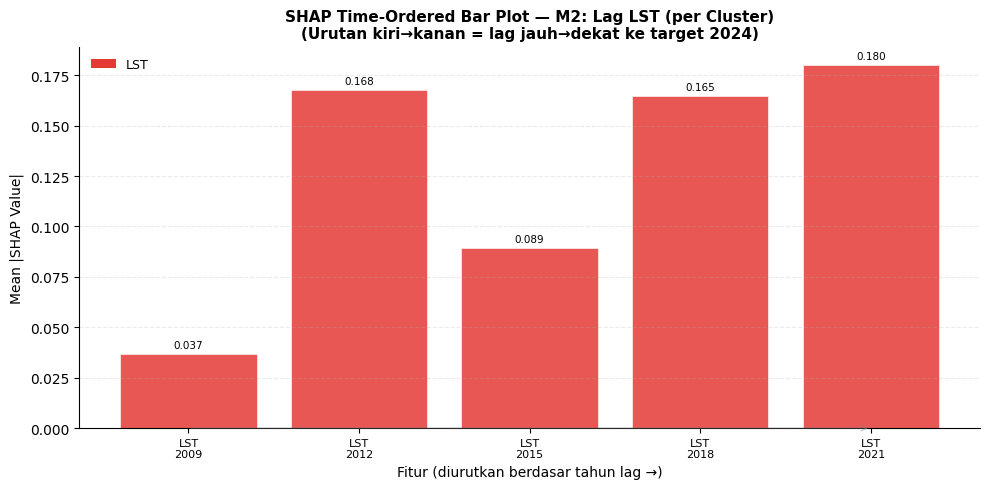

💾 Disimpan: output/regression/shap_timeordered_bar_M3_LagAll.png


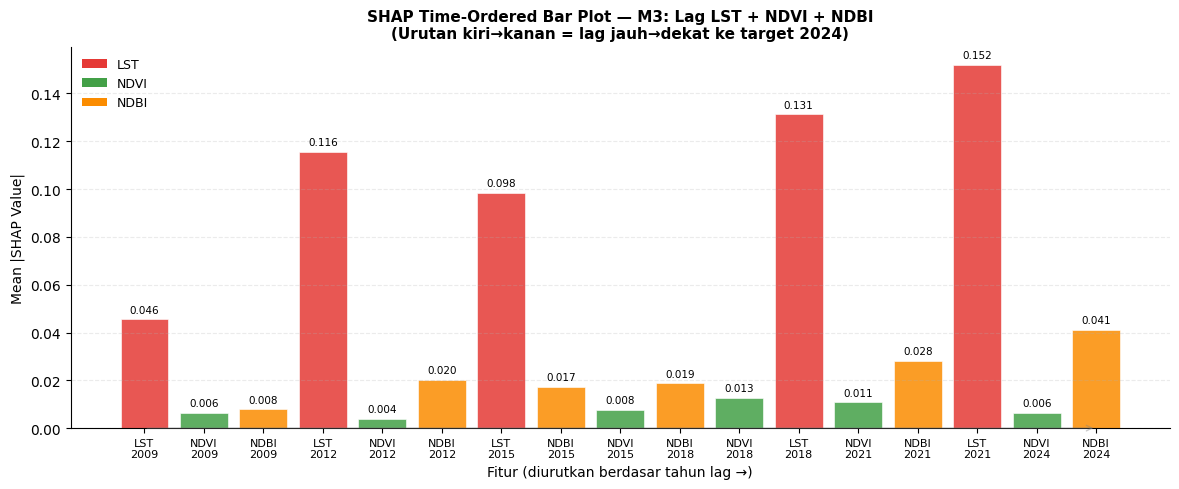

💾 Disimpan: output/regression/shap_timeordered_bar_M4_LagAll_byCluster.png


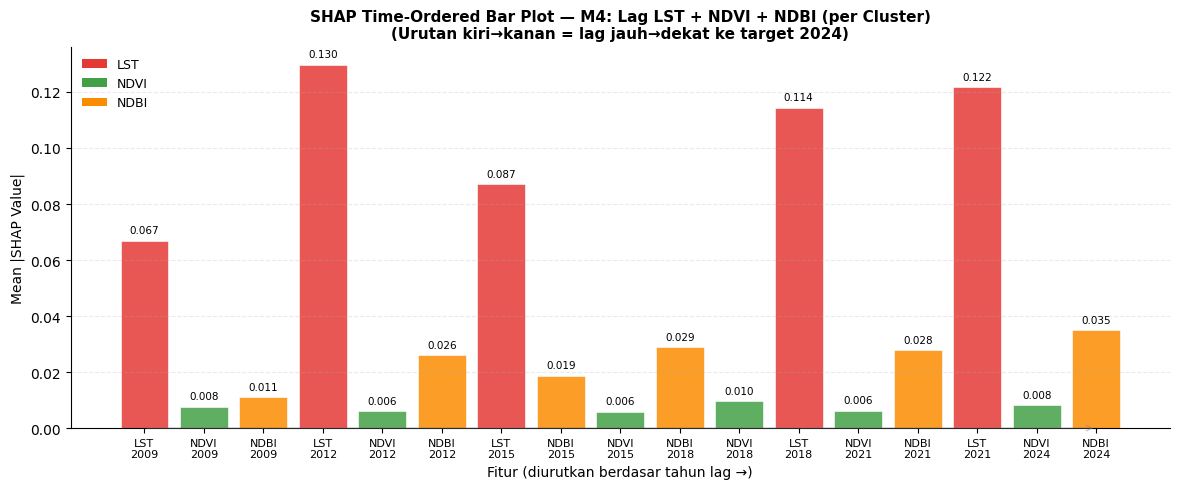


🔍 [4/4] SHAP Temporal per Cluster...
💾 Disimpan: output/regression/shap_temporal_cluster_M2_LagLST_byCluster.png


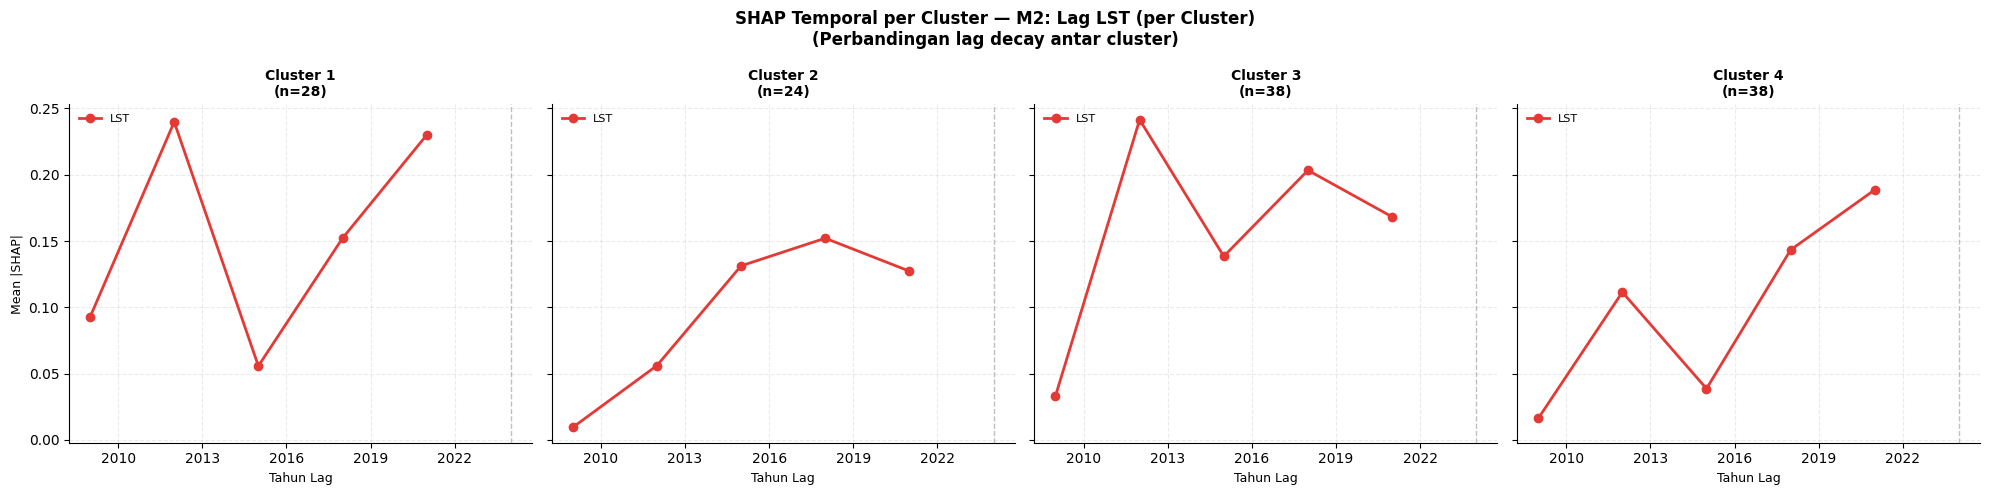

💾 Disimpan: output/regression/shap_temporal_cluster_M4_LagAll_byCluster.png


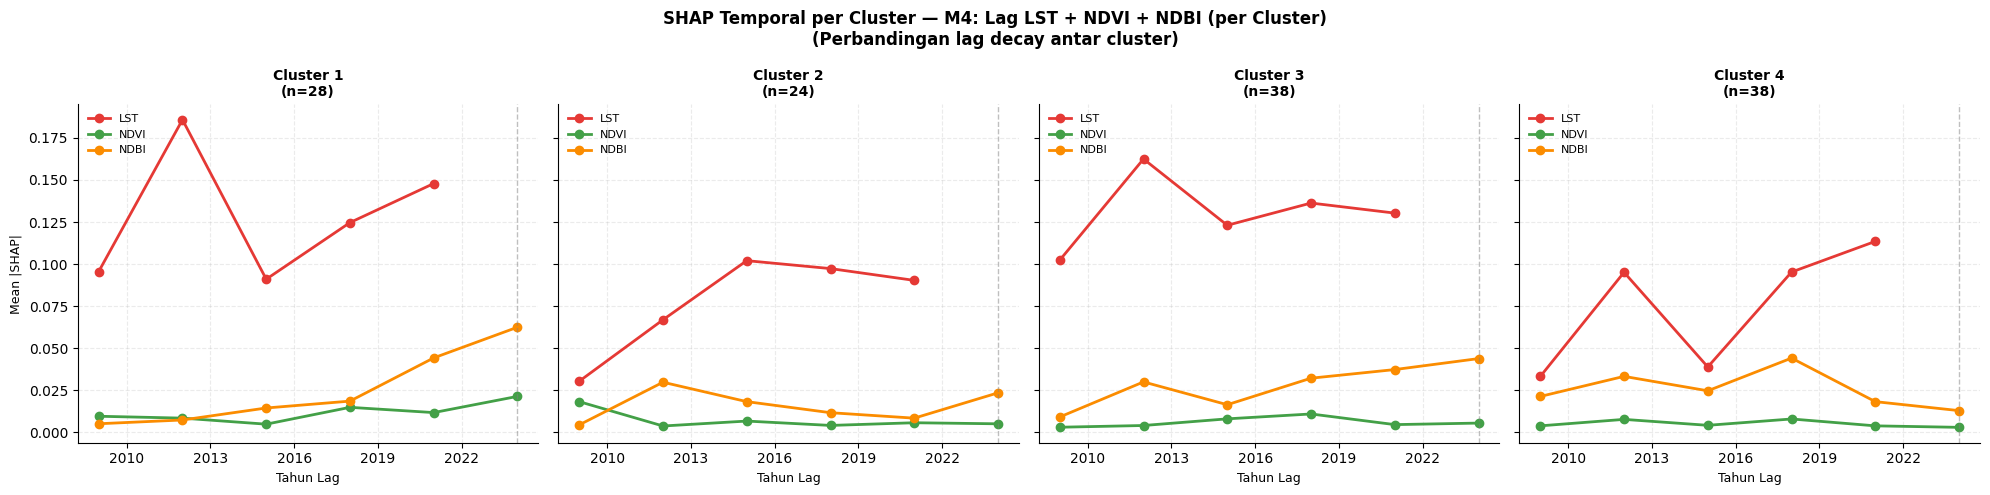


🎯 [Bonus] SHAP vs Nilai Fitur — model terbaik RF...
💾 Disimpan: output/regression/shap_feature_scatter_best_rf.png


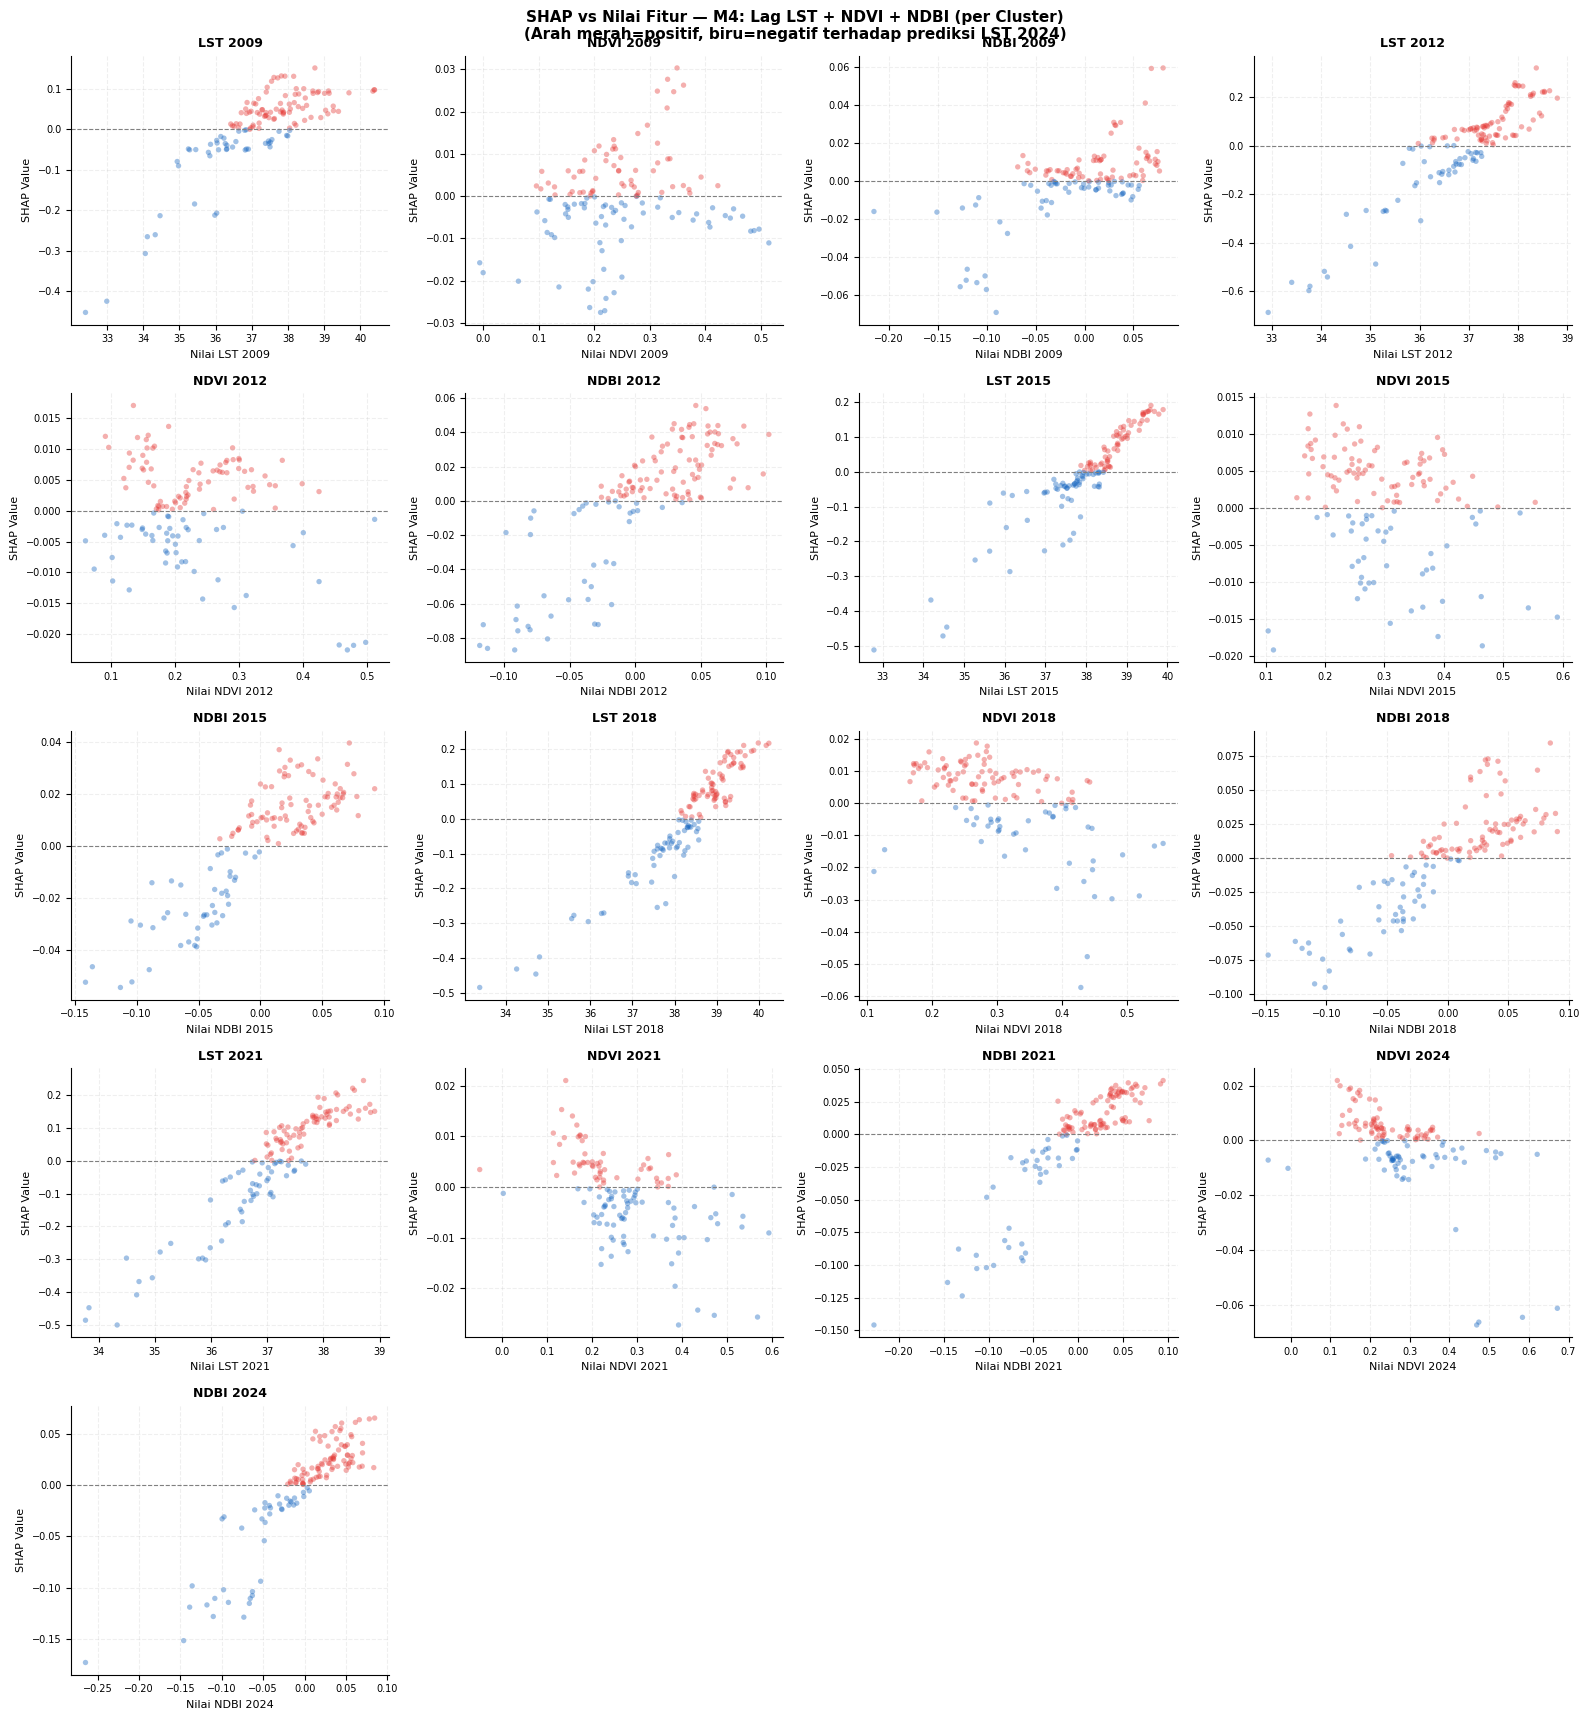


✅ Analisis SHAP Time-Aware selesai!

📋 Cara membaca hasilnya:
  1. shap_temporal_line_*.png  → Lihat apakah garis naik ke kanan
     Jika naik: lag terdekat (2021) paling berpengaruh = short memory
     Jika datar: semua lag sama penting = long memory effect

  2. shap_lag_decay_heatmap_*.png → Sel gelap = lag lebih penting
     Bandingkan antar model: M1 vs M3 dll.

  3. shap_timeordered_bar_*.png → Bar kiri=2009, kanan=2021
     Pola naik ke kanan = recency bias (normal untuk LST)

  4. shap_temporal_cluster_*.png → Apakah cluster perkotaan
     (UHI tinggi) punya decay berbeda vs cluster vegetasi?

  5. shap_feature_scatter_*.png → Titik merah: nilai fitur tinggi
     mendorong prediksi LST 2024 naik (korelasi positif)


In [114]:
"""
## 🕐 Sel 12b — Analisis SHAP Time-Aware (Time Series Interpretation)

Tujuan: menginterpretasikan SHAP values dengan memperhatikan dimensi waktu dari
fitur lag (lst_2009, lst_2012, ..., lst_2021). Visualisasi ini menjawab pertanyaan:
- Lag tahun mana yang paling berpengaruh terhadap prediksi LST 2024?
- Apakah pengaruh lag melemah semakin jauh ke masa lalu (lag decay)?
- Apakah pola ini konsisten di semua model dan cluster?
"""

import matplotlib.ticker as mticker  # re, numpy, pandas, matplotlib, seaborn, shap sudah di-import di Sel 3
# extract_year() dan get_var_type() didefinisikan di Sel 6 (Fungsi Helper)

# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 1: Temporal SHAP Line Plot
# Menunjukkan mean |SHAP| per lag year → tampak sebagai garis waktu
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_temporal(shap_values, feature_names, model_label,
                       target_year=2024, save_path=None):
    """
    Plot mean |SHAP| sebagai garis temporal per jenis variabel (LST, NDVI, NDBI).

    Parameter
    ---------
    shap_values    : np.ndarray, shape (n_samples, n_features)
    feature_names  : list[str]
    model_label    : str, judul plot
    target_year    : int, tahun prediksi (untuk sumbu x)
    save_path      : str atau None
    """
    # Hitung mean |SHAP| per fitur
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    # Bangun DataFrame: fitur → tahun + jenis variabel + shap
    records = []
    for feat, shap_val in zip(feature_names, mean_abs_shap):
        year = extract_year(feat)
        vtype = get_var_type(feat)
        if year is not None:
            records.append({'feature': feat, 'year': year,
                            'vtype': vtype, 'mean_abs_shap': shap_val})

    df_temp = pd.DataFrame(records).sort_values('year')

    if df_temp.empty:
        print(f"[PERINGATAN] Tidak ada fitur bertahun di model '{model_label}'")
        return

    # Warna per jenis variabel
    color_map = {'LST': '#e53935', 'NDVI': '#43a047',
                 'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}

    vtypes = df_temp['vtype'].unique()
    fig, ax = plt.subplots(figsize=(10, 5))

    for vtype in vtypes:
        sub = df_temp[df_temp['vtype'] == vtype].copy()
        color = color_map.get(vtype, '#9e9e9e')
        ax.plot(sub['year'], sub['mean_abs_shap'],
                marker='o', linewidth=2, markersize=7,
                color=color, label=vtype)
        # Anotasi nilai di tiap titik
        for _, row in sub.iterrows():
            ax.annotate(f"{row['mean_abs_shap']:.3f}",
                        xy=(row['year'], row['mean_abs_shap']),
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', fontsize=8, color=color)

    # Garis vertikal: target year
    ax.axvline(x=target_year, color='gray', linestyle='--',
               linewidth=1.2, alpha=0.6, label=f'Target: {target_year}')
    ax.annotate(f'Prediksi\n{target_year}',
                xy=(target_year, ax.get_ylim()[1]),
                xytext=(-35, -20), textcoords='offset points',
                fontsize=8, color='gray', ha='center')

    ax.set_xlabel('Tahun Lag (Fitur)', fontsize=11)
    ax.set_ylabel('Mean |SHAP Value|', fontsize=11)
    ax.set_title(f'Pengaruh Temporal Lag terhadap Prediksi LST {target_year}\n'
                 f'Model: {model_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, frameon=False)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
    ax.grid(axis='both', alpha=0.25, linestyle='--')
    sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return df_temp


# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 2: Lag Decay Heatmap
# Menampilkan mean |SHAP| per (model × lag year) sebagai heatmap
# Cocok untuk membandingkan semua model sekaligus
# ─────────────────────────────────────────────────────────────────────────────

def plot_lag_decay_heatmap(shap_store, model_configs, cfg_keys,
                           var_filter='LST', save_path=None):
    """
    Heatmap mean |SHAP| dengan baris = model, kolom = tahun lag.
    Memudahkan perbandingan lag decay antar model.

    Parameter
    ---------
    shap_store    : dict dari shap_store[(cfg_key, 'RF')]
    model_configs : dict MODEL_CONFIGS
    cfg_keys      : list urutan model
    var_filter    : 'LST', 'NDVI', 'NDBI', atau None (semua)
    save_path     : str atau None
    """
    all_years = set()
    rows_data = {}

    for cfg_key in cfg_keys:
        if (cfg_key, 'RF') not in shap_store:
            continue
        store = shap_store[(cfg_key, 'RF')]
        sv = store['sv']
        feats = store['feats']
        mean_abs = np.abs(sv).mean(axis=0)

        row = {}
        for feat, shap_val in zip(feats, mean_abs):
            year = extract_year(feat)
            vtype = get_var_type(feat)
            if year is None:
                continue
            if var_filter and vtype != var_filter:
                continue
            # Jika ada beberapa fitur per tahun (misal ndvi+ndbi), ambil max
            row[year] = max(row.get(year, 0), shap_val)
            all_years.add(year)

        label = model_configs[cfg_key]['label']
        rows_data[label] = row

    if not rows_data:
        print("[PERINGATAN] Tidak ada data untuk heatmap.")
        return

    sorted_years = sorted(all_years)
    df_heat = pd.DataFrame(rows_data).T.reindex(columns=sorted_years)

    fig, ax = plt.subplots(figsize=(max(8, len(sorted_years) * 1.2),
                                     max(4, len(rows_data) * 0.9)))

    sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Mean |SHAP|', 'shrink': 0.7},
                ax=ax)

    var_label = var_filter if var_filter else 'Semua Variabel'
    ax.set_title(f'Lag Decay Heatmap — {var_label}\n'
                 f'(Seberapa kuat pengaruh tiap lag year per model)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Tahun Lag', fontsize=11)
    ax.set_ylabel('Model', fontsize=11)
    ax.tick_params(axis='y', labelsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 3: SHAP Temporal Bar Plot dengan Urutan Waktu (bukan urutan importance)
# Ini pengganti shap_bar_rf yang sudah ada, tapi sumbu X diurutkan berdasar tahun
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_bar_by_time(shap_values, feature_names, model_label,
                          save_path=None):
    """
    Bar plot mean |SHAP| dengan fitur diurutkan berdasar tahun (kiri=lama, kanan=baru).
    Berbeda dari standard bar plot yang diurutkan berdasar importance.
    Ini memperlihatkan 'memory effect' secara visual.

    Parameter
    ---------
    shap_values   : np.ndarray, shape (n_samples, n_features)
    feature_names : list[str]
    model_label   : str
    save_path     : str atau None
    """
    mean_abs = np.abs(shap_values).mean(axis=0)
    color_map = {'LST': '#e53935', 'NDVI': '#43a047',
                 'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}

    records = []
    for feat, shap_val in zip(feature_names, mean_abs):
        year = extract_year(feat)
        vtype = get_var_type(feat)
        records.append({
            'feature': feat,
            'year': year if year else 0,
            'vtype': vtype,
            'mean_abs_shap': shap_val,
            'label': f"{vtype}\n{year}" if year else feat
        })

    df = pd.DataFrame(records).sort_values('year')
    colors = [color_map.get(r['vtype'], '#9e9e9e') for _, r in df.iterrows()]

    fig, ax = plt.subplots(figsize=(max(10, len(df) * 0.7), 5))
    bars = ax.bar(range(len(df)), df['mean_abs_shap'],
                  color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

    # Anotasi nilai di atas bar
    for i, (bar, val) in enumerate(zip(bars, df['mean_abs_shap'])):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['label'], fontsize=8, rotation=0)
    ax.set_xlabel('Fitur (diurutkan berdasar tahun lag →)', fontsize=10)
    ax.set_ylabel('Mean |SHAP Value|', fontsize=10)
    ax.set_title(f'SHAP Time-Ordered Bar Plot — {model_label}\n'
                 f'(Urutan kiri→kanan = lag jauh→dekat ke target 2024)',
                 fontsize=11, fontweight='bold')

    # Legend
    from matplotlib.patches import Patch
    used = list(dict.fromkeys(r['vtype'] for _, r in df.iterrows()))
    legend_handles = [Patch(facecolor=color_map.get(v, '#9e9e9e'), label=v)
                      for v in used]
    ax.legend(handles=legend_handles, fontsize=9, frameon=False, loc='upper left')

    # Panah tren (opsional: tandai lag terdekat vs terjauh)
    if len(df) >= 2:
        ax.annotate('', xy=(len(df) - 1, 0), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='gray',
                                   lw=1, alpha=0.4))

    ax.grid(axis='y', alpha=0.25, linestyle='--')
    sns.despine(ax=ax)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 4: SHAP Temporal per Cluster (untuk model split_by_cluster)
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_temporal_per_cluster(all_results, cfg_key, model_configs,
                                   clusters, target_year=2024,
                                   save_path=None):
    """
    Untuk model split_by_cluster (M2, M4): plot mean |SHAP| per tahun
    untuk setiap cluster dalam satu figure.
    Memperlihatkan apakah lag decay berbeda antar cluster (tipe lahan).

    Parameter
    ---------
    all_results   : dict all_results dari training
    cfg_key       : str, misal 'M2_LagLST_byCluster'
    model_configs : dict MODEL_CONFIGS
    clusters      : list cluster IDs
    target_year   : int
    save_path     : str atau None
    """
    res = all_results[(cfg_key, 'RF')]
    feats = res['features']
    cl_models = res['cluster_models']
    color_map = {'LST': '#e53935', 'NDVI': '#43a047',
                 'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}

    n_cl = len(clusters)
    fig, axes = plt.subplots(1, n_cl, figsize=(5 * n_cl, 5), sharey=True)
    if n_cl == 1:
        axes = [axes]

    fig.suptitle(f'SHAP Temporal per Cluster — {model_configs[cfg_key]["label"]}\n'
                 f'(Perbandingan lag decay antar cluster)',
                 fontsize=12, fontweight='bold')

    all_df = {}

    for ax, cl in zip(axes, clusters):
        m = cl_models[cl]['RF']
        X_te = res['cluster_X_test'][cl]

        # Hitung SHAP untuk cluster ini
        explainer = shap.TreeExplainer(m)
        sv_cl = explainer.shap_values(X_te)
        mean_abs_cl = np.abs(sv_cl).mean(axis=0)

        records = []
        for feat, shap_val in zip(feats, mean_abs_cl):
            year = extract_year(feat)
            vtype = get_var_type(feat)
            if year:
                records.append({'year': year, 'vtype': vtype,
                                'mean_abs_shap': shap_val})

        df_cl = pd.DataFrame(records).sort_values('year')
        all_df[cl] = df_cl

        for vtype in df_cl['vtype'].unique():
            sub = df_cl[df_cl['vtype'] == vtype]
            color = color_map.get(vtype, '#9e9e9e')
            ax.plot(sub['year'], sub['mean_abs_shap'],
                    marker='o', linewidth=2, markersize=6,
                    color=color, label=vtype)

        ax.axvline(x=target_year, color='gray', linestyle='--',
                   linewidth=1, alpha=0.5)
        n_te = len(X_te)
        ax.set_title(f'Cluster {int(cl)}\n(n={n_te})',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Tahun Lag', fontsize=9)
        if ax == axes[0]:
            ax.set_ylabel('Mean |SHAP|', fontsize=9)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
        ax.grid(alpha=0.25, linestyle='--')
        ax.legend(fontsize=8, frameon=False)
        sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return all_df


# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 5: Lag Correlation Matrix
# Tambahan: korelasi temporal antara SHAP fitur dan nilai fitur itu sendiri
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_feature_correlation(shap_values, feature_names, X_test,
                                  model_label, save_path=None):
    """
    Scatter plot SHAP value vs nilai fitur untuk setiap fitur bertahun.
    Memperlihatkan arah pengaruh: apakah LST tinggi di tahun X mendorong
    prediksi LST 2024 naik atau turun?

    Parameter
    ---------
    shap_values   : np.ndarray, shape (n_samples, n_features)
    feature_names : list[str]
    X_test        : np.ndarray, shape (n_samples, n_features)
    model_label   : str
    save_path     : str atau None
    """
    # Filter hanya fitur bertahun
    timed_feats = [(i, f) for i, f in enumerate(feature_names)
                   if extract_year(f) is not None]

    if not timed_feats:
        print("[PERINGATAN] Tidak ada fitur bertahun untuk scatter plot.")
        return

    n_feats = len(timed_feats)
    n_cols = min(4, n_feats)
    n_rows = int(np.ceil(n_feats / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 3.5 * n_rows))
    axes_flat = axes.flatten() if n_feats > 1 else [axes]

    fig.suptitle(f'SHAP vs Nilai Fitur — {model_label}\n'
                 f'(Arah merah=positif, biru=negatif terhadap prediksi LST 2024)',
                 fontsize=11, fontweight='bold')

    # Urutkan berdasar tahun
    timed_feats_sorted = sorted(timed_feats, key=lambda x: extract_year(x[1]))

    for ax, (feat_idx, feat_name) in zip(axes_flat, timed_feats_sorted):
        sv_col = shap_values[:, feat_idx]
        feat_vals = X_test[:, feat_idx]
        year = extract_year(feat_name)
        vtype = get_var_type(feat_name)

        # Warna titik berdasar arah SHAP (merah=positif, biru=negatif)
        colors_scatter = ['#e53935' if s > 0 else '#1565c0' for s in sv_col]

        ax.scatter(feat_vals, sv_col, c=colors_scatter,
                   alpha=0.4, s=15, edgecolors='none')
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.set_title(f'{vtype} {year}', fontsize=9, fontweight='bold')
        ax.set_xlabel(f'Nilai {vtype} {year}', fontsize=8)
        ax.set_ylabel('SHAP Value', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    # Sembunyikan panel kosong
    for ax in axes_flat[len(timed_feats_sorted):]:
        ax.set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# EKSEKUSI: Jalankan semua analisis SHAP time-aware
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('🕐 Memulai Analisis SHAP Time-Aware')
print('=' * 60)

# ── (1) Temporal SHAP Line Plot untuk setiap model ────────────────────────
print('\n📈 [1/4] Temporal SHAP Line Plot (per model)...')

for cfg_key in cfg_keys:
    if (cfg_key, 'RF') not in shap_store:
        continue
    store = shap_store[(cfg_key, 'RF')]
    model_lbl = MODEL_CONFIGS[cfg_key]['label']

    df_temp = plot_shap_temporal(
        shap_values=store['sv'],
        feature_names=store['feats'],
        model_label=model_lbl,
        target_year=TARGET_YEAR,
        save_path=OUTPUT_DIR + f'shap_temporal_line_{cfg_key}.png'
    )

    # Cetak ringkasan: lag mana yang paling dominan
    if df_temp is not None and not df_temp.empty:
        top_row = df_temp.loc[df_temp['mean_abs_shap'].idxmax()]
        print(f'   [{cfg_key}] Lag paling berpengaruh: '
              f'{top_row["vtype"]} {int(top_row["year"])} '
              f'(mean |SHAP| = {top_row["mean_abs_shap"]:.4f})')

# ── (2) Lag Decay Heatmap ─────────────────────────────────────────────────
print('\n🗺️  [2/4] Lag Decay Heatmap (semua model × semua lag year)...')

# Heatmap untuk fitur LST
plot_lag_decay_heatmap(
    shap_store=shap_store,
    model_configs=MODEL_CONFIGS,
    cfg_keys=cfg_keys,
    var_filter='LST',
    save_path=OUTPUT_DIR + 'shap_lag_decay_heatmap_lst.png'
)

# Heatmap untuk NDVI (jika ada di model M3/M4)
ndvi_cfg_keys = [k for k in cfg_keys
                 if any('ndvi' in f.lower() for f in MODEL_CONFIGS[k]['features'])]
if ndvi_cfg_keys:
    plot_lag_decay_heatmap(
        shap_store=shap_store,
        model_configs=MODEL_CONFIGS,
        cfg_keys=ndvi_cfg_keys,
        var_filter='NDVI',
        save_path=OUTPUT_DIR + 'shap_lag_decay_heatmap_ndvi.png'
    )

# ── (3) Time-Ordered Bar Plot ────────────────────────────────────────────
print('\n📊 [3/4] SHAP Time-Ordered Bar Plot (urutan waktu, bukan importance)...')

for cfg_key in cfg_keys:
    if (cfg_key, 'RF') not in shap_store:
        continue
    store = shap_store[(cfg_key, 'RF')]
    model_lbl = MODEL_CONFIGS[cfg_key]['label']

    plot_shap_bar_by_time(
        shap_values=store['sv'],
        feature_names=store['feats'],
        model_label=model_lbl,
        save_path=OUTPUT_DIR + f'shap_timeordered_bar_{cfg_key}.png'
    )

# ── (4) SHAP Temporal per Cluster (model split_by_cluster) ───────────────
print('\n🔍 [4/4] SHAP Temporal per Cluster...')

cluster_cfg_keys = [k for k, v in MODEL_CONFIGS.items() if v['split_by_cluster']]
for cfg_key in cluster_cfg_keys:
    plot_shap_temporal_per_cluster(
        all_results=all_results,
        cfg_key=cfg_key,
        model_configs=MODEL_CONFIGS,
        clusters=clusters,
        target_year=TARGET_YEAR,
        save_path=OUTPUT_DIR + f'shap_temporal_cluster_{cfg_key}.png'
    )

# ── (5) SHAP vs Nilai Fitur (scatter arah pengaruh) ──────────────────────
print('\n🎯 [Bonus] SHAP vs Nilai Fitur — model terbaik RF...')

best_store = shap_store[(best_cfg_key_rf, 'RF')]
X_te_best_arr = best_store['X']

plot_shap_feature_correlation(
    shap_values=best_store['sv'],
    feature_names=best_store['feats'],
    X_test=X_te_best_arr,
    model_label=MODEL_CONFIGS[best_cfg_key_rf]['label'],
    save_path=OUTPUT_DIR + 'shap_feature_scatter_best_rf.png'
)

print('\n' + '=' * 60)
print('✅ Analisis SHAP Time-Aware selesai!')
print('=' * 60)
print('\n📋 Cara membaca hasilnya:')
print('  1. shap_temporal_line_*.png  → Lihat apakah garis naik ke kanan')
print('     Jika naik: lag terdekat (2021) paling berpengaruh = short memory')
print('     Jika datar: semua lag sama penting = long memory effect')
print()
print('  2. shap_lag_decay_heatmap_*.png → Sel gelap = lag lebih penting')
print('     Bandingkan antar model: M1 vs M3 dll.')
print()
print('  3. shap_timeordered_bar_*.png → Bar kiri=2009, kanan=2021')
print('     Pola naik ke kanan = recency bias (normal untuk LST)')
print()
print('  4. shap_temporal_cluster_*.png → Apakah cluster perkotaan')
print('     (UHI tinggi) punya decay berbeda vs cluster vegetasi?')
print()
print('  5. shap_feature_scatter_*.png → Titik merah: nilai fitur tinggi')
print('     mendorong prediksi LST 2024 naik (korelasi positif)')

📚 ANALISIS SHAP SESUAI TIGA JURNAL REFERENSI

[A] Vector SHAP per Variabel — Choi et al. (2025)...
    → Agregasi semua lag per variabel menjadi 1 nilai

   Model: M1: Lag LST saja
variable  n_lags  vector_shap_mean  vector_shap_std  vector_shap_pct
     LST       5          0.654835           0.4981            100.0
💾 Disimpan: output/regression/shap_vector_M1_LagLST.png


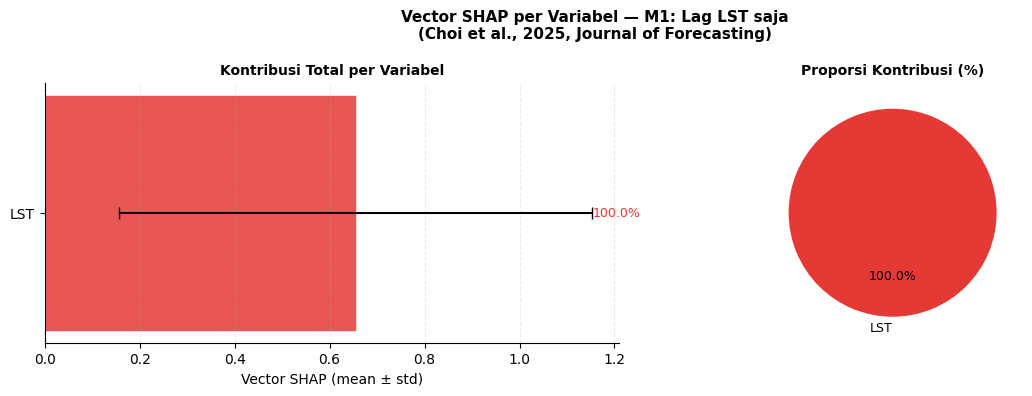


   Model: M2: Lag LST (per Cluster)
variable  n_lags  vector_shap_mean  vector_shap_std  vector_shap_pct
     LST       5          0.638666         0.514701            100.0
💾 Disimpan: output/regression/shap_vector_M2_LagLST_byCluster.png


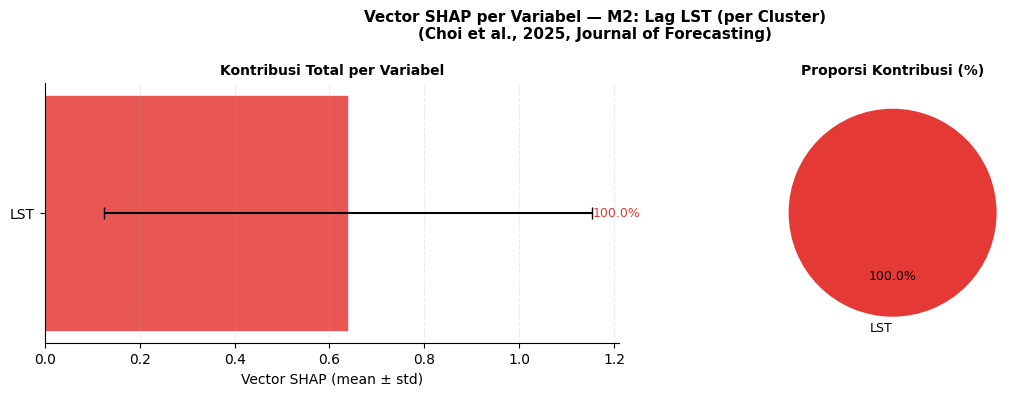


   Model: M3: Lag LST + NDVI + NDBI
variable  n_lags  vector_shap_mean  vector_shap_std  vector_shap_pct
     LST       5          0.542907         0.443042            74.98
    NDBI       6          0.133446         0.094994            18.43
    NDVI       6          0.047739         0.017142             6.59
💾 Disimpan: output/regression/shap_vector_M3_LagAll.png


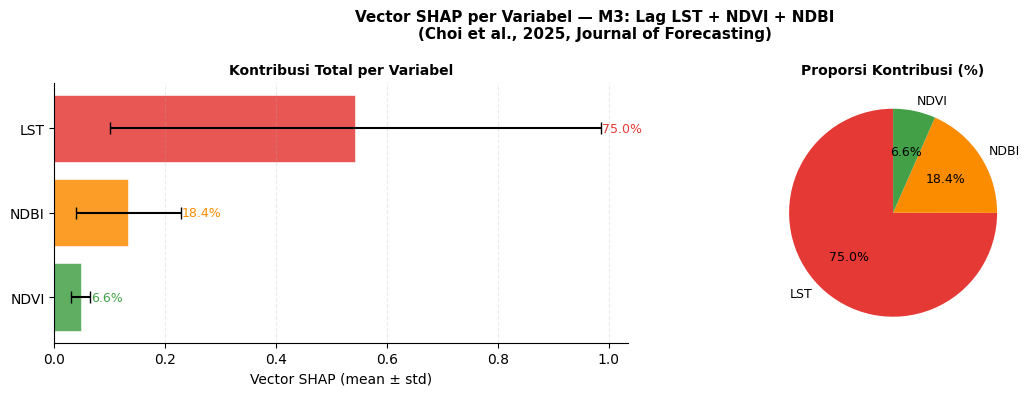


   Model: M4: Lag LST + NDVI + NDBI (per Cluster)
variable  n_lags  vector_shap_mean  vector_shap_std  vector_shap_pct
     LST       5          0.519514         0.440662            73.16
    NDBI       6          0.147245         0.097970            20.73
    NDVI       6          0.043370         0.025634             6.11
💾 Disimpan: output/regression/shap_vector_M4_LagAll_byCluster.png


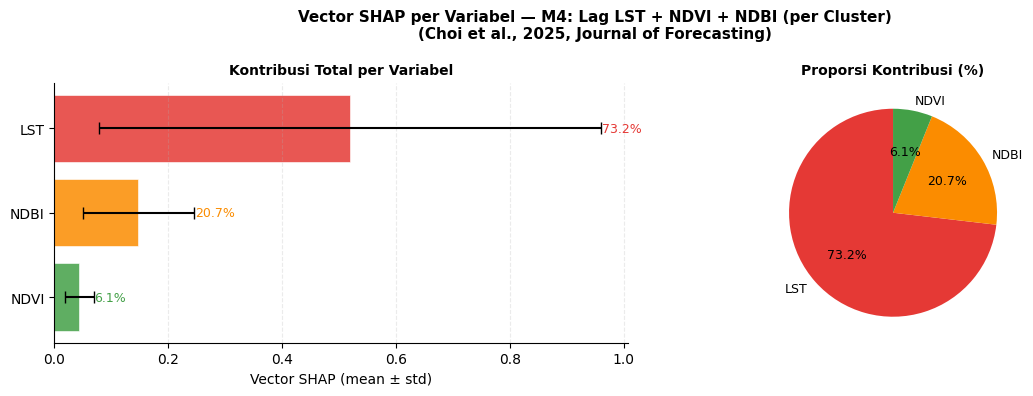


[B] SHAP Dependence Plot — Sun et al. (2025)...
    → Interaksi antar fitur temporal terungkap
💾 Disimpan: output/regression/shap_dependence_M4_LagAll_byCluster.png


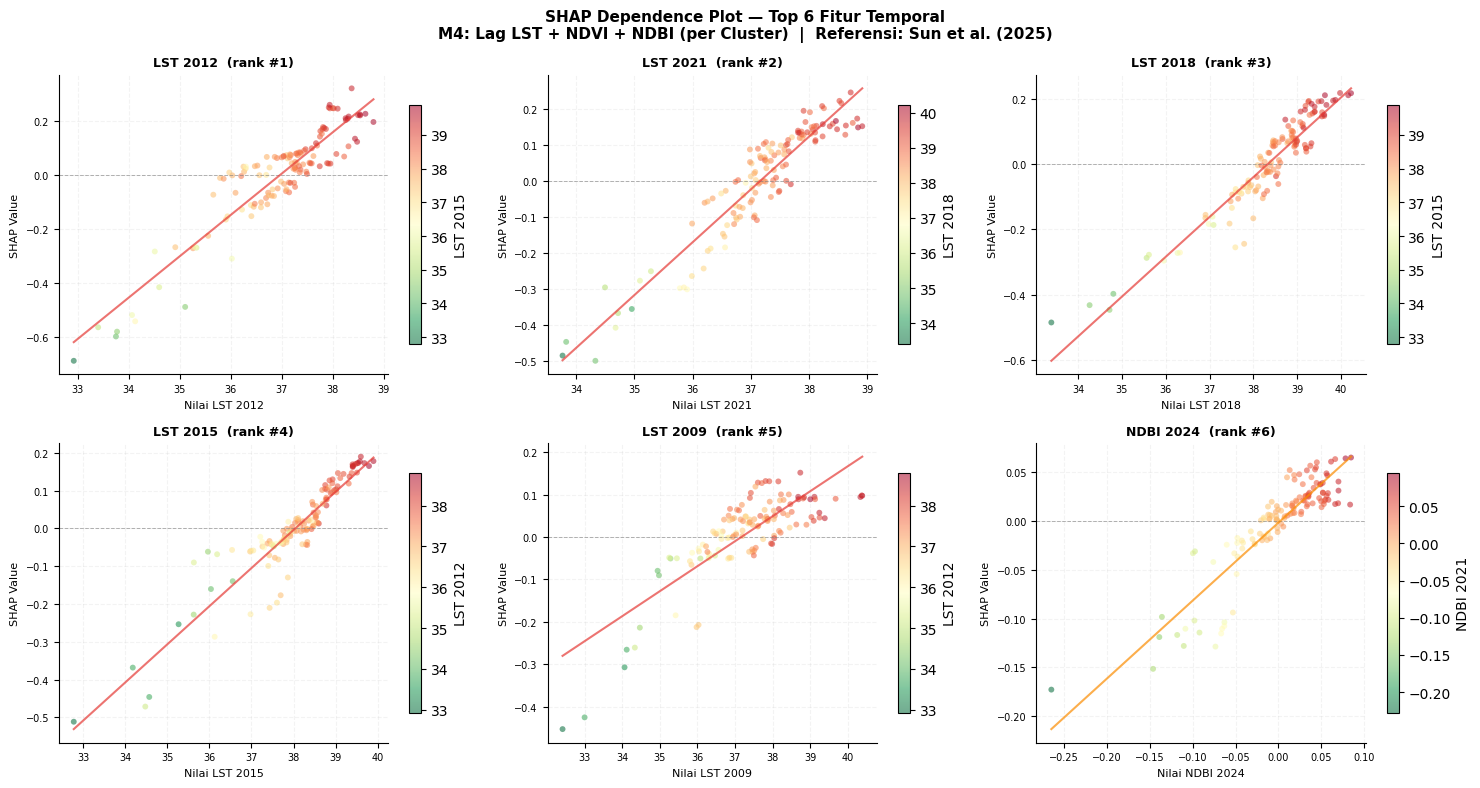


[C] SHAP Fidelity Test — Ozyegen et al. (2022)...
    → Validasi: apakah SHAP benar-benar mencerminkan kontribusi fitur?
💾 Disimpan: output/regression/shap_fidelity_M4_LagAll_byCluster.png


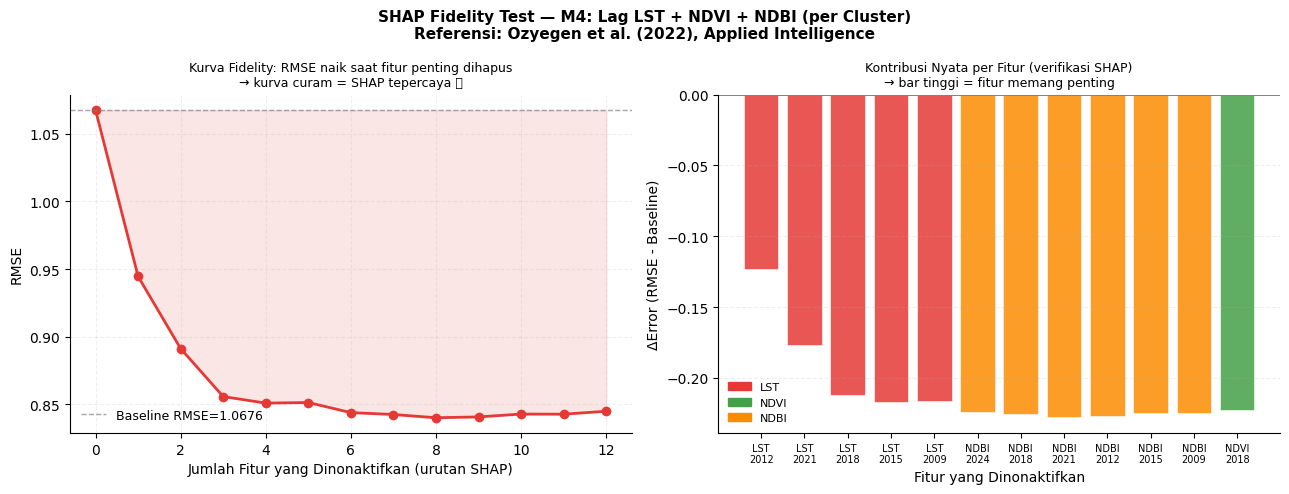


   Ringkasan Fidelity Test:
feature_removed  mean_abs_shap     rmse  delta_rmse
       Baseline            NaN 1.067616    0.000000
       lst_2012       0.129659 0.944472   -0.123145
       lst_2021       0.121657 0.891076   -0.176540
       lst_2018       0.114259 0.855578   -0.212038
       lst_2015       0.087104 0.850730   -0.216887
       lst_2009       0.066836 0.851180   -0.216437
       ndbi2024       0.034906 0.843704   -0.223912
       ndbi2018       0.028890 0.842301   -0.225315
       ndbi2021       0.027740 0.839904   -0.227712
       ndbi2012       0.025951 0.840524   -0.227092
       ndbi2015       0.018778 0.842630   -0.224986
       ndbi2009       0.010979 0.842539   -0.225078
       ndvi2018       0.009608 0.844723   -0.222893

   Korelasi Spearman (|SHAP| vs ΔError): r=0.734, p=0.0065
   ✅ SHAP faithfully mencerminkan kontribusi fitur (korelasi positif signifikan)

[D] Tabel Numerik Vector SHAP — Siap Dikutip di Skripsi...

═════════════════════════════════════════

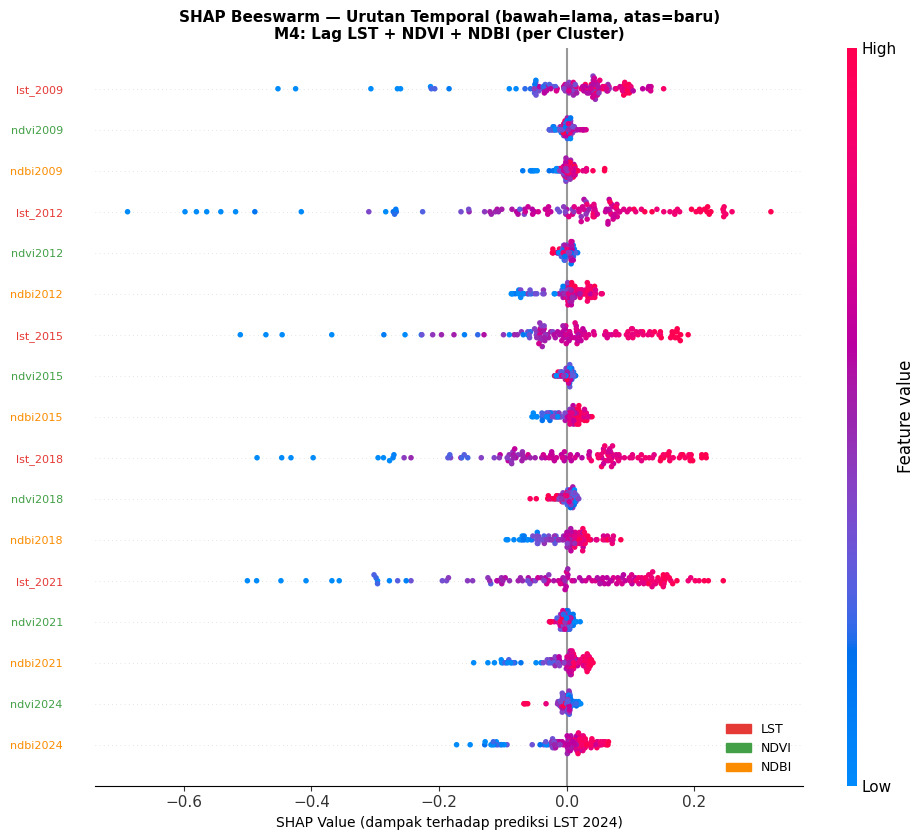


✅ Semua analisis SHAP sesuai jurnal referensi selesai!

📋 Output yang dihasilkan:
  [A] shap_vector_*.png           → Vector SHAP per variabel (Choi et al. 2025)
  [B] shap_dependence_*.png       → Dependence plot interaksi (Sun et al. 2025)
  [C] shap_fidelity_*.png         → Fidelity test validasi SHAP (Ozyegen 2022)
  [D] tabel_vector_shap_summary.csv → Tabel numerik siap dikutip
  [E] shap_beeswarm_temporal_*.png → Beeswarm urutan waktu

📖 Cara mengutip di skripsi:
  [A] "Mengikuti Choi et al. (2025), Vector SHAP dihitung sebagai agregasi
       kontribusi seluruh lag setiap variabel, menghasilkan satu nilai
       representatif per variabel (LST, NDVI, NDBI)."

  [B] "SHAP dependence plot digunakan untuk mengungkap interaksi non-linear
       antar variabel temporal, sesuai pendekatan Sun et al. (2025) pada
       pemodelan siklus ekonomi dengan variabel eksogen multivariat."

  [C] "Validasi fidelity SHAP dilakukan dengan metode perturbation test
       (Ozyegen et al., 2022): f

In [115]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║     SHAP TIME-AWARE ANALYSIS — SESUAI TIGA JURNAL REFERENSI                ║
║                                                                              ║
║  Jurnal 1: Choi et al. (2025) Journal of Forecasting DOI:10.1002/for.3220   ║
║            → Vector SHAP: agregasi SHAP per variabel (bukan per lag)         ║
║                                                                              ║
║  Jurnal 2: Sun et al. (2025) Technological Forecasting & Social Change       ║
║            → TreeSHAP global + lokal + dependence plot antar variabel        ║
║                                                                              ║
║  Jurnal 3: Ozyegen et al. (2022) Applied Intelligence DOI:10.1007/s10489    ║
║            → Fidelity test: validasi apakah SHAP benar-benar setia           ║
║              pada prediksi model (perturbation-based evaluation)              ║
║                                                                              ║
║  TAMBAHAN BARU vs kode sebelumnya:                                           ║
║  [A] compute_vector_shap()  — Choi et al. 2025                              ║
║  [B] plot_shap_dependence() — Sun et al. 2025                               ║
║  [C] shap_fidelity_test()   — Ozyegen et al. 2022                           ║
║  [D] export_shap_table()    — tabel numerik siap kutip di skripsi            ║
║  [E] plot_beeswarm_temporal() — beeswarm dengan urutan waktu                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

PETUNJUK PENGGUNAAN:
  Tempel sel ini SETELAH Sel 12 di notebook Anda.
  Pastikan variabel berikut sudah tersedia dari sel sebelumnya:
    - shap_store   : dict[(cfg_key, 'RF')] = {'sv', 'X', 'feats'}
    - all_results  : dict hasil training semua model
    - MODEL_CONFIGS, cfg_keys, clusters, best_cfg_key_rf
    - TARGET_YEAR, OUTPUT_DIR, CLUSTER_COL
"""

import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
# re, numpy, pandas, matplotlib, seaborn, shap, warnings sudah di-import di Sel 3
# extract_year(), get_var_type(), COLOR_VAR didefinisikan di Sel 6 (Fungsi Helper)


# ═════════════════════════════════════════════════════════════════════════════
# [A] VECTOR SHAP — Choi et al. (2025), Journal of Forecasting
#
#   Inovasi:
#   Standard SHAP → satu nilai per (lag × variabel) → sulit dibaca jika 15+ fitur
#   Vector SHAP   → satu nilai per variabel (agregasi seluruh lagnya)
#                → "seberapa besar kontribusi SEMUA lag LST terhadap prediksi?"
#
#   Cara kerja (sesuai paper Choi et al. 2025):
#     φ_vector(variabel_j) = Σ_{k: fitur dari variabel_j} |φ_k|
#   Di mana φ_k adalah SHAP value standar untuk lag ke-k dari variabel j.
#   Ini mengukur total kontribusi satu variabel (atas semua lag historisnya).
# ═════════════════════════════════════════════════════════════════════════════

def compute_vector_shap(shap_values: np.ndarray,
                        feature_names: list) -> pd.DataFrame:
    """
    Hitung Vector SHAP per variabel (Choi et al., 2025, J. of Forecasting).

    Aggregasi: φ_vector(var) = mean sample dari (sum |SHAP| semua lag var itu)
    Ini memberikan satu nilai skalar per variabel yang merangkum kontribusi
    seluruh horizon historisnya terhadap prediksi.

    Returns
    -------
    DataFrame dengan kolom: variable, n_lags, vector_shap_mean,
                             vector_shap_std, vector_shap_pct
    """
    # Kelompokkan indeks fitur per variabel
    var_groups: dict[str, list[int]] = {}
    for i, feat in enumerate(feature_names):
        vtype = get_var_type(feat)
        var_groups.setdefault(vtype, []).append(i)

    records = []
    for var, idxs in var_groups.items():
        # Untuk setiap sampel: jumlah |SHAP| dari semua lag variabel ini
        per_sample = np.abs(shap_values[:, idxs]).sum(axis=1)  # (n_samples,)
        records.append({
            'variable'         : var,
            'n_lags'           : len(idxs),
            'vector_shap_mean' : per_sample.mean(),
            'vector_shap_std'  : per_sample.std(),
        })

    df = pd.DataFrame(records).sort_values('vector_shap_mean', ascending=False)
    total = df['vector_shap_mean'].sum()
    df['vector_shap_pct'] = (df['vector_shap_mean'] / total * 100).round(2)
    df = df.reset_index(drop=True)
    return df


def plot_vector_shap(df_vector: pd.DataFrame, model_label: str,
                     save_path=None):
    """
    Bar chart Vector SHAP per variabel.
    Berbeda dari bar plot biasa yang menampilkan 15+ lag,
    ini ringkas: satu bar per variabel (LST, NDVI, NDBI).
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Vector SHAP per Variabel — {model_label}\n'
                 f'(Choi et al., 2025, Journal of Forecasting)',
                 fontsize=11, fontweight='bold')

    # Subplot kiri: bar chart magnitude
    colors = [COLOR_VAR.get(v, '#9e9e9e') for v in df_vector['variable']]
    axes[0].barh(df_vector['variable'][::-1],
                 df_vector['vector_shap_mean'][::-1],
                 xerr=df_vector['vector_shap_std'][::-1],
                 color=colors[::-1], alpha=0.85, capsize=4,
                 edgecolor='white', linewidth=0.5)
    axes[0].set_xlabel('Vector SHAP (mean ± std)', fontsize=10)
    axes[0].set_title('Kontribusi Total per Variabel', fontsize=10, fontweight='bold')
    for i, (_, row) in enumerate(df_vector.iloc[::-1].iterrows()):
        axes[0].text(row['vector_shap_mean'] + row['vector_shap_std'] + 0.001,
                     i, f'{row["vector_shap_pct"]:.1f}%',
                     va='center', fontsize=9,
                     color=COLOR_VAR.get(row['variable'], '#9e9e9e'))
    axes[0].grid(axis='x', alpha=0.25, linestyle='--')
    sns.despine(ax=axes[0])

    # Subplot kanan: pie chart proporsi
    wedge_colors = [COLOR_VAR.get(v, '#9e9e9e') for v in df_vector['variable']]
    axes[1].pie(df_vector['vector_shap_mean'],
                labels=df_vector['variable'],
                colors=wedge_colors,
                autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 9})
    axes[1].set_title('Proporsi Kontribusi (%)', fontsize=10, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()
    return df_vector


# ═════════════════════════════════════════════════════════════════════════════
# [B] SHAP DEPENDENCE PLOT — Sun et al. (2025), Tech. Forecasting & Social Change
#
#   Inovasi:
#   Sun et al. tidak hanya melihat kontribusi marginal satu variabel,
#   tapi juga mengungkap INTERAKSI antara dua variabel:
#   "Saat LST 2012 tinggi, apakah NDBI 2021 memperkuat atau melemahkan efeknya?"
#
#   SHAP dependence plot: scatter φ(fitur_X) vs nilai fitur_X,
#   dengan warna menunjukkan nilai fitur_interaksi Y.
#   Pola yang muncul mengindikasikan interaksi non-linear.
# ═════════════════════════════════════════════════════════════════════════════

def plot_shap_dependence_temporal(shap_values: np.ndarray,
                                  X_data: np.ndarray,
                                  feature_names: list,
                                  model_label: str,
                                  n_top: int = 6,
                                  save_path=None):
    """
    SHAP Dependence Plot untuk top-n fitur temporal (Sun et al., 2025).

    Untuk setiap fitur terpenting (berdasar mean |SHAP|), buat scatter:
      - sumbu X: nilai aktual fitur tersebut
      - sumbu Y: nilai SHAP fitur tersebut
      - warna:   nilai fitur interaksi otomatis (fitur dengan korelasi SHAP tertinggi)

    Ini mengungkap apakah efek suatu lag bersifat linear atau non-linear,
    dan apakah ada interaksi dengan lag/variabel lain.
    """
    mean_abs = np.abs(shap_values).mean(axis=0)
    # Ambil hanya fitur bertahun
    timed_idx = [(i, f) for i, f in enumerate(feature_names)
                 if extract_year(f) is not None]
    timed_idx_sorted = sorted(timed_idx,
                               key=lambda x: mean_abs[x[0]], reverse=True)
    top_feats = timed_idx_sorted[:n_top]

    n_cols = 3
    n_rows = int(np.ceil(len(top_feats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows))
    axes_flat = axes.flatten() if len(top_feats) > 1 else [axes]

    fig.suptitle(f'SHAP Dependence Plot — Top {n_top} Fitur Temporal\n'
                 f'{model_label}  |  Referensi: Sun et al. (2025)',
                 fontsize=11, fontweight='bold')

    for ax, (feat_idx, feat_name) in zip(axes_flat, top_feats):
        sv_col = shap_values[:, feat_idx]      # SHAP values fitur ini
        feat_vals = X_data[:, feat_idx]        # nilai aktual fitur ini
        year  = extract_year(feat_name)
        vtype = get_var_type(feat_name)

        # Temukan fitur interaksi otomatis: fitur lain yang korelasinya
        # tertinggi dengan shap_values kolom ini (metode Sun et al.)
        corr_with_others = []
        for j in range(shap_values.shape[1]):
            if j == feat_idx:
                continue
            r, _ = spearmanr(X_data[:, j], sv_col)
            corr_with_others.append((j, abs(r)))
        best_interact_idx = max(corr_with_others, key=lambda x: x[1])[0]
        interact_vals = X_data[:, best_interact_idx]
        interact_name = feature_names[best_interact_idx]

        sc = ax.scatter(feat_vals, sv_col,
                        c=interact_vals, cmap='RdYlGn_r',
                        alpha=0.55, s=18, edgecolors='none')
        plt.colorbar(sc, ax=ax,
                     label=f'{get_var_type(interact_name)} {extract_year(interact_name) or ""}',
                     shrink=0.8)
        ax.axhline(0, color='gray', linewidth=0.7, linestyle='--', alpha=0.6)

        # Trendline
        z = np.polyfit(feat_vals, sv_col, 1)
        p = np.poly1d(z)
        xsort = np.sort(feat_vals)
        ax.plot(xsort, p(xsort), color=COLOR_VAR.get(vtype, '#888'),
                linewidth=1.5, linestyle='-', alpha=0.7)

        ax.set_title(f'{vtype} {year}  (rank #{timed_idx_sorted.index((feat_idx, feat_name))+1})',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel(f'Nilai {vtype} {year}', fontsize=8)
        ax.set_ylabel('SHAP Value', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.15, linestyle='--')
        sns.despine(ax=ax)

    for ax in axes_flat[len(top_feats):]:
        ax.set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ═════════════════════════════════════════════════════════════════════════════
# [C] FIDELITY TEST — Ozyegen et al. (2022), Applied Intelligence
#
#   Inovasi:
#   Ozyegen et al. mempertanyakan: "SHAP mengklaim fitur X berkontribusi besar,
#   tapi apakah benar demikian? Bagaimana jika kita menghapus fitur itu?"
#
#   Metode (adaptasi AOPCR dari paper):
#   1. Urutkan fitur dari SHAP terbesar ke terkecil
#   2. Satu per satu, matikan (zero-out) fitur tersebut
#   3. Ukur perubahan error prediksi setiap kali penghapusan
#   4. Jika SHAP akurat: menghapus fitur ber-SHAP tinggi harus menaikkan error lebih besar
#
#   Interpretasi:
#   - Kurva yang turun tajam = SHAP setia (faithfully) menjelaskan model
#   - Kurva yang datar = SHAP tidak benar-benar mencerminkan kontribusi fitur
# ═════════════════════════════════════════════════════════════════════════════

def shap_fidelity_test(model, shap_values: np.ndarray,
                       X_test: np.ndarray, y_test: np.ndarray,
                       feature_names: list, model_label: str,
                       n_steps: int = None, save_path=None) -> pd.DataFrame:
    """
    Perturbation-based Fidelity Test untuk SHAP (Ozyegen et al., 2022).

    Prosedur:
      1. Prediksi baseline → hitung RMSE
      2. Matikan fitur ber-SHAP tertinggi (set ke mean) satu per satu
      3. Plot RMSE sebagai fungsi jumlah fitur yang dimatikan
      4. Kurva curam = SHAP faithfully menjelaskan model ✅

    Returns
    -------
    DataFrame ringkasan: fitur yang dimatikan, urutan SHAP, delta RMSE
    """
    from sklearn.metrics import mean_squared_error

    # Urutkan fitur berdasar mean |SHAP| descending
    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_order = np.argsort(mean_abs)[::-1]   # indeks dari paling penting

    if n_steps is None:
        n_steps = min(len(feature_names), 15)  # maksimal 15 langkah

    # Baseline RMSE (tanpa penghapusan fitur)
    y_pred_base = model.predict(X_test)
    rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

    # Iteratif matikan fitur
    X_perturbed = X_test.copy()
    feature_means = X_test.mean(axis=0)

    records = [{'step': 0, 'n_removed': 0,
                'feature_removed': 'Baseline',
                'rmse': rmse_base, 'delta_rmse': 0.0,
                'mean_abs_shap': np.nan}]

    for step in range(1, n_steps + 1):
        feat_idx  = shap_order[step - 1]
        feat_name = feature_names[feat_idx]

        # Set fitur ini ke mean (neutralize)
        X_perturbed[:, feat_idx] = feature_means[feat_idx]
        y_pred_new = model.predict(X_perturbed)
        rmse_new   = np.sqrt(mean_squared_error(y_test, y_pred_new))

        records.append({
            'step'           : step,
            'n_removed'      : step,
            'feature_removed': feat_name,
            'rmse'           : rmse_new,
            'delta_rmse'     : rmse_new - rmse_base,
            'mean_abs_shap'  : mean_abs[feat_idx],
        })

    df_fid = pd.DataFrame(records)

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'SHAP Fidelity Test — {model_label}\n'
                 f'Referensi: Ozyegen et al. (2022), Applied Intelligence',
                 fontsize=11, fontweight='bold')

    # Kiri: RMSE vs jumlah fitur dimatikan
    axes[0].plot(df_fid['n_removed'], df_fid['rmse'],
                 marker='o', color='#e53935', linewidth=2, markersize=6)
    axes[0].axhline(rmse_base, color='gray', linestyle='--',
                    linewidth=1, alpha=0.7, label=f'Baseline RMSE={rmse_base:.4f}')
    axes[0].fill_between(df_fid['n_removed'],
                          rmse_base, df_fid['rmse'],
                          alpha=0.12, color='#e53935')
    axes[0].set_xlabel('Jumlah Fitur yang Dinonaktifkan (urutan SHAP)', fontsize=10)
    axes[0].set_ylabel('RMSE', fontsize=10)
    axes[0].set_title('Kurva Fidelity: RMSE naik saat fitur penting dihapus\n'
                       '→ kurva curam = SHAP tepercaya ✅', fontsize=9)
    axes[0].legend(fontsize=9, frameon=False)
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    axes[0].grid(alpha=0.2, linestyle='--')
    sns.despine(ax=axes[0])

    # Kanan: Delta RMSE per fitur (bar chart)
    df_plot = df_fid[df_fid['step'] > 0].copy()
    bar_colors = [COLOR_VAR.get(get_var_type(f), '#9e9e9e')
                  for f in df_plot['feature_removed']]
    feat_labels = [f"{get_var_type(f)}\n{extract_year(f) or ''}"
                   for f in df_plot['feature_removed']]

    axes[1].bar(range(len(df_plot)), df_plot['delta_rmse'],
                color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    axes[1].axhline(0, color='gray', linewidth=0.7)
    axes[1].set_xticks(range(len(df_plot)))
    axes[1].set_xticklabels(feat_labels, fontsize=7, rotation=0)
    axes[1].set_xlabel('Fitur yang Dinonaktifkan', fontsize=10)
    axes[1].set_ylabel('ΔError (RMSE - Baseline)', fontsize=10)
    axes[1].set_title('Kontribusi Nyata per Fitur (verifikasi SHAP)\n'
                       '→ bar tinggi = fitur memang penting', fontsize=9)

    # Legend warna
    handles = [mpatches.Patch(color=COLOR_VAR[v], label=v)
               for v in ['LST', 'NDVI', 'NDBI'] if v in COLOR_VAR]
    axes[1].legend(handles=handles, fontsize=8, frameon=False)
    axes[1].grid(axis='y', alpha=0.2, linestyle='--')
    sns.despine(ax=axes[1])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return df_fid


# ═════════════════════════════════════════════════════════════════════════════
# [D] TABEL NUMERIK VECTOR SHAP — Siap Dikutip di Skripsi
#
#   Menghasilkan tabel ringkasan yang bisa langsung masuk ke bab metodologi
#   atau hasil, sesuai format tabel yang umum di ketiga jurnal referensi.
# ═════════════════════════════════════════════════════════════════════════════

def export_shap_summary_table(shap_store: dict,
                               model_configs: dict,
                               cfg_keys: list,
                               feature_names_ref: list,
                               save_path_csv=None,
                               save_path_print=True) -> pd.DataFrame:
    """
    Buat tabel numerik lengkap: per model × per variabel.
    Berisi: Vector SHAP, mean |SHAP| lag terkuat, ranking, % kontribusi.
    """
    rows = []
    for cfg_key in cfg_keys:
        if (cfg_key, 'RF') not in shap_store:
            continue
        store   = shap_store[(cfg_key, 'RF')]
        sv      = store['sv']
        feats   = store['feats']
        label   = model_configs[cfg_key]['label']

        df_vec = compute_vector_shap(sv, feats)

        # Tambahkan: lag terkuat untuk setiap variabel
        for _, row in df_vec.iterrows():
            # Cari lag dengan SHAP tertinggi dalam variabel ini
            var_feat_idxs = [(i, f) for i, f in enumerate(feats)
                             if get_var_type(f) == row['variable']]
            if var_feat_idxs:
                mean_abs = np.abs(sv).mean(axis=0)
                best_idx = max(var_feat_idxs, key=lambda x: mean_abs[x[0]])
                best_year = extract_year(best_idx[1])
                best_shap = mean_abs[best_idx[0]]
            else:
                best_year, best_shap = None, None

            rows.append({
                'Model'             : label,
                'Variabel'          : row['variable'],
                'Jumlah Lag'        : row['n_lags'],
                'Vector SHAP (mean)': round(row['vector_shap_mean'], 5),
                'Vector SHAP (std)' : round(row['vector_shap_std'], 5),
                'Kontribusi (%)'    : round(row['vector_shap_pct'], 2),
                'Lag Terkuat'       : best_year,
                'SHAP Lag Terkuat'  : round(best_shap, 5) if best_shap else None,
            })

    df_table = pd.DataFrame(rows)

    if save_path_print:
        print('\n' + '═' * 90)
        print('  TABEL VECTOR SHAP — SIAP DIKUTIP DI SKRIPSI')
        print('  Referensi: Choi et al. (2025), Journal of Forecasting')
        print('═' * 90)
        print(df_table.to_string(index=False))
        print('═' * 90)

    if save_path_csv:
        df_table.to_csv(save_path_csv, index=False)
        print(f'💾 Tabel disimpan: {save_path_csv}')

    return df_table


# ═════════════════════════════════════════════════════════════════════════════
# [E] BEESWARM PLOT TEMPORAL — Ordered by Year, not Importance
#
#   Gap dari kode lama: beeswarm standard mengurutkan fitur by importance.
#   Versi ini mengurutkan fitur berdasar TAHUN (temporal order),
#   sehingga sumbu Y menjadi timeline.
# ═════════════════════════════════════════════════════════════════════════════

def plot_beeswarm_temporal(shap_values: np.ndarray,
                           X_data: np.ndarray,
                           feature_names: list,
                           model_label: str,
                           save_path=None):
    """
    Beeswarm/summary plot SHAP dengan fitur diurutkan berdasar TAHUN,
    bukan berdasar importance (berbeda dari shap.summary_plot default).

    Urutan dari bawah ke atas = lag terjauh → lag terdekat ke target.
    """
    # Sort fitur berdasar tahun ascending (paling lama di bawah)
    timed = [(i, f) for i, f in enumerate(feature_names)
             if extract_year(f) is not None]
    non_timed = [(i, f) for i, f in enumerate(feature_names)
                 if extract_year(f) is None]

    # Urutkan: non-timed dulu (paling bawah), lalu timed ascending year
    timed_sorted = sorted(timed, key=lambda x: extract_year(x[1]))
    ordered = non_timed + timed_sorted

    ordered_idx   = [x[0] for x in ordered]
    ordered_names = [x[1] for x in ordered]

    sv_ordered = shap_values[:, ordered_idx]
    X_ordered  = X_data[:, ordered_idx]

    # Format label: tambah tahun dan warna berdasar vtype
    label_colors = [COLOR_VAR.get(get_var_type(f), '#9e9e9e')
                    for f in ordered_names]

    fig, ax = plt.subplots(figsize=(10, max(6, len(ordered_names) * 0.5)))
    plt.sca(ax)

    shap.summary_plot(
        sv_ordered,
        X_ordered,
        feature_names=ordered_names,
        show=False,
        plot_size=None,
        max_display=len(ordered_names),
        sort=False,   # ← kritis: jangan re-sort by importance
    )

    # Warnai tick label sesuai vtype
    yticks = ax.get_yticklabels()
    for tick, color in zip(yticks, label_colors[::-1]):  # reversed karena plt arah bawah-atas
        tick.set_color(color)
        tick.set_fontsize(8)

    ax.set_title(f'SHAP Beeswarm — Urutan Temporal (bawah=lama, atas=baru)\n'
                 f'{model_label}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('SHAP Value (dampak terhadap prediksi LST 2024)', fontsize=10)

    # Tambah legend warna variabel
    handles = [mpatches.Patch(color=COLOR_VAR[v], label=v)
               for v in ['LST', 'NDVI', 'NDBI']]
    ax.legend(handles=handles, loc='lower right', fontsize=9, frameon=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ═════════════════════════════════════════════════════════════════════════════
# EKSEKUSI UTAMA — Jalankan semua fungsi baru
# ═════════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('📚 ANALISIS SHAP SESUAI TIGA JURNAL REFERENSI')
print('=' * 70)

# ── Ambil data model terbaik RF ───────────────────────────────────────────
best_store  = shap_store[(best_cfg_key_rf, 'RF')]
sv_best     = best_store['sv']
X_best      = best_store['X']
feats_best  = best_store['feats']
model_best  = all_results[(best_cfg_key_rf, 'RF')]['model_obj']
y_test_best = all_results[(best_cfg_key_rf, 'RF')]['y_test']
label_best  = MODEL_CONFIGS[best_cfg_key_rf]['label']

# ── [A] VECTOR SHAP — Choi et al. (2025) ─────────────────────────────────
print('\n[A] Vector SHAP per Variabel — Choi et al. (2025)...')
print('    → Agregasi semua lag per variabel menjadi 1 nilai')

for cfg_key in cfg_keys:
    if (cfg_key, 'RF') not in shap_store:
        continue
    store = shap_store[(cfg_key, 'RF')]
    lbl   = MODEL_CONFIGS[cfg_key]['label']

    df_vec = compute_vector_shap(store['sv'], store['feats'])
    print(f'\n   Model: {lbl}')
    print(df_vec.to_string(index=False))

    plot_vector_shap(
        df_vec,
        model_label=lbl,
        save_path=OUTPUT_DIR + f'shap_vector_{cfg_key}.png'
    )

# ── [B] SHAP DEPENDENCE PLOT — Sun et al. (2025) ─────────────────────────
print('\n[B] SHAP Dependence Plot — Sun et al. (2025)...')
print('    → Interaksi antar fitur temporal terungkap')

plot_shap_dependence_temporal(
    shap_values=sv_best,
    X_data=X_best,
    feature_names=feats_best,
    model_label=label_best,
    n_top=6,
    save_path=OUTPUT_DIR + f'shap_dependence_{best_cfg_key_rf}.png'
)

# ── [C] FIDELITY TEST — Ozyegen et al. (2022) ────────────────────────────
print('\n[C] SHAP Fidelity Test — Ozyegen et al. (2022)...')
print('    → Validasi: apakah SHAP benar-benar mencerminkan kontribusi fitur?')

df_fidelity = shap_fidelity_test(
    model=model_best,
    shap_values=sv_best,
    X_test=X_best,
    y_test=y_test_best,
    feature_names=feats_best,
    model_label=label_best,
    n_steps=min(12, len(feats_best)),
    save_path=OUTPUT_DIR + f'shap_fidelity_{best_cfg_key_rf}.png'
)

print('\n   Ringkasan Fidelity Test:')
print(df_fidelity[['feature_removed', 'mean_abs_shap',
                    'rmse', 'delta_rmse']].to_string(index=False))

# Cek apakah korelasi SHAP magnitude dengan delta RMSE positif
# (sesuai teori Ozyegen: fitur ber-SHAP tinggi seharusnya punya delta RMSE tinggi)
df_fid_nz = df_fidelity[df_fidelity['step'] > 0].dropna()
if len(df_fid_nz) > 3:
    r_corr, p_corr = spearmanr(df_fid_nz['mean_abs_shap'], df_fid_nz['delta_rmse'])
    print(f'\n   Korelasi Spearman (|SHAP| vs ΔError): r={r_corr:.3f}, p={p_corr:.4f}')
    if r_corr > 0.5 and p_corr < 0.05:
        print('   ✅ SHAP faithfully mencerminkan kontribusi fitur (korelasi positif signifikan)')
    elif r_corr > 0:
        print('   ⚠️  SHAP cukup setia namun korelasi tidak kuat')
    else:
        print('   ❌ SHAP mungkin tidak sepenuhnya mencerminkan kontribusi fitur sesungguhnya')

# ── [D] TABEL NUMERIK — Siap Dikutip ─────────────────────────────────────
print('\n[D] Tabel Numerik Vector SHAP — Siap Dikutip di Skripsi...')

df_table_summary = export_shap_summary_table(
    shap_store=shap_store,
    model_configs=MODEL_CONFIGS,
    cfg_keys=cfg_keys,
    feature_names_ref=feats_best,
    save_path_csv=OUTPUT_DIR + 'tabel_vector_shap_summary.csv',
    save_path_print=True
)

# ── [E] BEESWARM TEMPORAL ─────────────────────────────────────────────────
print('\n[E] Beeswarm Plot Temporal — Urutan Waktu (bukan importance)...')

plot_beeswarm_temporal(
    shap_values=sv_best,
    X_data=X_best,
    feature_names=feats_best,
    model_label=label_best,
    save_path=OUTPUT_DIR + f'shap_beeswarm_temporal_{best_cfg_key_rf}.png'
)

# ── SELESAI ────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('✅ Semua analisis SHAP sesuai jurnal referensi selesai!')
print('=' * 70)
print("""
📋 Output yang dihasilkan:
  [A] shap_vector_*.png           → Vector SHAP per variabel (Choi et al. 2025)
  [B] shap_dependence_*.png       → Dependence plot interaksi (Sun et al. 2025)
  [C] shap_fidelity_*.png         → Fidelity test validasi SHAP (Ozyegen 2022)
  [D] tabel_vector_shap_summary.csv → Tabel numerik siap dikutip
  [E] shap_beeswarm_temporal_*.png → Beeswarm urutan waktu

📖 Cara mengutip di skripsi:
  [A] "Mengikuti Choi et al. (2025), Vector SHAP dihitung sebagai agregasi
       kontribusi seluruh lag setiap variabel, menghasilkan satu nilai
       representatif per variabel (LST, NDVI, NDBI)."

  [B] "SHAP dependence plot digunakan untuk mengungkap interaksi non-linear
       antar variabel temporal, sesuai pendekatan Sun et al. (2025) pada
       pemodelan siklus ekonomi dengan variabel eksogen multivariat."

  [C] "Validasi fidelity SHAP dilakukan dengan metode perturbation test
       (Ozyegen et al., 2022): fitur dinonaktifkan secara berurutan sesuai
       ranking SHAP, kemudian kenaikan RMSE diukur untuk memverifikasi
       bahwa SHAP benar-benar mencerminkan kontribusi nyata setiap fitur."
""")

#### C.1 — Fungsi Komputasi: SHAP & Vector SHAP per Klaster

Dua fungsi inti yang sebelumnya **hilang** (menyebabkan `NameError: compute_shap_per_cluster` tidak terdefinisi): `compute_shap_per_cluster` menghitung SHAP values untuk model tiap klaster (M2/M4), lalu `compute_vector_shap_per_cluster` mengagregasinya per variabel (LST/NDVI/NDBI) mengikuti pendekatan Vector SHAP Choi et al. (2025).

In [116]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI KOMPUTASI: SHAP & Vector SHAP per Klaster
# ─────────────────────────────────────────────────────────────────────────────

def compute_shap_per_cluster(cfg_key, all_results, clusters, algo='RF'):
    """
    Hitung SHAP values untuk tiap klaster pada model split-by-cluster (M2/M4).

    Memakai model & data test yang sudah dilatih terpisah per klaster (Sel 7:
    res['cluster_models'][cl][algo], res['cluster_X_test'][cl]).

    Return: dict {cluster_id: {'sv': shap_values, 'X': X_test,
                                'feats': list_fitur, 'n_samples': int}}
    """
    res   = all_results[(cfg_key, algo)]
    feats = res['features']

    shap_cluster = {}
    for cl in clusters:
        model = res['cluster_models'][cl][algo]
        X_te  = res['cluster_X_test'][cl]

        if algo == 'RF':
            sv = compute_shap_rf(model, X_te, feats)
        else:
            X_tr = res['cluster_X_train'][cl]
            sv   = compute_shap_svr(model, X_tr, X_te, feats)

        shap_cluster[cl] = {
            'sv'        : sv,
            'X'         : X_te,
            'feats'     : feats,
            'n_samples' : len(X_te),
        }

    return shap_cluster


def compute_vector_shap_per_cluster(shap_cluster):
    """
    Agregasi SHAP per variabel (LST/NDVI/NDBI) untuk tiap klaster mengikuti
    Choi et al. (2025): Vector SHAP suatu variabel = agregasi |SHAP| seluruh
    fitur lag milik variabel tsb (mis. lst_2009..lst_2021 -> variabel 'LST').

    Return: DataFrame dengan kolom cluster, variable, n_lags,
            vector_shap_mean, vector_shap_std, vector_shap_pct,
            lag_terkuat, shap_lag_terkuat, n_samples.
    """
    rows = []
    for cl, store in shap_cluster.items():
        sv, feats, n_samples = store['sv'], store['feats'], store['n_samples']
        mean_abs_shap = np.abs(sv).mean(axis=0)   # rata-rata |SHAP| lintas sampel, per fitur
        total_shap    = mean_abs_shap.sum()

        feats_arr = np.array(feats)
        var_types = np.array([get_var_type(f) for f in feats])

        for vtype in sorted(set(var_types)):
            mask      = var_types == vtype
            vals_var  = mean_abs_shap[mask]
            feats_var = feats_arr[mask]

            top_i = int(np.argmax(vals_var))

            rows.append({
                'cluster'          : cl,
                'variable'         : vtype,
                'n_lags'           : int(mask.sum()),
                'vector_shap_mean' : float(vals_var.mean()),
                'vector_shap_std'  : float(vals_var.std()),
                'vector_shap_pct'  : float(100 * vals_var.sum() / total_shap) if total_shap > 0 else np.nan,
                'lag_terkuat'      : extract_year(feats_var[top_i]),
                'shap_lag_terkuat' : float(vals_var[top_i]),
                'n_samples'        : n_samples,
            })

    return pd.DataFrame(rows)

#### C.2 — Plot 1: Bar Chart Vector SHAP per Klaster (subplot)

In [117]:
def plot_vector_shap_per_cluster(df_vec: pd.DataFrame,
                                  model_label: str,
                                  save_path=None):

    cluster_ids = sorted(df_vec['cluster'].unique())
    n_cl = len(cluster_ids)

    fig, axes = plt.subplots(
        1, n_cl,
        figsize=(4.5 * n_cl, 5),
        sharey=False
    )

    if n_cl == 1:
        axes = [axes]

    fig.suptitle(
        f'Vector SHAP per Variabel — Tiap Klaster\n'
        f'Model: {model_label}  |  Referensi: Choi et al. (2025)',
        fontsize=12, fontweight='bold'
    )

    for ax, cl in zip(axes, cluster_ids):

        sub = df_vec[df_vec['cluster'] == cl].copy()
        sub = sub.sort_values('vector_shap_mean', ascending=True)

        cluster_color = CLUSTER_PALETTE[int(cl) % len(CLUSTER_PALETTE)]

        colors = [COLOR_VAR.get(v, '#9e9e9e') for v in sub['variable']]
        n_samp = sub['n_samples'].iloc[0]

        ax.barh(
            sub['variable'],
            sub['vector_shap_mean'],
            xerr=sub['vector_shap_std'],
            color=colors,
            alpha=0.88,
            capsize=5,
            edgecolor='white',
            linewidth=0.6
        )

        # Persentase
        for i, (_, row) in enumerate(sub.iterrows()):
            ax.text(
                row['vector_shap_mean'] + row['vector_shap_std'] + 0.0005,
                i,
                f"{row['vector_shap_pct']:.1f}%",
                va='center',
                fontsize=9,
                color=cluster_color,
                fontweight='bold'
            )

        ax.set_title(
            f'Klaster {cl}\n(n = {n_samp:,})',
            fontsize=10,
            fontweight='bold',
            color=cluster_color
        )

        ax.set_xlabel('Vector SHAP (mean ± std)', fontsize=9)

        if ax == axes[0]:
            ax.set_ylabel('Variabel', fontsize=9)

        ax.grid(axis='x', alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()

#### C.3 — Plot 2: Grouped Bar Chart — Perbandingan Antar Klaster

_Perbaikan: error bar sebelumnya memakai `errs_low`/`errs_high` yang tidak pernah didefinisikan; diganti dengan `errs` (std Vector SHAP) yang sudah dihitung di atasnya._

In [118]:
def plot_vector_shap_grouped(df_vec: pd.DataFrame,
                              model_label: str,
                              save_path=None):

    cluster_ids = sorted(df_vec['cluster'].unique())
    variables   = df_vec['variable'].unique()

    x = np.arange(len(variables))
    width = 0.7 / len(cluster_ids)

    fig, ax = plt.subplots(figsize=(max(8, len(variables) * 2), 5))

    for i, cl in enumerate(cluster_ids):

        sub = df_vec[df_vec['cluster'] == cl].set_index('variable')
        sub = sub.reindex(variables)

        vals  = sub['vector_shap_mean'].values
        errs  = sub['vector_shap_std'].values
        n_s   = int(sub['n_samples'].iloc[0])

        cluster_color = CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)]

        ax.bar(
            x + i * width,
            vals,
            width=width,
            yerr=errs,
            color=cluster_color,
            alpha=0.85,
            capsize=4,
            edgecolor='white',
            linewidth=0.5,
            label=f'Klaster {int(cl)} (n={n_s:,})'
        )

    ax.set_xticks(x + width * (len(cluster_ids)-1)/2)
    ax.set_xticklabels(variables)

    ax.set_title(
        f'Perbandingan Vector SHAP Antar Klaster\nModel: {model_label}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Variabel')
    ax.set_ylabel('Vector SHAP')

    ax.legend(frameon=False)
    ax.grid(axis='y', alpha=0.2, linestyle='--')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()

#### C.4 — Plot 3: Heatmap Vector SHAP per Klaster

Fungsi baru (sebelumnya juga hilang, dipanggil di blok eksekusi tapi tidak pernah didefinisikan).

In [119]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3: Heatmap Vector SHAP per klaster
# ─────────────────────────────────────────────────────────────────────────────
def plot_vector_shap_heatmap(df_vec: pd.DataFrame,
                              model_label: str,
                              mode: str = 'mean',
                              save_path=None):
    """mode='mean' -> nilai absolut Vector SHAP; mode='pct' -> kontribusi (%)."""
    value_col = 'vector_shap_mean' if mode == 'mean' else 'vector_shap_pct'
    title_txt = 'Nilai Absolut Vector SHAP' if mode == 'mean' else 'Kontribusi (%) Vector SHAP'
    fmt       = '.3f' if mode == 'mean' else '.1f'

    pivot = df_vec.pivot_table(index='cluster', columns='variable', values=value_col)

    fig, ax = plt.subplots(
        figsize=(max(5, len(pivot.columns) * 1.8), max(3, len(pivot) * 0.8))
    )
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap='YlOrRd',
                cbar_kws={'label': title_txt}, ax=ax)

    ax.set_title(f'Heatmap {title_txt} per Klaster\nModel: {model_label}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Variabel')
    ax.set_ylabel('Klaster')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

#### C.5 — Plot 4: Radar Chart Profil Dominansi Variabel per Klaster

In [120]:
def plot_vector_shap_radar(df_vec: pd.DataFrame,
                            model_label: str,
                            save_path=None):

    cluster_ids = sorted(df_vec['cluster'].unique())
    variables   = df_vec['variable'].unique()

    pivot = df_vec.pivot_table(
        index='cluster',
        columns='variable',
        values='vector_shap_mean'
    )[variables]

    pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min() + 1e-9)

    angles = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(
        figsize=(6, 6),
        subplot_kw=dict(polar=True)
    )

    for i, cl in enumerate(cluster_ids):

        vals = pivot_norm.loc[cl].tolist()
        vals += vals[:1]

        cluster_color = CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)]
        n_s = int(df_vec[df_vec['cluster'] == cl]['n_samples'].iloc[0])

        ax.plot(
            angles,
            vals,
            linewidth=2.5,
            color=cluster_color,
            label=f'Klaster {int(cl)} (n={n_s:,})'
        )

        ax.fill(
            angles,
            vals,
            alpha=0.08,
            color=cluster_color
        )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(variables)

    ax.set_title(
        f'Radar Vector SHAP\nModel: {model_label}',
        fontsize=12,
        fontweight='bold'
    )

    ax.legend(frameon=False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()

#### C.6 — Plot 5: Lag Terkuat per Klaster

In [121]:
def plot_dominant_lag_per_cluster(df_vec: pd.DataFrame,
                                   model_label: str,
                                   save_path=None):

    df_plot = df_vec.dropna(subset=['lag_terkuat']).copy()
    df_plot['lag_terkuat'] = df_plot['lag_terkuat'].astype(int)

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for _, row in df_plot.iterrows():

        cl = int(row['cluster'])
        cluster_color = CLUSTER_PALETTE[cl % len(CLUSTER_PALETTE)]

        ax.scatter(
            row['cluster'],
            row['lag_terkuat'],
            s=row['shap_lag_terkuat'] * 1200,
            color=cluster_color,
            alpha=0.85,
            edgecolors='white',
            linewidths=0.8
        )

    ax.set_xticks(sorted(df_plot['cluster'].unique()))
    ax.set_xticklabels(
        [f'Klaster {int(c)}'
         for c in sorted(df_plot['cluster'].unique())]
    )

    ax.set_title(
        f'Lag Terkuat per Klaster\nModel: {model_label}',
        fontsize=12,
        fontweight='bold'
    )

    ax.grid(axis='y', alpha=0.2, linestyle='--')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()

#### C.7 — Ekspor Tabel Vector SHAP (siap dikutip di skripsi)

In [122]:
def export_vector_shap_cluster_table(df_vec: pd.DataFrame,
                                      model_label: str,
                                      save_path_csv=None) -> pd.DataFrame:
    """
    Format tabel akhir yang rapi untuk disertakan di skripsi.
    Kolom: Klaster | Variabel | Jumlah Lag | Vector SHAP ± std | % | Lag Terkuat
    """
    df_out = df_vec[[
        'cluster', 'variable', 'n_lags',
        'vector_shap_mean', 'vector_shap_std',
        'vector_shap_pct', 'lag_terkuat',
        'shap_lag_terkuat', 'n_samples'
    ]].copy()

    df_out.columns = [
        'Klaster', 'Variabel', 'Jumlah Lag',
        'Vector SHAP (mean)', 'Vector SHAP (std)',
        'Kontribusi (%)', 'Lag Terkuat (tahun)',
        'SHAP Lag Terkuat', 'N Sampel Test'
    ]

    print('\n' + '═' * 85)
    print(f'  TABEL VECTOR SHAP PER KLASTER — {model_label}')
    print(f'  Referensi: Choi et al. (2025), Journal of Forecasting')
    print('═' * 85)
    print(df_out.to_string(index=False))
    print('═' * 85)

    if save_path_csv:
        df_out.to_csv(save_path_csv, index=False)
        print(f'💾 Tabel disimpan: {save_path_csv}')

    return df_out

#### C.8 — Eksekusi: Jalankan Analisis Vector SHAP untuk Semua Model Cluster (M2 & M4)

📐 VECTOR SHAP PER KLASTER — Choi et al. (2025)

────────────────────────────────────────────────────────────
  Model: M2: Lag LST (per Cluster)
────────────────────────────────────────────────────────────

🔢 Menghitung SHAP per klaster ...

📐 Menghitung Vector SHAP (Choi et al., 2025) ...

═════════════════════════════════════════════════════════════════════════════════════
  TABEL VECTOR SHAP PER KLASTER — M2: Lag LST (per Cluster)
  Referensi: Choi et al. (2025), Journal of Forecasting
═════════════════════════════════════════════════════════════════════════════════════
 Klaster Variabel  Jumlah Lag  Vector SHAP (mean)  Vector SHAP (std)  Kontribusi (%)  Lag Terkuat (tahun)  SHAP Lag Terkuat  N Sampel Test
       1      LST           5            0.154066           0.072873           100.0                 2012          0.239822             28
       2      LST           5            0.095243           0.053761           100.0                 2018          0.152113             24
    

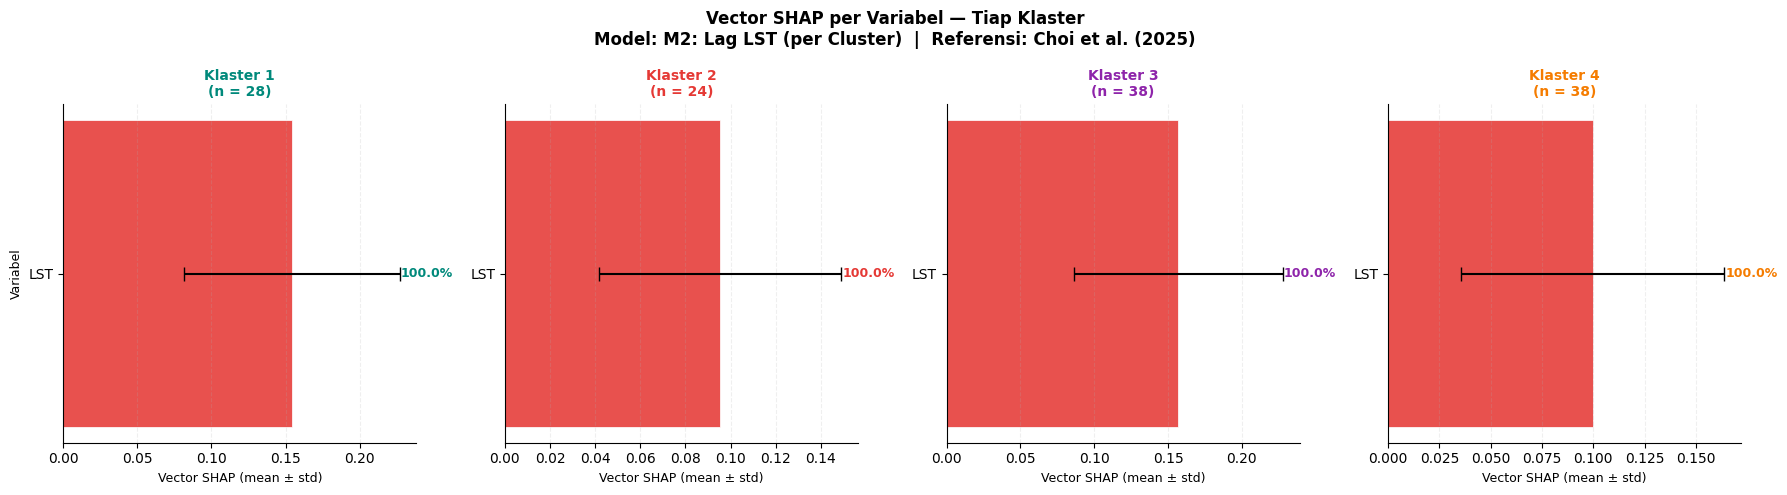

📊 Plot 2/4: Grouped Bar (perbandingan langsung antar klaster) ...


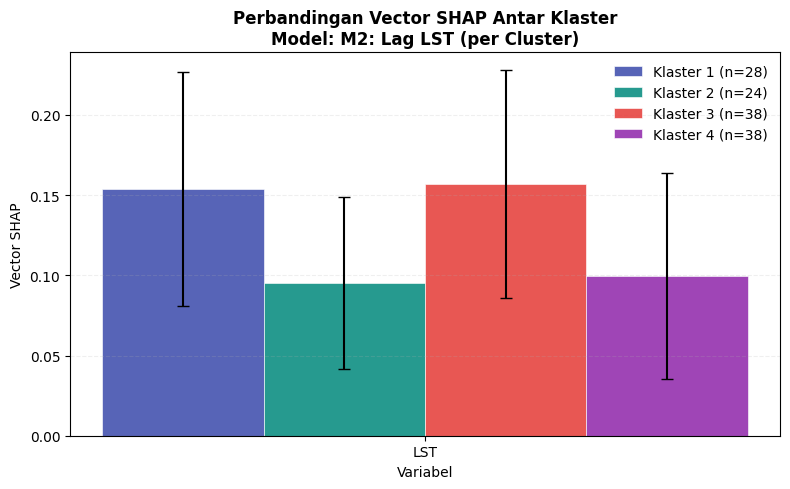

🗺️  Plot 3a/4: Heatmap nilai absolut ...


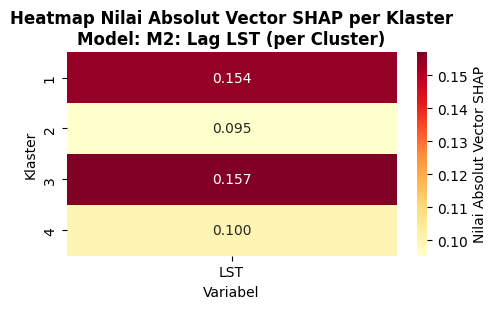

🗺️  Plot 3b/4: Heatmap persentase kontribusi ...


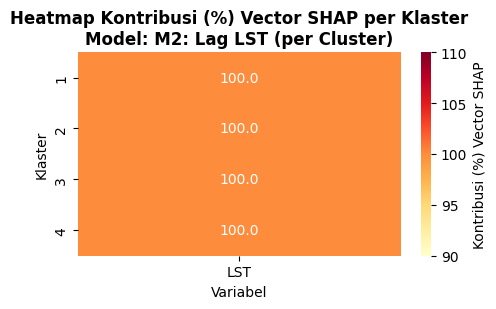

🕸️  Plot 4a/4: Radar Chart ...


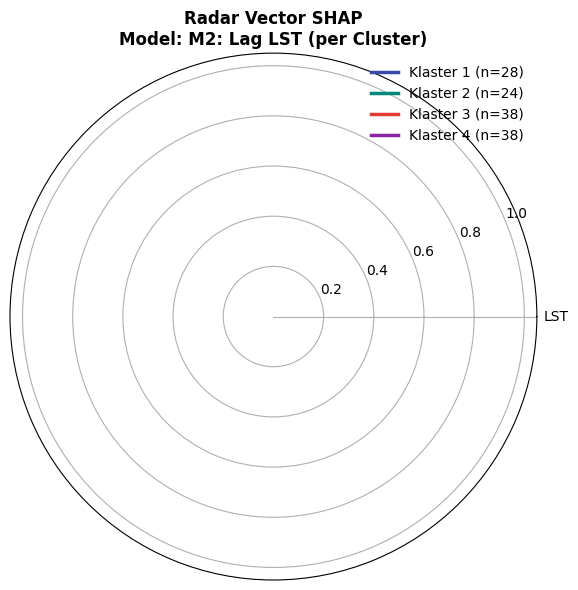

🎯 Plot 4b/4: Lag Terkuat per Klaster ...


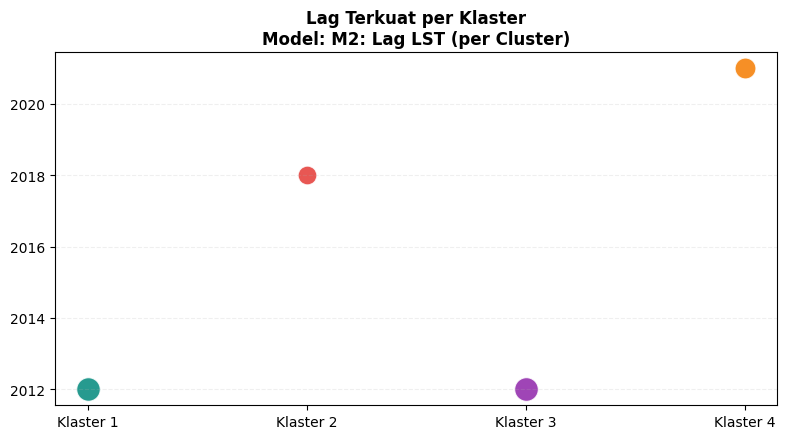


────────────────────────────────────────────────────────────
  Model: M4: Lag LST + NDVI + NDBI (per Cluster)
────────────────────────────────────────────────────────────

🔢 Menghitung SHAP per klaster ...

📐 Menghitung Vector SHAP (Choi et al., 2025) ...

═════════════════════════════════════════════════════════════════════════════════════
  TABEL VECTOR SHAP PER KLASTER — M4: Lag LST + NDVI + NDBI (per Cluster)
  Referensi: Choi et al. (2025), Journal of Forecasting
═════════════════════════════════════════════════════════════════════════════════════
 Klaster Variabel  Jumlah Lag  Vector SHAP (mean)  Vector SHAP (std)  Kontribusi (%)  Lag Terkuat (tahun)  SHAP Lag Terkuat  N Sampel Test
       1      LST           5            0.128988           0.035112       74.315424                 2012          0.185811             28
       1     NDBI           6            0.025357           0.020959       17.531045                 2024          0.062483             28
       1     NDVI      

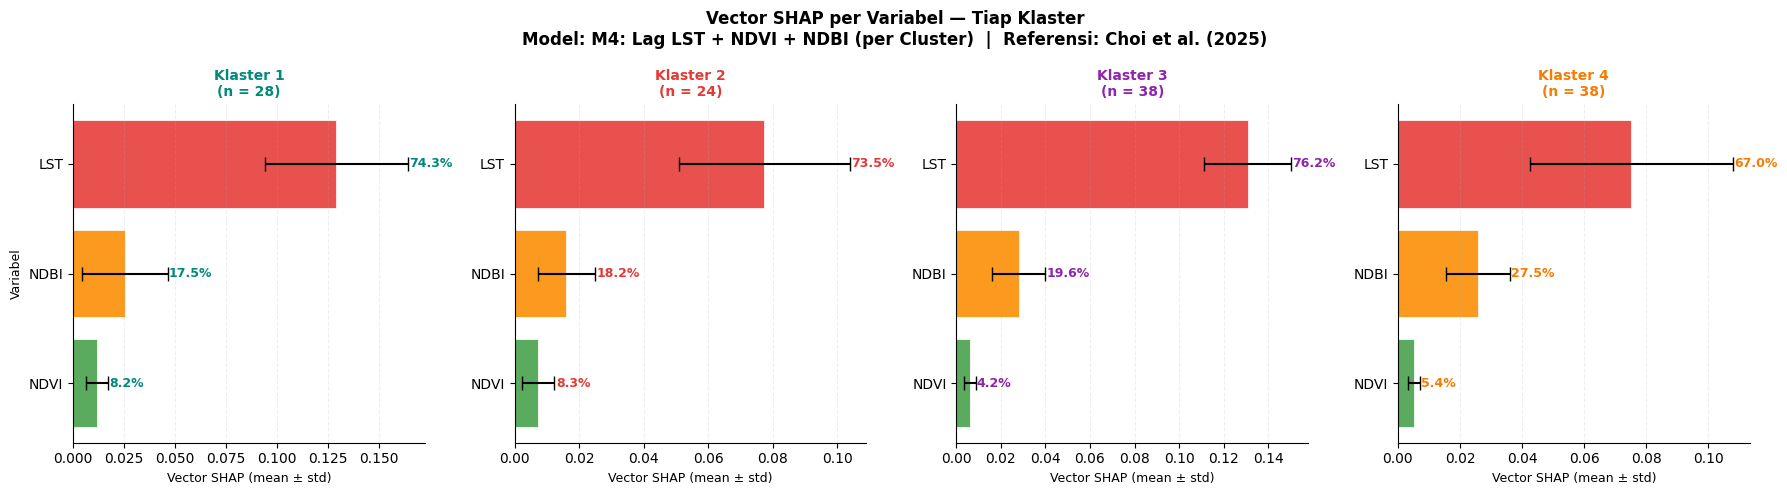

📊 Plot 2/4: Grouped Bar (perbandingan langsung antar klaster) ...


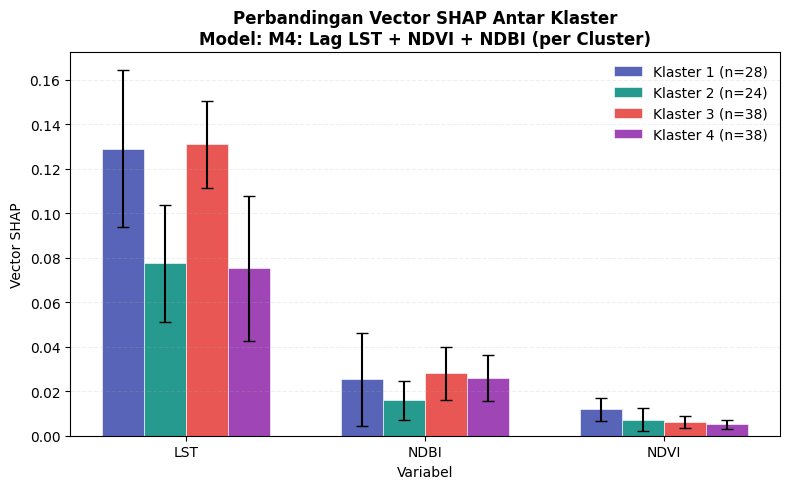

🗺️  Plot 3a/4: Heatmap nilai absolut ...


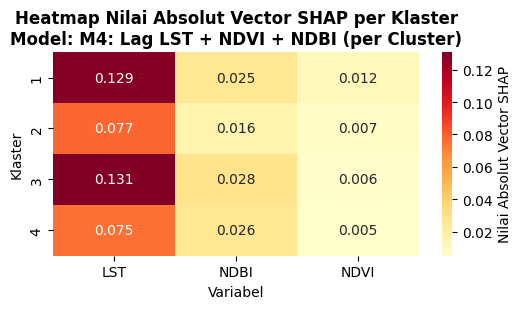

🗺️  Plot 3b/4: Heatmap persentase kontribusi ...


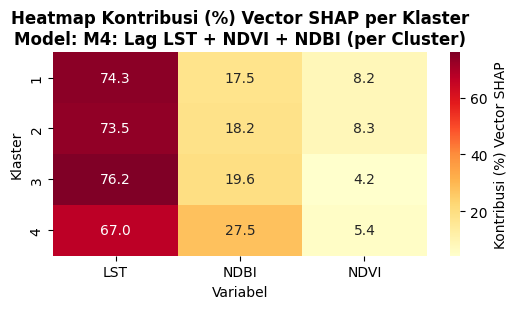

🕸️  Plot 4a/4: Radar Chart ...


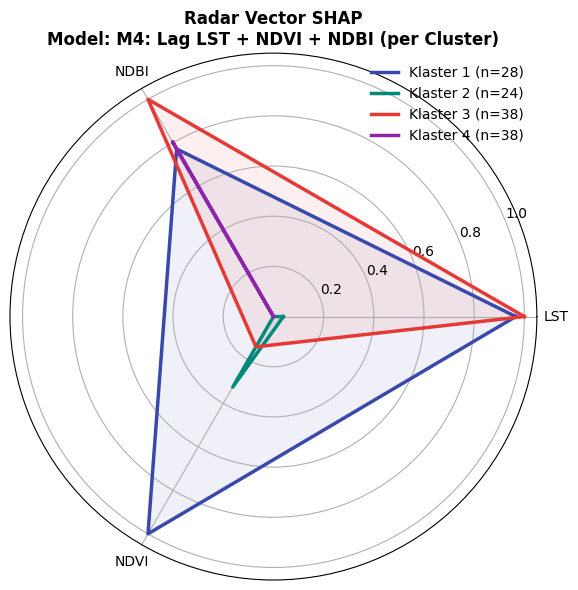

🎯 Plot 4b/4: Lag Terkuat per Klaster ...


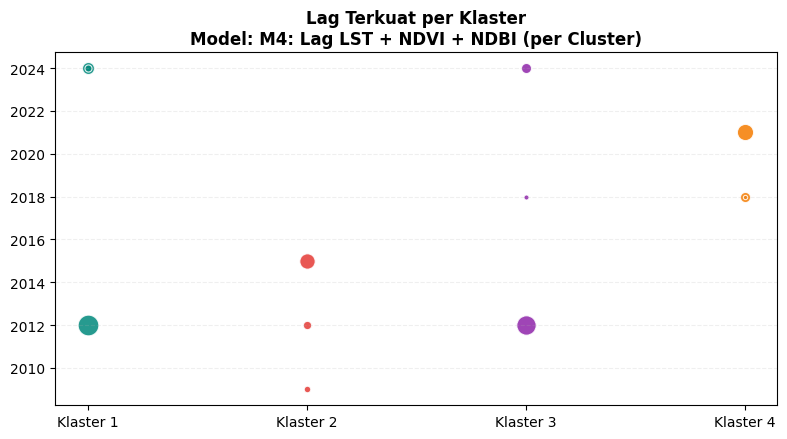


✅ Semua analisis Vector SHAP per klaster selesai!

📋 Output yang dihasilkan (per model M2/M4):
  vector_shap_cluster_*.csv           → Tabel numerik siap dikutip
  shap_vector_bar_percluster_*.png    → Bar chart per klaster (subplot)
  shap_vector_grouped_*.png           → Grouped bar: perbandingan antar klaster
  shap_vector_heatmap_abs_*.png       → Heatmap nilai absolut
  shap_vector_heatmap_pct_*.png       → Heatmap persentase kontribusi
  shap_vector_radar_*.png             → Radar: profil dominansi per klaster
  shap_dominant_lag_*.png             → Scatter: lag terkuat per klaster

📖 Template kalimat interpretasi di skripsi:
  "Menggunakan pendekatan Vector SHAP (Choi et al., 2025), kontribusi
   setiap variabel terhadap prediksi LST 2024 dianalisis secara terpisah
   untuk masing-masing klaster. Pada klaster [X], variabel [LST/NDVI/NDBI]
   memberikan kontribusi terbesar (Vector SHAP = [nilai], [persen]%),
   dengan lag tahun [Y] sebagai periode historis paling dominan.
   Seb

In [123]:
# ═════════════════════════════════════════════════════════════════════════════
# EKSEKUSI UTAMA
# Jalankan untuk semua model yang split_by_cluster (M2 dan M4)
# ═════════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('📐 VECTOR SHAP PER KLASTER — Choi et al. (2025)')
print('=' * 70)

# Tentukan model mana yang split_by_cluster
cluster_cfg_keys = [
    k for k, v in MODEL_CONFIGS.items() if v['split_by_cluster']
]

if not cluster_cfg_keys:
    print('[PERINGATAN] Tidak ada model dengan split_by_cluster=True.')
else:
    for cfg_key in cluster_cfg_keys:
        lbl = MODEL_CONFIGS[cfg_key]['label']
        print(f'\n{"─"*60}')
        print(f'  Model: {lbl}')
        print(f'{"─"*60}')

        # ── Step 1: Hitung SHAP per klaster ──────────────────────────────
        print('\n🔢 Menghitung SHAP per klaster ...')
        shap_cluster = compute_shap_per_cluster(
            cfg_key=cfg_key,
            all_results=all_results,
            clusters=clusters,
            algo='RF'
        )

        # ── Step 2: Hitung Vector SHAP per klaster ────────────────────────
        print('\n📐 Menghitung Vector SHAP (Choi et al., 2025) ...')
        df_vec_cl = compute_vector_shap_per_cluster(shap_cluster)

        # ── Step 3: Cetak & simpan tabel ──────────────────────────────────
        df_tabel = export_vector_shap_cluster_table(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path_csv=OUTPUT_DIR + f'vector_shap_cluster_{cfg_key}.csv'
        )

        # ── Step 4: Plot 1 — Bar per klaster (subplot) ────────────────────
        print('\n📊 Plot 1/4: Bar Chart per Klaster ...')
        plot_vector_shap_per_cluster(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path=OUTPUT_DIR + f'shap_vector_bar_percluster_{cfg_key}.png'
        )

        # ── Step 5: Plot 2 — Grouped bar chart ────────────────────────────
        print('📊 Plot 2/4: Grouped Bar (perbandingan langsung antar klaster) ...')
        plot_vector_shap_grouped(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path=OUTPUT_DIR + f'shap_vector_grouped_{cfg_key}.png'
        )

        # ── Step 6: Plot 3 — Heatmap (nilai absolut + persentase) ─────────
        print('🗺️  Plot 3a/4: Heatmap nilai absolut ...')
        plot_vector_shap_heatmap(
            df_vec=df_vec_cl,
            model_label=lbl,
            mode='mean',
            save_path=OUTPUT_DIR + f'shap_vector_heatmap_abs_{cfg_key}.png'
        )

        print('🗺️  Plot 3b/4: Heatmap persentase kontribusi ...')
        plot_vector_shap_heatmap(
            df_vec=df_vec_cl,
            model_label=lbl,
            mode='pct',
            save_path=OUTPUT_DIR + f'shap_vector_heatmap_pct_{cfg_key}.png'
        )

        # ── Step 7: Plot 4 — Radar chart ──────────────────────────────────
        print('🕸️  Plot 4a/4: Radar Chart ...')
        plot_vector_shap_radar(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path=OUTPUT_DIR + f'shap_vector_radar_{cfg_key}.png'
        )

        # ── Step 8: Plot 5 — Dominant lag scatter ─────────────────────────
        print('🎯 Plot 4b/4: Lag Terkuat per Klaster ...')
        plot_dominant_lag_per_cluster(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path=OUTPUT_DIR + f'shap_dominant_lag_{cfg_key}.png'
        )


# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('✅ Semua analisis Vector SHAP per klaster selesai!')
print('=' * 70)
print("""
📋 Output yang dihasilkan (per model M2/M4):
  vector_shap_cluster_*.csv           → Tabel numerik siap dikutip
  shap_vector_bar_percluster_*.png    → Bar chart per klaster (subplot)
  shap_vector_grouped_*.png           → Grouped bar: perbandingan antar klaster
  shap_vector_heatmap_abs_*.png       → Heatmap nilai absolut
  shap_vector_heatmap_pct_*.png       → Heatmap persentase kontribusi
  shap_vector_radar_*.png             → Radar: profil dominansi per klaster
  shap_dominant_lag_*.png             → Scatter: lag terkuat per klaster

📖 Template kalimat interpretasi di skripsi:
  "Menggunakan pendekatan Vector SHAP (Choi et al., 2025), kontribusi
   setiap variabel terhadap prediksi LST 2024 dianalisis secara terpisah
   untuk masing-masing klaster. Pada klaster [X], variabel [LST/NDVI/NDBI]
   memberikan kontribusi terbesar (Vector SHAP = [nilai], [persen]%),
   dengan lag tahun [Y] sebagai periode historis paling dominan.
   Sebaliknya, klaster [Z] menunjukkan pola berbeda di mana..."
""")

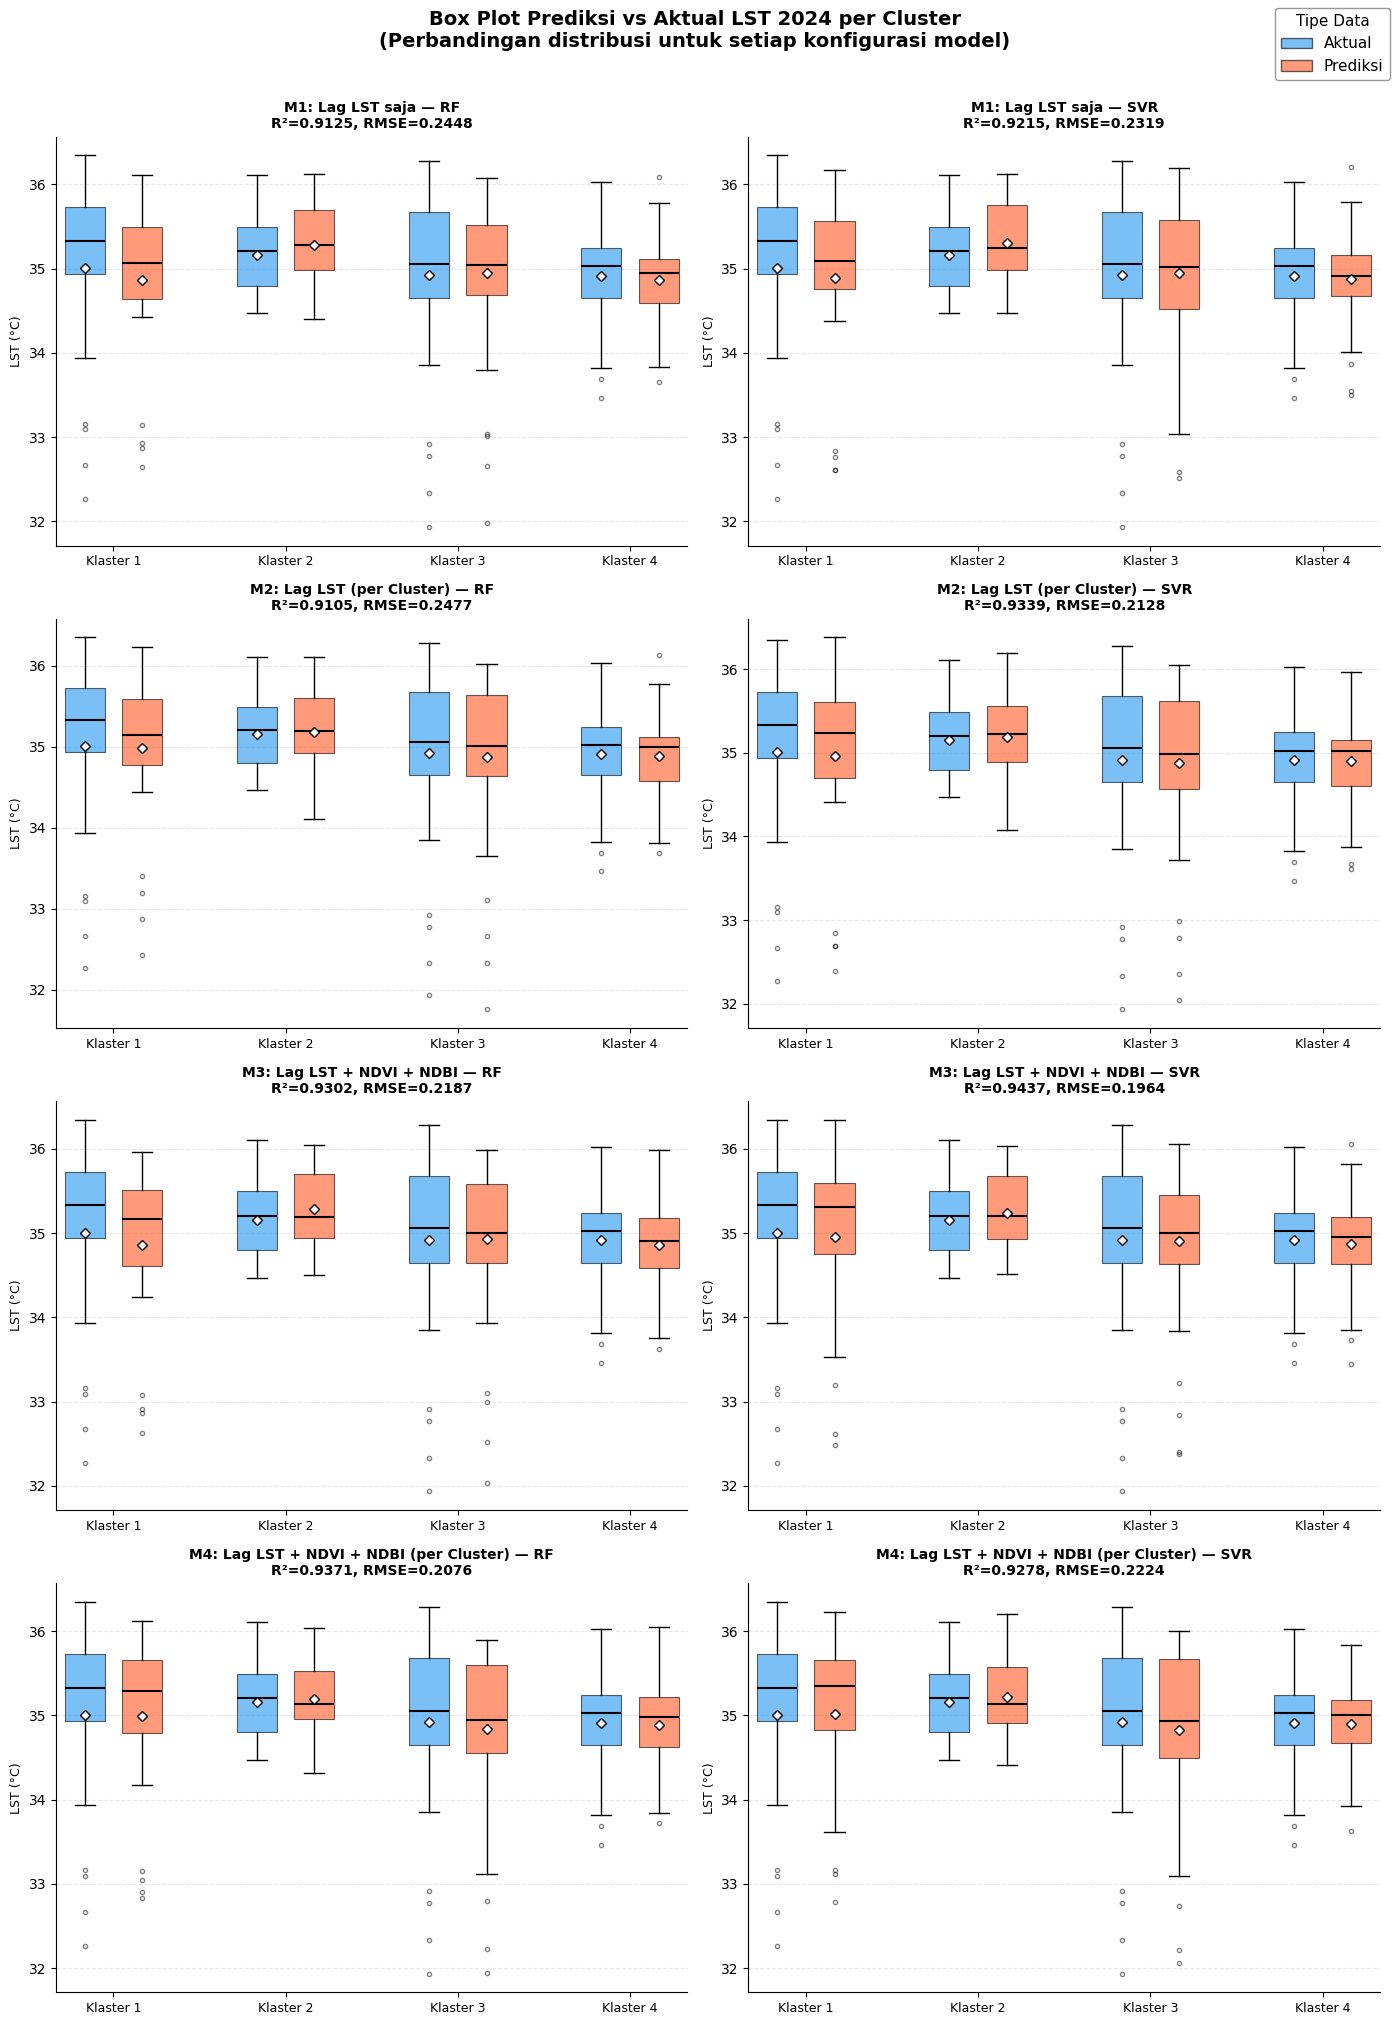

💾 Disimpan: output/regression/boxplot_pred_vs_actual_per_cluster.png

✅ Box plot prediksi vs aktual per cluster selesai!


In [124]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  BOX PLOT — PREDIKSI vs AKTUAL LST PER CLUSTER
#  Visualisasi distribusi prediksi vs aktual per klaster
#  untuk semua konfigurasi model (M1–M4) x RF & SVR
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def plot_boxplot_pred_vs_actual_per_cluster(
    all_results, model_configs, df, cluster_col, target_col,
    clusters, idx_train_global, idx_test_global, output_dir
):
    """
    Membuat box plot berderet: Prediksi vs Aktual LST per cluster
    untuk SEMUA konfigurasi model (M1–M4) x algoritma (RF, SVR).

    Setiap subplot = 1 konfigurasi model + 1 algoritma.
    Di dalam subplot: per cluster ada 2 box (Aktual & Prediksi).
    """
    cfg_keys = list(model_configs.keys())
    algos    = ['RF', 'SVR']
    n_cfgs   = len(cfg_keys)
    n_algos  = len(algos)

    fig, axes = plt.subplots(
        n_cfgs, n_algos,
        figsize=(7 * n_algos, 5 * n_cfgs),
        squeeze=False
    )

    fig.suptitle(
        f'Box Plot Prediksi vs Aktual LST {TARGET_YEAR} per Cluster\n'
        f'(Perbandingan distribusi untuk setiap konfigurasi model)',
        fontsize=14, fontweight='bold', y=1.01
    )

    # Warna konsisten
    color_actual  = '#2196F3'   # biru
    color_predict = '#FF5722'   # oranye-merah

    for row_i, cfg_key in enumerate(cfg_keys):
        cfg       = model_configs[cfg_key]
        is_split  = cfg['split_by_cluster']

        for col_j, algo in enumerate(algos):
            ax  = axes[row_i, col_j]
            res = all_results.get((cfg_key, algo))

            if res is None:
                ax.set_visible(False)
                continue

            # Kumpulkan data per cluster
            box_data = []   # list of dicts {cluster, type, values}

            if is_split:
                # Model per cluster: gunakan cluster_y_test dan prediksi per cluster
                for cl in clusters:
                    y_true_cl = res['cluster_y_test'][cl]
                    # Re-predict menggunakan model per cluster
                    cl_model  = res['cluster_models'][cl][algo]
                    X_te_cl   = res['cluster_X_test'][cl]
                    y_pred_cl = cl_model.predict(X_te_cl)

                    box_data.append({'cluster': int(cl), 'type': 'Aktual',   'values': y_true_cl})
                    box_data.append({'cluster': int(cl), 'type': 'Prediksi', 'values': y_pred_cl})
            else:
                # Model global: split y_test berdasarkan cluster dari df
                y_true_all = res['y_test']
                y_pred_all = res['y_pred_test']
                # Cluster info dari test indices
                cluster_test = df.loc[idx_test_global, cluster_col].values

                for cl in clusters:
                    mask = cluster_test == cl
                    if mask.sum() == 0:
                        continue
                    box_data.append({'cluster': int(cl), 'type': 'Aktual',   'values': y_true_all[mask]})
                    box_data.append({'cluster': int(cl), 'type': 'Prediksi', 'values': y_pred_all[mask]})

            # Plot box plot berderet
            positions = []
            labels    = []
            colors_bp = []
            all_vals  = []

            pos = 0
            cluster_centers = []
            for i, cl in enumerate(clusters):
                # Cari data untuk cluster ini
                actual_data  = [d for d in box_data if d['cluster'] == int(cl) and d['type'] == 'Aktual']
                predict_data = [d for d in box_data if d['cluster'] == int(cl) and d['type'] == 'Prediksi']

                if not actual_data or not predict_data:
                    continue

                # Posisi: Aktual, Prediksi, lalu gap
                positions.append(pos)
                all_vals.append(actual_data[0]['values'])
                colors_bp.append(color_actual)

                positions.append(pos + 1)
                all_vals.append(predict_data[0]['values'])
                colors_bp.append(color_predict)

                cluster_centers.append(pos + 0.5)
                labels.append(f'Klaster {int(cl)}')

                pos += 3  # gap antar cluster

            # Buat boxplot
            bp = ax.boxplot(
                all_vals,
                positions=positions,
                widths=0.7,
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='white',
                              markeredgecolor='black', markersize=5),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(linewidth=1),
                capprops=dict(linewidth=1),
                flierprops=dict(marker='o', markersize=3, alpha=0.5)
            )

            # Set warna per box
            for patch, color in zip(bp['boxes'], colors_bp):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
                patch.set_edgecolor('black')
                patch.set_linewidth(0.8)

            # Labels & styling
            ax.set_xticks(cluster_centers)
            ax.set_xticklabels(labels, fontsize=9)

            # Metrik di judul
            r2_val   = res.get('Test_R2', 0)
            rmse_val = res.get('Test_RMSE', 0)
            ax.set_title(
                f'{cfg["label"]} — {algo}\n'
                f'R²={r2_val:.4f}, RMSE={rmse_val:.4f}',
                fontsize=10, fontweight='bold'
            )
            ax.set_ylabel('LST (°C)', fontsize=9)
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            sns.despine(ax=ax)

    # Legend global
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=color_actual,  alpha=0.6, edgecolor='black', label='Aktual'),
        Patch(facecolor=color_predict, alpha=0.6, edgecolor='black', label='Prediksi'),
    ]
    fig.legend(
        handles=legend_elements,
        loc='upper right',
        fontsize=11,
        frameon=True,
        edgecolor='gray',
        fancybox=True,
        title='Tipe Data',
        title_fontsize=11
    )

    plt.tight_layout()
    fname = output_dir + 'boxplot_pred_vs_actual_per_cluster.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Disimpan: {fname}')
    plt.close()


# ── Jalankan ──────────────────────────────────────────────────────────────────
plot_boxplot_pred_vs_actual_per_cluster(
    all_results=all_results,
    model_configs=MODEL_CONFIGS,
    df=df,
    cluster_col=CLUSTER_COL,
    target_col=TARGET_COL,
    clusters=clusters,
    idx_train_global=idx_train_global,
    idx_test_global=idx_test_global,
    output_dir=OUTPUT_DIR,
)

print('\n✅ Box plot prediksi vs aktual per cluster selesai!')


── Box Plot Detail: RF ──


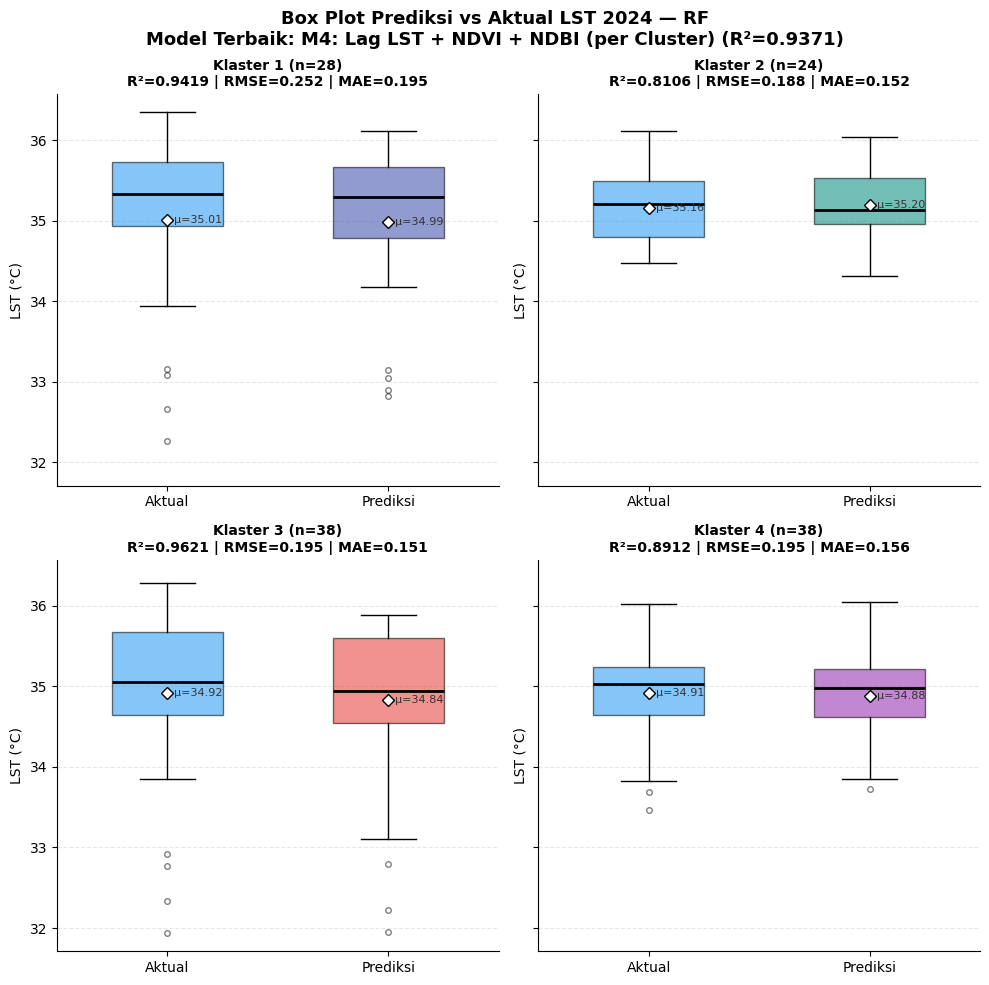

💾 Disimpan: output/regression/boxplot_pred_actual_best_rf.png

── Box Plot Detail: SVR ──


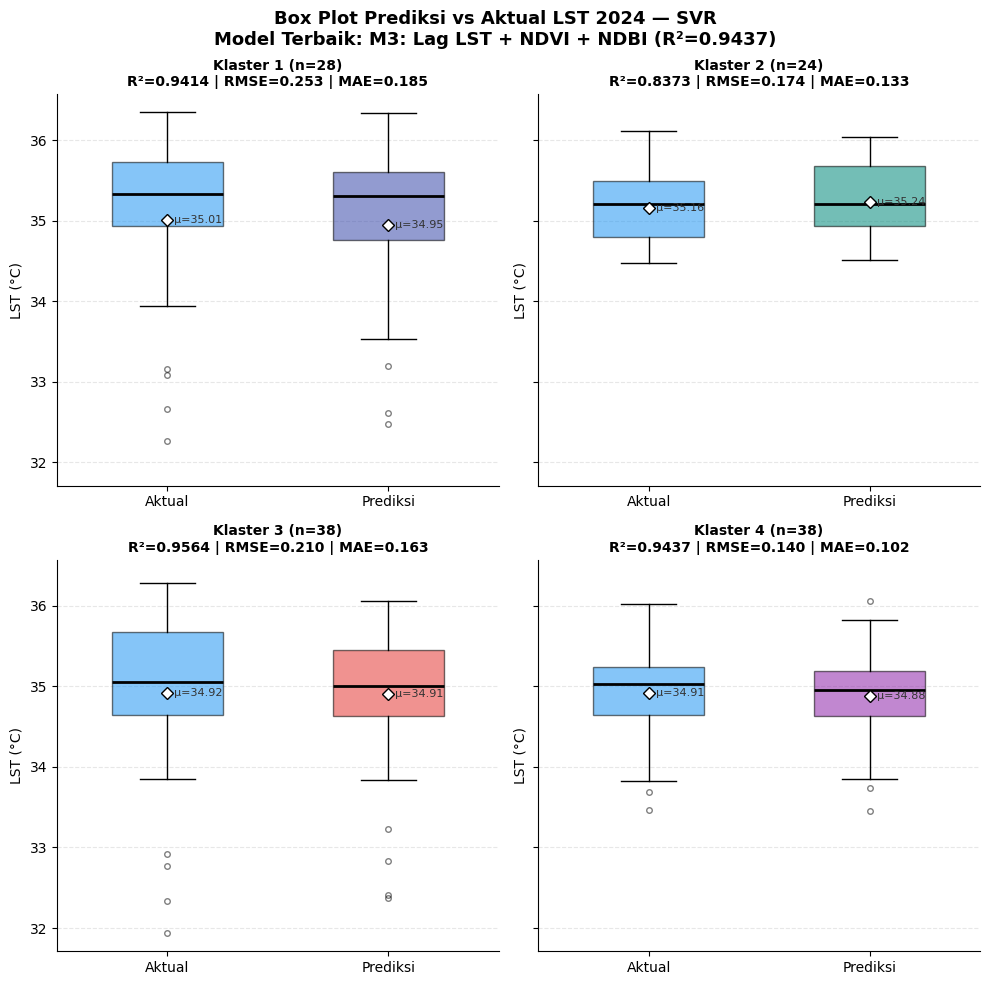

💾 Disimpan: output/regression/boxplot_pred_actual_best_svr.png

✅ Box plot detail per algoritma selesai!


In [125]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  BOX PLOT DETAIL — PREDIKSI vs AKTUAL per CLUSTER
#  Layout 2x2
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import math

def plot_best_model_boxplot(algo, all_results, model_configs,
                            df_summary, df, cluster_col, clusters,
                            idx_test_global, output_dir):
    """
    Box plot prediksi vs aktual per klaster untuk model terbaik
    berdasarkan Test_R² tertinggi pada algoritma tertentu.
    """

    cfg_keys = list(model_configs.keys())

    # Cari model terbaik
    df_algo = df_summary[df_summary['Algorithm'] == algo].reset_index(drop=True)
    best_idx = df_algo['Test_R2'].idxmax()

    best_cfg = cfg_keys[best_idx] if best_idx < len(cfg_keys) else cfg_keys[0]
    best_r2  = df_algo.loc[best_idx, 'Test_R2']

    res       = all_results[(best_cfg, algo)]
    cfg       = model_configs[best_cfg]
    is_split  = cfg['split_by_cluster']

# CLUSTER_PALETTE didefinisikan di Sel 6 (Fungsi Helper)
    # Ambil warna sesuai jumlah cluster
    cluster_colors = CLUSTER_PALETTE[:len(clusters)]

    # ── Layout subplot 2x2 ─────────────────────────────
    n_clusters = len(clusters)
    n_cols = 2
    n_rows = math.ceil(n_clusters / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(10, 5 * n_rows),
        sharey=True
    )

    # Flatten axes supaya mudah di-loop
    axes = np.array(axes).flatten()

    fig.suptitle(
        f'Box Plot Prediksi vs Aktual LST {TARGET_YEAR} — {algo}\n'
        f'Model Terbaik: {cfg["label"]} (R²={best_r2:.4f})',
        fontsize=13,
        fontweight='bold'
    )

    # ── Plot per cluster ───────────────────────────────
    for ax, cl, cl_color in zip(axes, clusters, cluster_colors):

        if is_split:
            y_true_cl = res['cluster_y_test'][cl]
            cl_model  = res['cluster_models'][cl][algo]
            X_te_cl   = res['cluster_X_test'][cl]
            y_pred_cl = cl_model.predict(X_te_cl)

        else:
            y_true_all  = res['y_test']
            y_pred_all  = res['y_pred_test']
            cluster_arr = df.loc[idx_test_global, cluster_col].values

            mask      = cluster_arr == cl
            y_true_cl = y_true_all[mask]
            y_pred_cl = y_pred_all[mask]

        if len(y_true_cl) == 0:
            ax.set_visible(False)
            continue

        # ── Boxplot ────────────────────────────────────
        bp = ax.boxplot(
            [y_true_cl, y_pred_cl],
            tick_labels=['Aktual', 'Prediksi'],  # matplotlib >=3.9: 'labels' diganti 'tick_labels'
            patch_artist=True,
            widths=0.5,
            showmeans=True,
            meanprops=dict(
                marker='D',
                markerfacecolor='white',
                markeredgecolor='black',
                markersize=6
            ),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', markersize=4, alpha=0.5)
        )

        # Warna box
        bp['boxes'][0].set(facecolor='#2196F3', alpha=0.55)
        bp['boxes'][1].set(facecolor=cl_color, alpha=0.55)

        # ── Statistik ──────────────────────────────────
        r2_cl   = r2_score(y_true_cl, y_pred_cl)
        rmse_cl = np.sqrt(mean_squared_error(y_true_cl, y_pred_cl))
        mae_cl  = mean_absolute_error(y_true_cl, y_pred_cl)

        ax.set_title(
            f'Klaster {int(cl)} (n={len(y_true_cl)})\n'
            f'R²={r2_cl:.4f} | RMSE={rmse_cl:.3f} | MAE={mae_cl:.3f}',
            fontsize=10,
            fontweight='bold'
        )

        ax.set_ylabel('LST (°C)', fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Mean annotation
        for i, data in enumerate([y_true_cl, y_pred_cl]):
            mean_val = np.mean(data)

            ax.text(
                i + 1,
                mean_val,
                f'  μ={mean_val:.2f}',
                va='center',
                ha='left',
                fontsize=8,
                color='#333333'
            )

        sns.despine(ax=ax)

    # ── Sembunyikan subplot kosong ────────────────────
    for extra_ax in axes[n_clusters:]:
        extra_ax.set_visible(False)

    plt.tight_layout()

    fname = output_dir + f'boxplot_pred_actual_best_{algo.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')

    plt.show()
    print(f'💾 Disimpan: {fname}')

    plt.close()


# ── Jalankan untuk RF dan SVR ─────────────────────────
for algo in ['RF', 'SVR']:

    print(f'\n── Box Plot Detail: {algo} ──')

    plot_best_model_boxplot(
        algo=algo,
        all_results=all_results,
        model_configs=MODEL_CONFIGS,
        df_summary=df_summary,
        df=df,
        cluster_col=CLUSTER_COL,
        clusters=clusters,
        idx_test_global=idx_test_global,
        output_dir=OUTPUT_DIR,
    )

print('\n✅ Box plot detail per algoritma selesai!')

📐 TRUE VECTOR SHAP — Choi et al. (2025) [Implementasi Benar]
   Persamaan (4)-(8): Kernel SHAP di level J variabel

Variabel groups yang terdeteksi:
  LST: 5 lag → tahun [2009, 2012, 2015, 2018, 2021]
  NDVI: 6 lag → tahun [2009, 2012, 2015, 2018, 2021, 2024]
  NDBI: 6 lag → tahun [2009, 2012, 2015, 2018, 2021, 2024]

🔢 Menghitung True Vector SHAP (Φⱼ) — model M4: Lag LST + NDVI + NDBI (per Cluster)...
   J=3 variabel, total lag M=17
   Kompleksitas: O(2^3) = 8 evaluasi (vs O(2^17) standard)

✅ Verifikasi Vector Local Accuracy — M4: Lag LST + NDVI + NDBI (per Cluster)
   [Proposition 3.2(ii), Choi et al. 2025]
   Max |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   Mean |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   → ✅ LULUS: properti vector local accuracy terpenuhi

📊 Ringkasan True Vector SHAP:
cluster variable  vector_shap_mean  vector_shap_std  vector_shap_sem  vector_shap_q25  vector_shap_q75  vector_shap_median  vector_shap_pct  n_samples
    All      LST          0.491516         0.460459         0.040699      

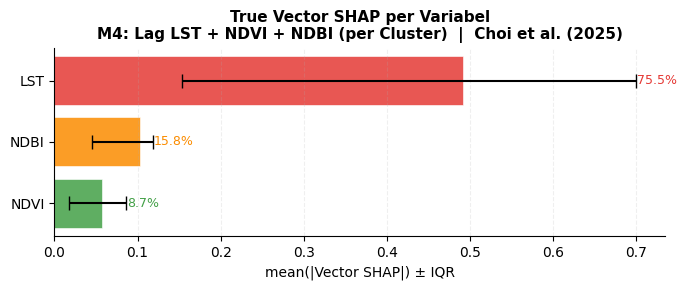


🔬 Membandingkan Φⱼ (True Vector) vs Φ⁰ⱼ (Sum SHAP)...

══════════════════════════════════════════════════════════════════════
  PERBANDINGAN Φⱼ vs Φ⁰ⱼ — M4: Lag LST + NDVI + NDBI (per Cluster)
  [Sesuai Remark 2.1 & Tabel 1, Choi et al. (2025)]
══════════════════════════════════════════════════════════════════════
variable  |Φⱼ| mean (True Vector)  |Φ⁰ⱼ| mean (Sum SHAP)  RMSD (Φⱼ vs Φ⁰ⱼ)  RMSD (% of std_y)
     LST                 0.491516               0.472612          0.183950             46.038
    NDVI                 0.056856               0.030910          0.070402             17.620
    NDBI                 0.102721               0.136920          0.069522             17.400

  Rata-rata RMSD: 0.107958
  Jika RMSD kecil → Φⱼ ≈ Φ⁰ⱼ (sesuai temuan jurnal RMSD < 1.16%)
══════════════════════════════════════════════════════════════════════
💾 Disimpan: output/regression/phi_vs_phi0_scatter_M4_LagAll_byCluster.png


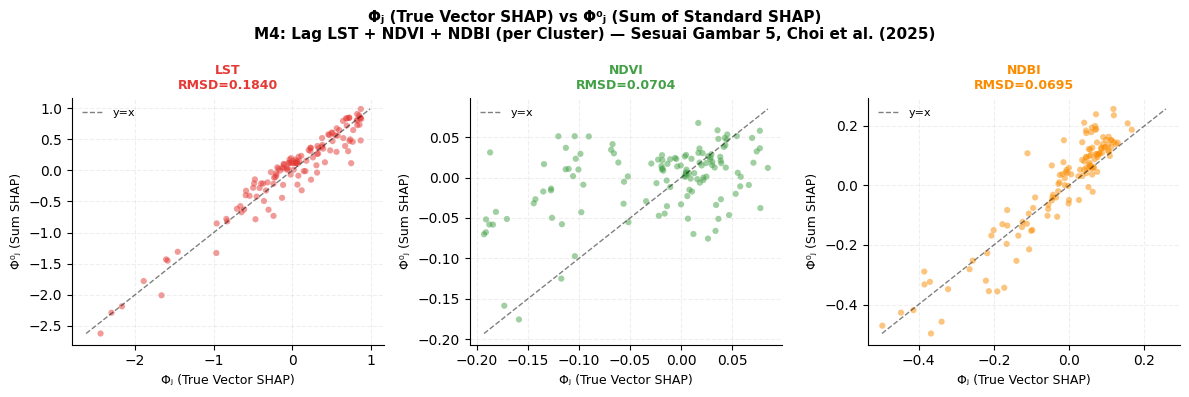


📐 Menghitung True Vector SHAP per Klaster...

  Model: M2: Lag LST (per Cluster)
  ───────────────────────────────────────────────────────
  Klaster 1 (n=28)... ✅ local_acc_error=0.00e+00
  Klaster 2 (n=24)... ✅ local_acc_error=0.00e+00
  Klaster 3 (n=38)... ✅ local_acc_error=0.00e+00
  Klaster 4 (n=38)... ✅ local_acc_error=0.00e+00

  Tabel True Vector SHAP per Klaster — M2: Lag LST (per Cluster):
  ═══════════════════════════════════════════════════════════════════════════
 cluster variable  vector_shap_mean  vector_shap_std  vector_shap_pct  n_samples
       1      LST          0.676764         0.661787            100.0         28
       2      LST          0.404491         0.315235            100.0         24
       3      LST          0.718988         0.692637            100.0         38
       4      LST          0.420706         0.375889            100.0         38
  ═══════════════════════════════════════════════════════════════════════════
  💾 Disimpan: true_vector_shap_clust

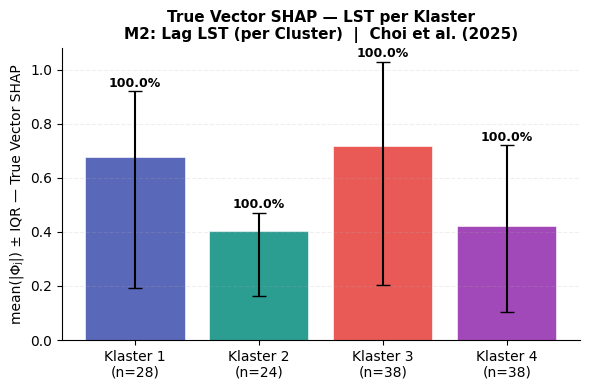


  Model: M4: Lag LST + NDVI + NDBI (per Cluster)
  ───────────────────────────────────────────────────────
  Klaster 1 (n=28)... ✅ local_acc_error=0.00e+00
  Klaster 2 (n=24)... ✅ local_acc_error=0.00e+00
  Klaster 3 (n=38)... ✅ local_acc_error=7.11e-15
  Klaster 4 (n=38)... ✅ local_acc_error=0.00e+00

  Tabel True Vector SHAP per Klaster — M4: Lag LST + NDVI + NDBI (per Cluster):
  ═══════════════════════════════════════════════════════════════════════════
 cluster variable  vector_shap_mean  vector_shap_std  vector_shap_pct  n_samples
       1      LST          0.604670         0.548587            78.72         28
       1     NDBI          0.118161         0.113413            15.38         28
       1     NDVI          0.045279         0.048542             5.89         28
       2      LST          0.358829         0.247075            75.16         24
       2     NDVI          0.059350         0.034748            12.43         24
       2     NDBI          0.059259         0.04921

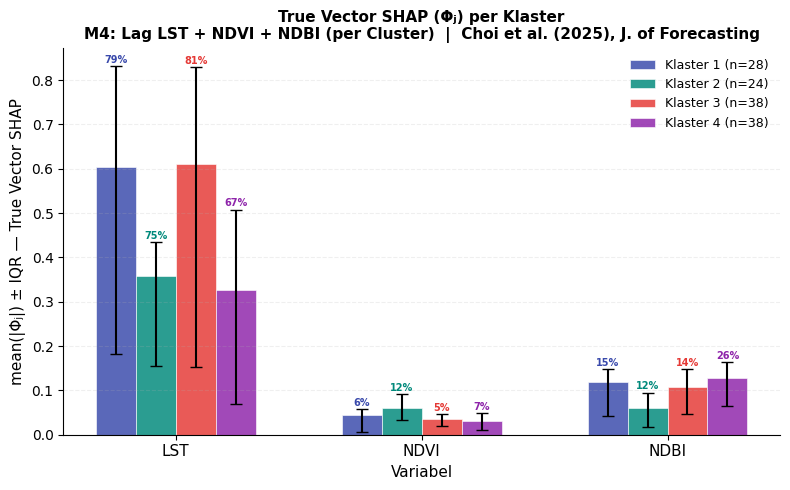


✅ True Vector SHAP (Choi et al., 2025) selesai dihitung!

📋 Output yang dihasilkan:
  true_vector_shap_overall_*.png     → Bar chart Φⱼ keseluruhan
  phi_vs_phi0_scatter_*.png          → Scatter Φⱼ vs Φ⁰ⱼ (validasi jurnal)
  true_vector_shap_cluster_*.csv     → Tabel numerik per klaster
  true_vector_shap_grouped_*.png     → Grouped bar per klaster

📖 Perbedaan implementasi vs kode sebelumnya:
  LAMA : Φ⁰ⱼ = Σ|φl| per variabel   → sum SHAP standar [Persamaan (3)]
  BARU : Φⱼ  = Shapley value Xⱼ     → kernel SHAP di level J [Persamaan (8)]

  Jurnal membuktikan Φⱼ ≈ Φ⁰ⱼ (RMSD < 1.16%) tapi Φⱼ lebih tepat
  secara konseptual karena koalisi antar variabel lebih natural.

📖 Template kutipan skripsi:
  "Interpretasi model dilakukan menggunakan Vector SHAP (Choi et al., 2025)
   yang mengukur kontribusi vektor lag setiap variabel (Φⱼ) terhadap
   prediksi LST 2024. Berbeda dari standard SHAP yang mengukur kontribusi
   setiap lag secara individual, Vector SHAP memperlakukan seluruh riwayat


In [126]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  IMPLEMENTASI VECTOR SHAP — Choi et al. (2025) [VERSI YANG BENAR]          ║
║  Journal of Forecasting, 44:635–645, DOI: 10.1002/for.3220                 ║
║                                                                              ║
║  PERBEDAAN DARI KODE SEBELUMNYA:                                            ║
║                                                                              ║
║  Kode lama  → mengimplementasikan Φ⁰ⱼ (sum of standard SHAP per variabel) ║
║               = Σ_{l=1}^{pj} φ_{p1+...+pj-1+l}  [Persamaan (3) jurnal]   ║
║                                                                              ║
║  Kode ini   → mengimplementasikan Φⱼ (True Vector SHAP)                   ║
║               = Shapley value dari VEKTOR Xⱼ secara langsung               ║
║               = kernel SHAP dijalankan di level J variabel, bukan M lag    ║
║               [Persamaan (6)-(8) jurnal]                                    ║
║                                                                              ║
║  Kompleksitas: O(2^J + J³) vs O(2^M + M³) untuk standard SHAP             ║
║  Contoh: J=3 variabel, p=5 lag → M=15                                      ║
║          Standard: O(2^15) = 32.768 vs Vector: O(2^3) = 8                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

STRUKTUR DATA PENELITIAN INI:
  Variabel: LST (5 lag: 2009,2012,2015,2018,2021)
            NDVI (6 lag: 2009,2012,2015,2018,2021,2024_baseline)
            NDBI (6 lag: 2009,2012,2015,2018,2021,2024_baseline)
  J = 3 variabel, p ≈ 5-6 lag per variabel
  Target: LST 2024

  Dalam notasi jurnal:
    X1t = (lst_2009, lst_2012, lst_2015, lst_2018, lst_2021)^T  [p1=5]
    X2t = (ndvi_2009, ..., ndvi_2021)^T                          [p2=6]
    X3t = (ndbi_2009, ..., ndbi_2021)^T                          [p3=6]
    ŷt  = f(X1t, X2t, X3t) = prediksi LST 2024
"""

import itertools
import matplotlib.patches as mpatches
from scipy.special import comb
# re, numpy, pandas, matplotlib, seaborn, warnings sudah di-import di Sel 3
# extract_year(), get_var_type(), COLOR_VAR, CLUSTER_PALETTE didefinisikan di Sel 6 (Fungsi Helper)


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI INTI: TRUE VECTOR KERNEL SHAP
# Implementasi Persamaan (4)-(8) dari Choi et al. (2025)
# ═════════════════════════════════════════════════════════════════════════════

def _shap_kernel_weight(z: np.ndarray, J: int) -> float:
    """
    Kernel weight w(z) dari persamaan (6) jurnal Choi et al. (2025):
        w(z) = (J-1) / [C(J, |z|) * |z| * (J - |z|)]
    Di mana |z| adalah jumlah elemen 1 dalam z.
    Untuk |z|=0 atau |z|=J, w(z)=∞ (constraint penuh).
    """
    s = int(z.sum())
    if s == 0 or s == J:
        return np.inf
    return (J - 1) / (comb(J, s, exact=True) * s * (J - s))


def compute_true_vector_shap(
        model,
        X_test: np.ndarray,
        feature_names: list,
        var_groups: dict,
        background: np.ndarray = None) -> dict:
    """
    Implementasi Vector Kernel SHAP sesuai Choi et al. (2025),
    Persamaan (4)-(8).

    Ide utama (dari jurnal, hal. 636-637):
    - Perlakukan setiap variabel (LST, NDVI, NDBI) sebagai SATU pemain
    - z ∈ {0,1}^J: vektor biner sepanjang jumlah variabel J
    - zⱼ=1: gunakan nilai aktual Xⱼ
    - zⱼ=0: ganti seluruh lag Xⱼ dengan nilai mean (imputasi)
    - Jalankan Kernel SHAP di ruang J dimensi (bukan M dimensi)

    Parameter
    ---------
    model         : model terlatih dengan method .predict()
    X_test        : np.ndarray (n_samples, n_features)
    feature_names : list nama fitur
    var_groups    : dict {nama_variabel: [indeks_kolom]}
                    misal {'LST': [0,1,2,3,4], 'NDVI': [5,6,7,8,9,10]}
    background    : np.ndarray (n_bg, n_features), default=mean X_test

    Returns
    -------
    dict: {
        'phi'     : np.ndarray (n_samples, J) — Vector SHAP values Φⱼ
        'phi0'    : np.ndarray (n_samples,)   — baseline predictions
        'var_names': list nama variabel [J]
        'local_accuracy_check': float — max |Σ Φⱼ - (ŷ - ŷ_baseline)|
    }
    """
    var_names = list(var_groups.keys())
    J = len(var_names)
    n_samples = X_test.shape[0]

    # Background: mean setiap fitur (imputasi untuk zⱼ=0)
    # Sesuai jurnal: x̄ⱼ = mean sample dari lag variabel j [hal. 635]
    if background is None:
        background = X_test.mean(axis=0, keepdims=True)  # (1, M)
    X_mean = background.mean(axis=0)  # (M,) — mean per fitur

    # Prediksi baseline: f(X̄₁, X̄₂, ..., X̄ⱼ) = f(background)
    # Sesuai jurnal persamaan (7): f₀ = f(h(0)) = Φ₀
    phi0 = model.predict(
        np.tile(X_mean, (n_samples, 1))
    ).flatten()  # (n_samples,)

    # Prediksi aktual: f(X₁, X₂, ..., Xⱼ) = ŷ
    y_pred = model.predict(X_test).flatten()  # (n_samples,)

    # ── Kasus khusus J=1: hanya satu variabel ─────────────────────────────
    # Jika J=1 (misal model M2 yang hanya pakai LST), tidak ada koalisi
    # parsial yang mungkin (z_valid = {} karena 0 < sum(z) < 1 mustahil).
    # Dalam kasus ini Φ₁ = ŷ - Φ₀ secara langsung dari local accuracy:
    #   Φ₀ + Φ₁ = ŷ  →  Φ₁ = ŷ - Φ₀
    # Ini adalah solusi analitik eksak untuk J=1.
    if J == 1:
        PHI = (y_pred - phi0).reshape(n_samples, 1)
        local_acc_error = float(np.abs(phi0 + PHI[:, 0] - y_pred).max())
        return {
            'phi'                  : PHI,
            'phi0'                 : phi0,
            'var_names'            : var_names,
            'y_pred'               : y_pred,
            'local_accuracy_error' : local_acc_error,
        }

    # ── J >= 2: Kernel SHAP di level variabel ─────────────────────────────
    # Enumerate semua z ∈ {0,1}^J kecuali 0 dan 1
    # Sesuai jurnal: WLS dijalankan untuk z ∈ {0,1}^J - {0, 1}
    all_z   = list(itertools.product([0, 1], repeat=J))
    z_valid = [z for z in all_z if 0 < sum(z) < J]
    n_z     = len(z_valid)  # = 2^J - 2

    # ── Hitung fz untuk setiap z dan setiap sampel ────────────────────────
    # fz = f(h(z)): prediksi saat variabel dengan zⱼ=0 diganti mean
    # Sesuai jurnal persamaan (4)-(5)
    F_z = np.zeros((n_samples, n_z))  # (n_samples, 2^J - 2)

    for iz, z in enumerate(z_valid):
        X_hz = X_test.copy()
        for j, var_name in enumerate(var_names):
            if z[j] == 0:
                # Ganti semua lag variabel j dengan nilai mean-nya
                # Sesuai jurnal persamaan (4): X̃ⱼ = X̄ⱼ jika zⱼ=0
                col_idxs = var_groups[var_name]
                X_hz[:, col_idxs] = X_mean[col_idxs]
        F_z[:, iz] = model.predict(X_hz).flatten()

    # ── Kernel SHAP via WLS ────────────────────────────────────────────────
    # Sesuai jurnal persamaan (6)-(9):
    # Fit: fz = Φ₀ + Φ₁z₁ + ... + ΦⱼzJ + ez
    # Subject to: Φ₀ = f₀, Φ₀ + ΣΦⱼ = ŷ
    # Solution: Φ = A⁻¹(b - 1·(1ᵀA⁻¹b - f1 + f0)/(1ᵀA⁻¹1))

    # Matriks Z (n_z, J) dan bobot w (n_z,)
    Z = np.array(z_valid, dtype=float)
    w = np.array([_shap_kernel_weight(np.array(z), J) for z in z_valid])

    # A = Σ_{z} z zᵀ w(z) / (2^J - 2)   shape: (J, J)
    # Gunakan (Z * w[:,None]).T @ Z agar selalu menghasilkan array 2D
    Zw  = Z * w[:, np.newaxis]          # (n_z, J)
    A   = (Zw.T @ Z) / n_z             # (J, J)  ← selalu 2D jika J>=2

    # Invers A — gunakan pinv sebagai fallback jika singular
    try:
        A_inv = np.linalg.inv(A)
    except np.linalg.LinAlgError:
        A_inv = np.linalg.pinv(A)

    one       = np.ones(J)              # (J,)
    denom     = float(one @ A_inv @ one)   # skalar: 1ᵀA⁻¹1
    A_inv_one = A_inv @ one            # (J,) — pre-compute

    # Hitung Φ per sampel
    PHI = np.zeros((n_samples, J))

    for s in range(n_samples):
        f0       = float(phi0[s])
        f1       = float(y_pred[s])
        delta_fz = F_z[s, :] - f0                         # (n_z,)
        b        = (Zw.T @ delta_fz) / n_z                # (J,)
        A_inv_b  = A_inv @ b                              # (J,)
        alpha    = (float(one @ A_inv_b) - f1 + f0) / denom
        PHI[s, :] = A_inv_b - alpha * A_inv_one

    # ── Verifikasi Vector Local Accuracy ─────────────────────────────────
    # Properti: Φ₀ + Σⱼ Φⱼ = ŷ   [Proposition 3.2(ii) jurnal]
    reconstructed = phi0 + PHI.sum(axis=1)
    local_acc_error = float(np.abs(reconstructed - y_pred).max())

    return {
        'phi'                  : PHI,        # (n_samples, J) — True Vector SHAP
        'phi0'                 : phi0,        # (n_samples,)
        'var_names'            : var_names,
        'y_pred'               : y_pred,
        'local_accuracy_error' : local_acc_error,
    }


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI PENDUKUNG: Ringkasan statistik Vector SHAP
# ═════════════════════════════════════════════════════════════════════════════

def summarize_vector_shap(result: dict, cluster_id=None,
                          n_samples: int = None) -> pd.DataFrame:
    PHI = result['phi']
    var_names = result['var_names']
    abs_phi = np.abs(PHI)

    records = []
    for j, var in enumerate(var_names):
        per_sample = abs_phi[:, j]
        mean_val = float(per_sample.mean())
        q25      = float(np.percentile(per_sample, 25))
        q75      = float(np.percentile(per_sample, 75))
        sem      = float(per_sample.std() / np.sqrt(len(per_sample)))

        records.append({
            'cluster'            : int(cluster_id) if cluster_id is not None else 'All',
            'variable'           : var,
            'vector_shap_mean'   : round(mean_val, 6),
            'vector_shap_std'    : round(float(per_sample.std()), 6),
            'vector_shap_sem'    : round(sem, 6),       # ← BARU: SEM
            'vector_shap_q25'    : round(q25, 6),       # ← BARU: Q25
            'vector_shap_q75'    : round(q75, 6),       # ← BARU: Q75
            'vector_shap_median' : round(float(np.median(per_sample)), 6),
            'vector_shap_pct'    : round(
                float(mean_val / abs_phi.mean(axis=0).sum() * 100), 2),
            'n_samples'          : n_samples if n_samples else len(PHI),
        })

    df = pd.DataFrame(records).sort_values('vector_shap_mean', ascending=False)
    return df.reset_index(drop=True)


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI PERBANDINGAN: Φⱼ vs Φ⁰ⱼ (seperti Tabel 1 di jurnal)
# ═════════════════════════════════════════════════════════════════════════════

def compare_phi_vs_phi0(result_true: dict,
                         shap_values_standard: np.ndarray,
                         feature_names: list,
                         var_groups: dict,
                         model_label: str,
                         save_path=None) -> pd.DataFrame:
    """
    Bandingkan True Vector SHAP (Φⱼ) dengan Sum-of-SHAP (Φ⁰ⱼ).
    Sesuai Remark 2.1 dan Tabel 1 jurnal Choi et al. (2025).

    Jurnal menyatakan keduanya tidak terlalu berbeda (RMSD < 1.16%)
    tapi secara konseptual Φⱼ lebih tepat karena koalisi antar variabel
    lebih natural daripada koalisi antar lag.
    """
    PHI_true = result_true['phi']          # (n_samples, J) — True Vector SHAP
    var_names = result_true['var_names']
    J = len(var_names)

    # Hitung Φ⁰ⱼ: sum SHAP standar per variabel [Persamaan (3) jurnal]
    PHI0 = np.zeros_like(PHI_true)
    for j, var in enumerate(var_names):
        idxs = var_groups[var]
        PHI0[:, j] = shap_values_standard[:, idxs].sum(axis=1)

    # RMSD per variabel [Persamaan di atas Tabel 1 jurnal]
    rmsd_per_var = np.sqrt(((PHI_true - PHI0) ** 2).mean(axis=0))

    records = []
    for j, var in enumerate(var_names):
        records.append({
            'variable'                 : var,
            '|Φⱼ| mean (True Vector)'  : round(float(np.abs(PHI_true[:, j]).mean()), 6),
            '|Φ⁰ⱼ| mean (Sum SHAP)'   : round(float(np.abs(PHI0[:, j]).mean()), 6),
            'RMSD (Φⱼ vs Φ⁰ⱼ)'       : round(float(rmsd_per_var[j]), 6),
            'RMSD (% of std_y)'        : round(
                float(rmsd_per_var[j] / (PHI_true.std() + 1e-9) * 100), 3),
        })

    df_cmp = pd.DataFrame(records)

    print('\n' + '═' * 70)
    print(f'  PERBANDINGAN Φⱼ vs Φ⁰ⱼ — {model_label}')
    print('  [Sesuai Remark 2.1 & Tabel 1, Choi et al. (2025)]')
    print('═' * 70)
    print(df_cmp.to_string(index=False))
    print(f'\n  Rata-rata RMSD: {rmsd_per_var.mean():.6f}')
    print('  Jika RMSD kecil → Φⱼ ≈ Φ⁰ⱼ (sesuai temuan jurnal RMSD < 1.16%)')
    print('═' * 70)

    # ── Plot scatter Φⱼ vs Φ⁰ⱼ (seperti Figure 5 jurnal) ───────────────
    fig, axes = plt.subplots(1, J, figsize=(4 * J, 4))
    if J == 1:
        axes = [axes]

    fig.suptitle(
        f'Φⱼ (True Vector SHAP) vs Φ⁰ⱼ (Sum of Standard SHAP)\n'
        f'{model_label} — Sesuai Gambar 5, Choi et al. (2025)',
        fontsize=11, fontweight='bold'
    )

    for j, (ax, var) in enumerate(zip(axes, var_names)):
        phi_j  = PHI_true[:, j]
        phi0_j = PHI0[:, j]
        color  = COLOR_VAR.get(var, '#9e9e9e')

        ax.scatter(phi_j, phi0_j, alpha=0.5, s=20, color=color,
                   edgecolors='none')

        # Garis diagonal sempurna
        lims = [min(phi_j.min(), phi0_j.min()),
                max(phi_j.max(), phi0_j.max())]
        ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='y=x')
        ax.set_xlabel(f'Φⱼ (True Vector SHAP)', fontsize=9)
        ax.set_ylabel(f'Φ⁰ⱼ (Sum SHAP)', fontsize=9)
        ax.set_title(f'{var}\nRMSD={rmsd_per_var[j]:.4f}',
                     fontsize=9, fontweight='bold', color=color)
        ax.legend(fontsize=8, frameon=False)
        ax.grid(alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return df_cmp


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI VERIFIKASI: Vector Local Accuracy (Proposition 3.2(ii) jurnal)
# ═════════════════════════════════════════════════════════════════════════════

def verify_local_accuracy(result: dict, model_label: str):
    """
    Verifikasi properti Vector Local Accuracy [Proposition 3.2(ii)]:
        Φ₀ + Σⱼ Φⱼ = ŷ   untuk setiap sampel

    Jurnal hal. 638: "Vector local accuracy states that the vector SHAP
    values Φⱼ's of all available Xⱼ's sum to the forecasting ŷ based
    on the available Xⱼ's."
    """
    PHI   = result['phi']    # (n_samples, J)
    phi0  = result['phi0']   # (n_samples,)
    y_hat = result['y_pred'] # (n_samples,)

    reconstructed = phi0 + PHI.sum(axis=1)
    errors = np.abs(reconstructed - y_hat)

    print(f'\n✅ Verifikasi Vector Local Accuracy — {model_label}')
    print(f'   [Proposition 3.2(ii), Choi et al. 2025]')
    print(f'   Max |Φ₀ + ΣΦⱼ - ŷ| = {errors.max():.8f}')
    print(f'   Mean |Φ₀ + ΣΦⱼ - ŷ| = {errors.mean():.8f}')
    if errors.max() < 1e-4:
        print('   → ✅ LULUS: properti vector local accuracy terpenuhi')
    else:
        print('   → ⚠️  Perlu dicek: error melebihi toleransi 1e-4')


# ═════════════════════════════════════════════════════════════════════════════
# PLOT: Bar chart Vector SHAP (sesuai Figure 1 jurnal Choi et al. 2025)
# ═════════════════════════════════════════════════════════════════════════════

def plot_vector_shap_bar(df_summary: pd.DataFrame,
                          model_label: str,
                          cluster_id=None,
                          save_path=None):
    df = df_summary.sort_values('vector_shap_mean', ascending=True)
    colors = [COLOR_VAR.get(v, '#9e9e9e') for v in df['variable']]
    cl_str = f' — Klaster {cluster_id}' if cluster_id is not None else ''

    fig, ax = plt.subplots(figsize=(7, max(3, len(df) * 0.9)))

    # ✅ FIX: asymmetric xerr berbasis IQR (horizontal bar)
    xerr_low  = (df['vector_shap_mean'] - df['vector_shap_q25']).tolist()
    xerr_high = (df['vector_shap_q75']  - df['vector_shap_mean']).tolist()

    ax.barh(df['variable'], df['vector_shap_mean'],
            xerr=[xerr_low, xerr_high],
            color=colors, alpha=0.85, capsize=5,
            edgecolor='white', linewidth=0.5)

    for i, (_, row) in enumerate(df.iterrows()):
        # ✅ FIX: posisi label pakai q75 - mean (upper error)
        upper_err = row['vector_shap_q75'] - row['vector_shap_mean']
        ax.text(row['vector_shap_mean'] + upper_err + 0.001,
                i, f"{row['vector_shap_pct']:.1f}%",
                va='center', fontsize=9,
                color=COLOR_VAR.get(row['variable'], '#333'))

    ax.set_xlabel('mean(|Vector SHAP|) ± IQR', fontsize=10)
    ax.set_title(
        f'True Vector SHAP per Variabel{cl_str}\n'
        f'{model_label}  |  Choi et al. (2025)',
        fontsize=11, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.2, linestyle='--')
    sns.despine(ax=ax)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ═════════════════════════════════════════════════════════════════════════════
# EKSEKUSI UTAMA: Hitung True Vector SHAP per klaster
# ═════════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('📐 TRUE VECTOR SHAP — Choi et al. (2025) [Implementasi Benar]')
print('   Persamaan (4)-(8): Kernel SHAP di level J variabel')
print('=' * 70)

# ── Definisikan var_groups: mapping variabel → indeks kolom fitur ─────────
# Ini harus disesuaikan dengan urutan fitur di data Anda

def build_var_groups(feature_names: list) -> dict:
    """
    Bangun var_groups dari nama fitur.
    Returns: {'LST': [0,1,2,...], 'NDVI': [...], 'NDBI': [...]}
    """
    groups = {}
    for i, feat in enumerate(feature_names):
        vtype = get_var_type(feat)
        groups.setdefault(vtype, []).append(i)
    return groups


# ── Ambil model terbaik ───────────────────────────────────────────────────
best_store  = shap_store[(best_cfg_key_rf, 'RF')]
feats_best  = best_store['feats']
X_best      = best_store['X']
model_best  = all_results[(best_cfg_key_rf, 'RF')]['model_obj']
y_test_best = all_results[(best_cfg_key_rf, 'RF')]['y_test']
label_best  = MODEL_CONFIGS[best_cfg_key_rf]['label']

var_groups_best = build_var_groups(feats_best)
print(f'\nVariabel groups yang terdeteksi:')
for var, idxs in var_groups_best.items():
    years = [extract_year(feats_best[i]) for i in idxs]
    print(f'  {var}: {len(idxs)} lag → tahun {years}')

# ── 1. Hitung True Vector SHAP untuk model terbaik (semua data) ───────────
print(f'\n🔢 Menghitung True Vector SHAP (Φⱼ) — model {label_best}...')
print(f'   J={len(var_groups_best)} variabel, '
      f'total lag M={len(feats_best)}')
print(f'   Kompleksitas: O(2^{len(var_groups_best)}) = '
      f'{2**len(var_groups_best)} evaluasi (vs O(2^{len(feats_best)}) standard)')

result_best = compute_true_vector_shap(
    model=model_best,
    X_test=X_best,
    feature_names=feats_best,
    var_groups=var_groups_best,
    background=None   # default: mean X_test
)

# Verifikasi local accuracy [Proposition 3.2(ii)]
verify_local_accuracy(result_best, label_best)

# Ringkasan statistik
df_summary_best = summarize_vector_shap(result_best, n_samples=len(X_best))
print('\n📊 Ringkasan True Vector SHAP:')
print(df_summary_best.to_string(index=False))

# Plot
plot_vector_shap_bar(
    df_summary=df_summary_best,
    model_label=label_best,
    save_path=OUTPUT_DIR + f'true_vector_shap_overall_{best_cfg_key_rf}.png'
)

# ── 2. Bandingkan Φⱼ vs Φ⁰ⱼ (validasi sesuai jurnal) ────────────────────
print('\n🔬 Membandingkan Φⱼ (True Vector) vs Φ⁰ⱼ (Sum SHAP)...')
sv_best = best_store['sv']  # SHAP values standar (n_samples, M)

df_comparison = compare_phi_vs_phi0(
    result_true=result_best,
    shap_values_standard=sv_best,
    feature_names=feats_best,
    var_groups=var_groups_best,
    model_label=label_best,
    save_path=OUTPUT_DIR + f'phi_vs_phi0_scatter_{best_cfg_key_rf}.png'
)

# ── 3. Hitung True Vector SHAP per klaster ────────────────────────────────
print('\n📐 Menghitung True Vector SHAP per Klaster...')

cluster_cfg_keys = [k for k, v in MODEL_CONFIGS.items()
                    if v['split_by_cluster']]

for cfg_key in cluster_cfg_keys:
    lbl       = MODEL_CONFIGS[cfg_key]['label']
    res       = all_results[(cfg_key, 'RF')]
    feats     = res['features']
    var_groups = build_var_groups(feats)

    print(f'\n  Model: {lbl}')
    print(f'  {"─"*55}')

    # ── Reset list ringkasan untuk setiap model (BUG FIX 1) ───────────────
    model_cluster_summaries = []

    for cl in clusters:
        model_cl = res['cluster_models'][cl]['RF']
        X_cl     = res['cluster_X_test'][cl]

        print(f'  Klaster {int(cl)} (n={len(X_cl)})...', end=' ')

        result_cl = compute_true_vector_shap(
            model=model_cl,
            X_test=X_cl,
            feature_names=feats,
            var_groups=var_groups,
            background=None
        )

        err    = result_cl['local_accuracy_error']
        status = '✅' if err < 1e-4 else '⚠️'
        print(f'{status} local_acc_error={err:.2e}')

        df_cl = summarize_vector_shap(result_cl, cluster_id=cl,
                                       n_samples=len(X_cl))
        model_cluster_summaries.append(df_cl)

    # Gabungkan semua klaster untuk model ini saja
    df_all_cl = pd.concat(model_cluster_summaries, ignore_index=True)

    # Cetak tabel
    print(f'\n  Tabel True Vector SHAP per Klaster — {lbl}:')
    print('  ' + '═' * 75)
    print(df_all_cl[['cluster', 'variable', 'vector_shap_mean',
                      'vector_shap_std', 'vector_shap_pct',
                      'n_samples']].to_string(index=False))
    print('  ' + '═' * 75)

    # Simpan CSV
    df_all_cl.to_csv(
        OUTPUT_DIR + f'true_vector_shap_cluster_{cfg_key}.csv', index=False
    )
    print(f'  💾 Disimpan: true_vector_shap_cluster_{cfg_key}.csv')

    # ── Plot grouped bar per model ─────────────────────────────────────────
    cluster_ids = sorted(df_all_cl['cluster'].unique())

    variables = [v for v in ['LST', 'NDVI', 'NDBI']
                if v in df_all_cl['variable'].unique()]
    n_cl  = len(cluster_ids)
    n_var = len(variables)

    if n_var == 1:
        fig, ax = plt.subplots(figsize=(max(5, n_cl * 1.5), 4))
        # ✅ FIX 1: inisialisasi semua list di sini, termasuk errs_low_all & errs_high_all
        vals_all, errs_low_all, errs_high_all, pcts_all, labels_all, colors_all = [], [], [], [], [], []

        for i, cl in enumerate(cluster_ids):
            row = df_all_cl[
                (df_all_cl['cluster'] == cl) &
                (df_all_cl['variable'] == variables[0])
            ]
            if row.empty:
                continue
            mean_val = float(row['vector_shap_mean'].iloc[0])
            vals_all.append(mean_val)
            # ✅ FIX 2: asymmetric IQR, dijamin non-negatif
            errs_low_all.append(mean_val - float(row['vector_shap_q25'].iloc[0]))
            errs_high_all.append(float(row['vector_shap_q75'].iloc[0]) - mean_val)
            pcts_all.append(float(row['vector_shap_pct'].iloc[0]))
            ns = int(row['n_samples'].iloc[0])
            labels_all.append(f'Klaster {int(cl)}\n(n={ns})')
            colors_all.append(CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)])

        bars = ax.bar(range(len(vals_all)), vals_all,
                      # ✅ FIX 3: pakai [errs_low_all, errs_high_all], bukan errs_all
                      yerr=[errs_low_all, errs_high_all],
                      color=colors_all,
                      alpha=0.83, capsize=5,
                      edgecolor='white', linewidth=0.5)

        for j, (v, el, eh, p) in enumerate(zip(vals_all, errs_low_all, errs_high_all, pcts_all)):
            # ✅ FIX 4: posisi label pakai eh (upper error), bukan errs_all
            ax.text(j, v + eh + 0.005, f'{p:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_xticks(range(len(labels_all)))
        ax.set_xticklabels(labels_all, fontsize=10)
        ax.set_ylabel('mean(|Φⱼ|) ± IQR — True Vector SHAP', fontsize=10)
        ax.set_title(
            f'True Vector SHAP — {variables[0]} per Klaster\n'
            f'{lbl}  |  Choi et al. (2025)',
            fontsize=11, fontweight='bold'
        )
        ax.grid(axis='y', alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    else:
        x      = np.arange(n_var)
        width  = 0.65 / n_cl
        offset = np.linspace(-(n_cl-1)/2, (n_cl-1)/2, n_cl) * width

        fig, ax = plt.subplots(figsize=(max(8, n_var*2.5), 5))

        for i, cl in enumerate(cluster_ids):
            color = CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)]

            vals, pcts = [], []
            # ✅ FIX 5: inisialisasi errs_low & errs_high di dalam loop cluster
            errs_low, errs_high = [], []
            ns = 0

            for var in variables:
                row = df_all_cl[
                    (df_all_cl['cluster'] == cl) &
                    (df_all_cl['variable'] == var)
                ]
                if row.empty:
                    vals.append(np.nan)
                    errs_low.append(0.0)
                    errs_high.append(0.0)
                    pcts.append(np.nan)
                else:
                    mean_val = float(row['vector_shap_mean'].iloc[0])
                    vals.append(mean_val)
                    # ✅ FIX 6: asymmetric IQR
                    errs_low.append(mean_val - float(row['vector_shap_q25'].iloc[0]))
                    errs_high.append(float(row['vector_shap_q75'].iloc[0]) - mean_val)
                    pcts.append(float(row['vector_shap_pct'].iloc[0]))
                    ns = int(row['n_samples'].iloc[0])

            ax.bar(x + offset[i],
                  [v if not np.isnan(v) else 0 for v in vals],
                  width=width,
                  # ✅ FIX 7: pakai [errs_low, errs_high], bukan [e for e in errs]
                  yerr=[errs_low, errs_high],
                  color=color, alpha=0.83,
                  capsize=4, edgecolor='white', linewidth=0.5,
                  label=f'Klaster {int(cl)} (n={ns})')

            for j, (v, el, eh, p) in enumerate(zip(vals, errs_low, errs_high, pcts)):
                if not np.isnan(v):
                    # ✅ FIX 8: posisi label pakai eh (upper error)
                    ax.text(x[j] + offset[i], v + eh + 0.003,
                            f'{p:.0f}%', ha='center', va='bottom',
                            fontsize=7, color=color, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(variables, fontsize=11)
        ax.set_xlabel('Variabel', fontsize=11)
        ax.set_ylabel('mean(|Φⱼ|) ± IQR — True Vector SHAP', fontsize=11)
        ax.set_title(
            f'True Vector SHAP (Φⱼ) per Klaster\n'
            f'{lbl}  |  Choi et al. (2025), J. of Forecasting',
            fontsize=11, fontweight='bold'
        )
        ax.legend(fontsize=9, frameon=False)
        ax.grid(axis='y', alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'true_vector_shap_grouped_{cfg_key}.png',
                dpi=150, bbox_inches='tight')
    print(f'  💾 Plot disimpan: true_vector_shap_grouped_{cfg_key}.png')
    plt.show()
    plt.close()


# ── SELESAI ────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('✅ True Vector SHAP (Choi et al., 2025) selesai dihitung!')
print('=' * 70)
print("""
📋 Output yang dihasilkan:
  true_vector_shap_overall_*.png     → Bar chart Φⱼ keseluruhan
  phi_vs_phi0_scatter_*.png          → Scatter Φⱼ vs Φ⁰ⱼ (validasi jurnal)
  true_vector_shap_cluster_*.csv     → Tabel numerik per klaster
  true_vector_shap_grouped_*.png     → Grouped bar per klaster

📖 Perbedaan implementasi vs kode sebelumnya:
  LAMA : Φ⁰ⱼ = Σ|φl| per variabel   → sum SHAP standar [Persamaan (3)]
  BARU : Φⱼ  = Shapley value Xⱼ     → kernel SHAP di level J [Persamaan (8)]

  Jurnal membuktikan Φⱼ ≈ Φ⁰ⱼ (RMSD < 1.16%) tapi Φⱼ lebih tepat
  secara konseptual karena koalisi antar variabel lebih natural.

📖 Template kutipan skripsi:
  "Interpretasi model dilakukan menggunakan Vector SHAP (Choi et al., 2025)
   yang mengukur kontribusi vektor lag setiap variabel (Φⱼ) terhadap
   prediksi LST 2024. Berbeda dari standard SHAP yang mengukur kontribusi
   setiap lag secara individual, Vector SHAP memperlakukan seluruh riwayat
   historis setiap variabel sebagai satu entitas dalam permainan kooperatif
   Shapley, sehingga menghasilkan interpretasi yang lebih ringkas dan secara
   konseptual lebih tepat untuk data time series multivariat."
""")